In [2]:
import pubchempy as pcp

# Example PubChem CID (Aspirin = 2244)
cid = 2244

# Fetch compound
compound = pcp.Compound.from_cid(cid)

# Get IUPAC name
print("IUPAC name:", compound.iupac_name)

# Get common name/title
print("Common name:", compound.synonyms[0])

# Get all synonyms
print("All synonyms:", compound.synonyms[:10])  # first 10 only

IUPAC name: 2-acetyloxybenzoic acid
Common name: aspirin
All synonyms: ['aspirin', 'ACETYLSALICYLIC ACID', '50-78-2', '2-Acetoxybenzoic acid', '2-(Acetyloxy)benzoic acid', 'O-Acetylsalicylic acid', 'o-Acetoxybenzoic acid', 'Acylpyrin', 'Ecotrin', 'Salicylic acid acetate']


Input file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv
Original dataset shape: (2760, 223)
Excluded columns found in dataset: 28
Rows retained after target cleaning: 2760
Zero-variance descriptors removed: 0
Final sample count: 2760
Final descriptor count: 195

Running fold 1/10
Random Forest: training RMSE = 0.35; validation RMSE = 0.75
Gradient Boosting: training RMSE = 0.68; validation RMSE = 0.82
SVM: training RMSE = 0.41; validation RMSE = 0.75
LSTM: training RMSE = 0.61; validation RMSE = 0.85

Running fold 2/10
Random Forest: training RMSE = 0.35; validation RMSE = 0.75
Gradient Boosting: training RMSE = 0.67; validation RMSE = 0.82
SVM: training RMSE = 0.41; validation RMSE = 0.72
LSTM: training RMSE = 0.57; validation RMSE = 0.77

Running fold 3/10
Random Forest: training RMSE = 0.35; validation RMSE = 0.79
Gradient Boosting: training RMSE = 0.68; validation RMSE = 0.82
SVM: training RMSE = 0.41; validation RMSE = 0.79
LSTM: training RMSE = 0.58; validation

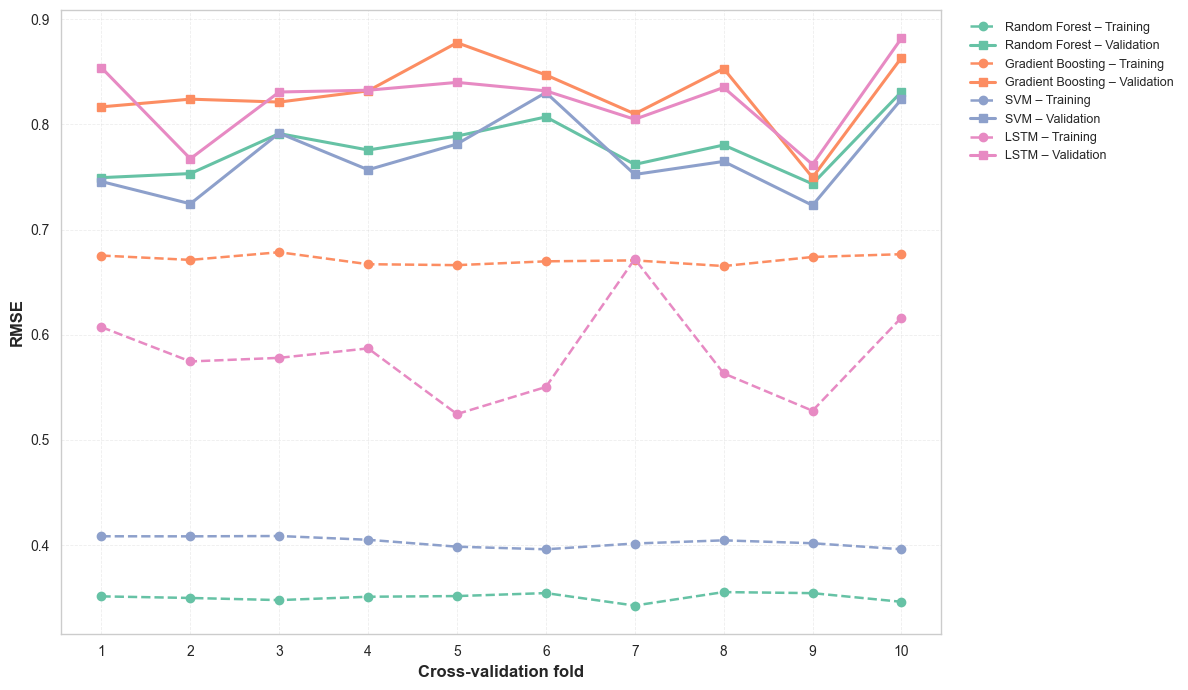

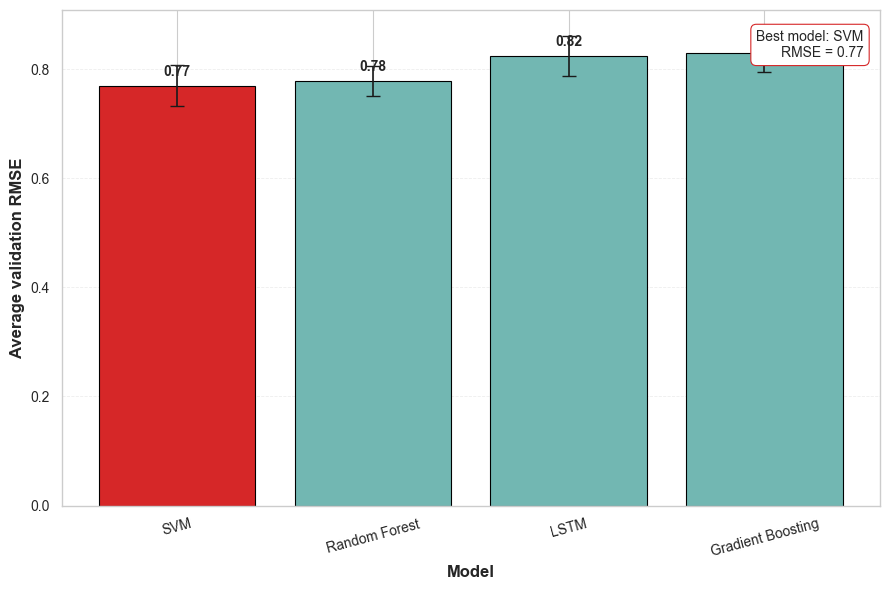


Analysis completed successfully.
Fold-level RMSE plot:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/training_validation_RMSE_10_fold_comparison.jpg
Average validation RMSE plot:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/average_validation_RMSE_10_fold_comparison.jpg


In [6]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)


# ==================================================
# Step 1: General settings
# ==================================================
RANDOM_STATE = 42
DECIMAL_PLACES = 2
NUMBER_OF_FOLDS = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# ==================================================
# Step 2: Input and output locations
# ==================================================
data_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data"
)

input_file = data_dir / "rdkit_train.csv"

output_dir = data_dir / "model"
output_dir.mkdir(parents=True, exist_ok=True)

fold_plot_file = (
    output_dir /
    "training_validation_RMSE_10_fold_comparison.jpg"
)

average_plot_file = (
    output_dir /
    "average_validation_RMSE_10_fold_comparison.jpg"
)


# ==================================================
# Step 3: Load the RDKit training dataset
# ==================================================
if not input_file.exists():
    raise FileNotFoundError(
        f"Input file was not found:\n{input_file}"
    )

rdkit_train = pd.read_csv(input_file)

print(f"Input file: {input_file}")
print(f"Original dataset shape: {rdkit_train.shape}")


# ==================================================
# Step 4: Define target and excluded columns
# ==================================================
target_column = "log_ic50"

if target_column not in rdkit_train.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found."
    )

cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles"
]

drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name"
]

# Combine lists and remove duplicate names
all_drop_cols = list(
    dict.fromkeys(cols_to_drop1 + drop_cols2)
)

existing_drop_cols = [
    column
    for column in all_drop_cols
    if column in rdkit_train.columns
]

print(
    f"Excluded columns found in dataset: "
    f"{len(existing_drop_cols)}"
)


# ==================================================
# Step 5: Prepare target values
# ==================================================
y = pd.to_numeric(
    rdkit_train[target_column],
    errors="coerce"
)


# ==================================================
# Step 6: Prepare RDKit descriptors
# ==================================================
X = rdkit_train.drop(
    columns=existing_drop_cols
).copy()

# Replace empty cells with NaN
X = X.replace(
    r"^\s*$",
    np.nan,
    regex=True
)

# Convert all descriptor values to numeric
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove rows with invalid target values
valid_target_rows = y.notna()

X = X.loc[
    valid_target_rows
].reset_index(drop=True)

y = y.loc[
    valid_target_rows
].reset_index(drop=True)

print(
    f"Rows retained after target cleaning: "
    f"{len(y)}"
)


# ==================================================
# Step 7: Remove invalid descriptors
# ==================================================

# Require at least two observed values per descriptor
valid_columns = X.columns[
    X.notna().sum(axis=0) >= 2
]

X = X[
    valid_columns
].copy()

# Identify zero-variance descriptors
descriptor_variance = X.var(
    skipna=True
)

zero_variance_columns = descriptor_variance[
    np.isclose(
        descriptor_variance,
        0,
        equal_nan=True
    )
].index.tolist()

if zero_variance_columns:
    X = X.drop(
        columns=zero_variance_columns
    )

print(
    f"Zero-variance descriptors removed: "
    f"{len(zero_variance_columns)}"
)

if X.shape[1] == 0:
    raise ValueError(
        "No valid descriptor columns remain."
    )

print(f"Final sample count: {X.shape[0]}")
print(f"Final descriptor count: {X.shape[1]}")


# ==================================================
# Step 8: Define the LSTM model
# ==================================================
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        activation="relu"
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        activation_functions = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }

        self.activation = activation_functions.get(
            activation,
            nn.Identity()
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.activation(output)

        return self.output_layer(output)


# ==================================================
# Step 9: Train LSTM using early stopping
# ==================================================
def train_lstm_model(
    model,
    train_loader,
    validation_loader,
    epochs=200,
    patience=20,
    learning_rate=0.001
):
    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):

        # Training
        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            loss.backward()
            optimizer.step()

        # Internal validation
        model.eval()
        validation_losses = []

        with torch.no_grad():
            for batch_x, batch_y in validation_loader:
                predictions = model(batch_x)

                loss = criterion(
                    predictions,
                    batch_y
                )

                validation_losses.append(
                    loss.item()
                )

        average_validation_loss = np.mean(
            validation_losses
        )

        if average_validation_loss < best_validation_loss:
            best_validation_loss = average_validation_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1

            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(
            best_model_state
        )

    return model


# ==================================================
# Step 10: Model parameters
# ==================================================

# Optimized Random Forest parameters
rf_parameters = {
    "max_depth": None,
    "max_features": None,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "n_estimators": 200,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

lstm_parameters = {
    "hidden_size": 64,
    "num_layers": 2,
    "activation": "relu",
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 200,
    "patience": 20
}


# ==================================================
# Step 11: Define the four models
# ==================================================
sklearn_models = {
    "Random Forest": RandomForestRegressor(
        **rf_parameters
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVM": SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1,
        gamma="scale"
    )
}

model_names = [
    "Random Forest",
    "Gradient Boosting",
    "SVM",
    "LSTM"
]


# ==================================================
# Step 12: Set up 10-fold cross-validation
# ==================================================
cross_validation = KFold(
    n_splits=NUMBER_OF_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

training_rmse = {
    model_name: []
    for model_name in model_names
}

validation_rmse = {
    model_name: []
    for model_name in model_names
}


# ==================================================
# Step 13: Run 10-fold cross-validation
# ==================================================
for fold, (train_index, validation_index) in enumerate(
    cross_validation.split(X),
    start=1
):
    print(
        f"\nRunning fold {fold}/{NUMBER_OF_FOLDS}"
    )

    X_train = X.iloc[
        train_index
    ].copy()

    X_validation = X.iloc[
        validation_index
    ].copy()

    y_train = y.iloc[
        train_index
    ].copy()

    y_validation = y.iloc[
        validation_index
    ].copy()

    # ----------------------------------------------
    # Mean imputation
    # ----------------------------------------------
    imputer = SimpleImputer(
        strategy="mean"
    )

    X_train_imputed = imputer.fit_transform(
        X_train
    )

    X_validation_imputed = imputer.transform(
        X_validation
    )

    # ----------------------------------------------
    # Standardization
    # ----------------------------------------------
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_imputed
    )

    X_validation_scaled = scaler.transform(
        X_validation_imputed
    )

    # ----------------------------------------------
    # Random Forest, Gradient Boosting and SVM
    # ----------------------------------------------
    for model_name, base_model in sklearn_models.items():

        model = clone(base_model)

        model.fit(
            X_train_scaled,
            y_train
        )

        train_predictions = model.predict(
            X_train_scaled
        )

        validation_predictions = model.predict(
            X_validation_scaled
        )

        fold_training_rmse = np.sqrt(
            mean_squared_error(
                y_train,
                train_predictions
            )
        )

        fold_validation_rmse = np.sqrt(
            mean_squared_error(
                y_validation,
                validation_predictions
            )
        )

        training_rmse[model_name].append(
            fold_training_rmse
        )

        validation_rmse[model_name].append(
            fold_validation_rmse
        )

        print(
            f"{model_name}: "
            f"training RMSE = {fold_training_rmse:.2f}; "
            f"validation RMSE = {fold_validation_rmse:.2f}"
        )

    # ----------------------------------------------
    # Prepare LSTM data
    # ----------------------------------------------
    X_train_sequence = X_train_scaled.reshape(
        X_train_scaled.shape[0],
        1,
        X_train_scaled.shape[1]
    )

    X_validation_sequence = X_validation_scaled.reshape(
        X_validation_scaled.shape[0],
        1,
        X_validation_scaled.shape[1]
    )

    X_train_tensor = torch.tensor(
        X_train_sequence,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.to_numpy().reshape(-1, 1),
        dtype=torch.float32
    )

    X_validation_tensor = torch.tensor(
        X_validation_sequence,
        dtype=torch.float32
    )

    complete_training_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    internal_train_size = int(
        0.80 * len(complete_training_dataset)
    )

    internal_validation_size = (
        len(complete_training_dataset)
        - internal_train_size
    )

    split_generator = torch.Generator().manual_seed(
        RANDOM_STATE + fold
    )

    internal_train_dataset, internal_validation_dataset = (
        random_split(
            complete_training_dataset,
            [
                internal_train_size,
                internal_validation_size
            ],
            generator=split_generator
        )
    )

    train_loader = DataLoader(
        internal_train_dataset,
        batch_size=lstm_parameters["batch_size"],
        shuffle=True
    )

    internal_validation_loader = DataLoader(
        internal_validation_dataset,
        batch_size=lstm_parameters["batch_size"],
        shuffle=False
    )

    # ----------------------------------------------
    # Train a new LSTM for the current fold
    # ----------------------------------------------
    torch.manual_seed(
        RANDOM_STATE + fold
    )

    lstm_model = LSTMRegressor(
        input_size=X_train_tensor.shape[2],
        hidden_size=lstm_parameters["hidden_size"],
        num_layers=lstm_parameters["num_layers"],
        activation=lstm_parameters["activation"]
    )

    lstm_model = train_lstm_model(
        model=lstm_model,
        train_loader=train_loader,
        validation_loader=internal_validation_loader,
        epochs=lstm_parameters["epochs"],
        patience=lstm_parameters["patience"],
        learning_rate=lstm_parameters["learning_rate"]
    )

    lstm_model.eval()

    with torch.no_grad():
        lstm_train_predictions = (
            lstm_model(X_train_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

        lstm_validation_predictions = (
            lstm_model(X_validation_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

    lstm_training_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            lstm_train_predictions
        )
    )

    lstm_validation_rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            lstm_validation_predictions
        )
    )

    training_rmse["LSTM"].append(
        lstm_training_rmse
    )

    validation_rmse["LSTM"].append(
        lstm_validation_rmse
    )

    print(
        f"LSTM: "
        f"training RMSE = {lstm_training_rmse:.2f}; "
        f"validation RMSE = {lstm_validation_rmse:.2f}"
    )


# ==================================================
# Step 14: Calculate average RMSE
# ==================================================
average_training_rmse = {
    model_name: np.mean(
        training_rmse[model_name]
    )
    for model_name in model_names
}

average_validation_rmse = {
    model_name: np.mean(
        validation_rmse[model_name]
    )
    for model_name in model_names
}

validation_rmse_sd = {
    model_name: np.std(
        validation_rmse[model_name],
        ddof=1
    )
    for model_name in model_names
}

# Use full-precision values to identify the best model
best_model = min(
    average_validation_rmse,
    key=average_validation_rmse.get
)

best_rmse = average_validation_rmse[
    best_model
]

print("\nAverage 10-fold cross-validation results:")

for model_name in model_names:
    print(
        f"{model_name}: "
        f"training RMSE = "
        f"{average_training_rmse[model_name]:.2f}; "
        f"validation RMSE = "
        f"{average_validation_rmse[model_name]:.2f} "
        f"± {validation_rmse_sd[model_name]:.2f}"
    )

print(f"\nBest model: {best_model}")

print(
    f"Lowest validation RMSE: "
    f"{best_rmse:.2f}"
)


# ==================================================
# Step 15: Publication-style plot settings
# ==================================================
sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})


# ==================================================
# Step 16: Plot training and validation RMSE by fold
# ==================================================
colors = sns.color_palette(
    "Set2",
    n_colors=len(model_names)
)

fold_numbers = np.arange(
    1,
    NUMBER_OF_FOLDS + 1
)

fig, ax = plt.subplots(
    figsize=(12, 7),
    facecolor="white"
)

for model_index, model_name in enumerate(model_names):

    ax.plot(
        fold_numbers,
        training_rmse[model_name],
        linestyle="--",
        marker="o",
        linewidth=1.8,
        markersize=6,
        color=colors[model_index],
        label=f"{model_name} – Training"
    )

    ax.plot(
        fold_numbers,
        validation_rmse[model_name],
        linestyle="-",
        marker="s",
        linewidth=2.2,
        markersize=6,
        color=colors[model_index],
        label=f"{model_name} – Validation"
    )

ax.set_xlabel("Cross-validation fold")
ax.set_ylabel("RMSE")

ax.set_xticks(
    fold_numbers
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

fig.tight_layout()

fig.savefig(
    fold_plot_file,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# Step 17: Plot average validation RMSE
# ==================================================
plot_order = sorted(
    model_names,
    key=lambda model_name:
        average_validation_rmse[model_name]
)

plot_values = [
    average_validation_rmse[model_name]
    for model_name in plot_order
]

plot_errors = [
    validation_rmse_sd[model_name]
    for model_name in plot_order
]

bar_colors = [
    "#D62728"
    if model_name == best_model
    else "#72B7B2"
    for model_name in plot_order
]

fig, ax = plt.subplots(
    figsize=(9, 6),
    facecolor="white"
)

bars = ax.bar(
    plot_order,
    plot_values,
    yerr=plot_errors,
    capsize=5,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("Model")
ax.set_ylabel("Average validation RMSE")

ax.tick_params(
    axis="x",
    labelrotation=15
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

# Add values with two decimal places
vertical_offset = max(plot_values) * 0.015

for bar, value in zip(bars, plot_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + vertical_offset,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.text(
    0.98,
    0.96,
    f"Best model: {best_model}\n"
    f"RMSE = {best_rmse:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#D62728"
    }
)

fig.tight_layout()

fig.savefig(
    average_plot_file,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# Step 18: Output locations
# ==================================================
print("\nAnalysis completed successfully.")

print(
    f"Fold-level RMSE plot:\n"
    f"{fold_plot_file}"
)

print(
    f"Average validation RMSE plot:\n"
    f"{average_plot_file}"
)

Input file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv
Original dataset shape: (2760, 223)
Excluded columns found in dataset: 28
Rows retained after target cleaning: 2760
Zero-variance descriptors removed: 0
Final sample count: 2760
Final descriptor count: 195

Running fold 1/10
Random Forest: training R² = 0.95; validation R² = 0.76
Gradient Boosting: training R² = 0.81; validation R² = 0.71
SVM: training R² = 0.93; validation R² = 0.76
LSTM: training R² = 0.85; validation R² = 0.69

Running fold 2/10
Random Forest: training R² = 0.95; validation R² = 0.78
Gradient Boosting: training R² = 0.81; validation R² = 0.73
SVM: training R² = 0.93; validation R² = 0.79
LSTM: training R² = 0.86; validation R² = 0.77

Running fold 3/10
Random Forest: training R² = 0.95; validation R² = 0.74
Gradient Boosting: training R² = 0.81; validation R² = 0.72
SVM: training R² = 0.93; validation R² = 0.74
LSTM: training R² = 0.86; validation R² = 0.72

Running fold 4/10
Random Forest: t

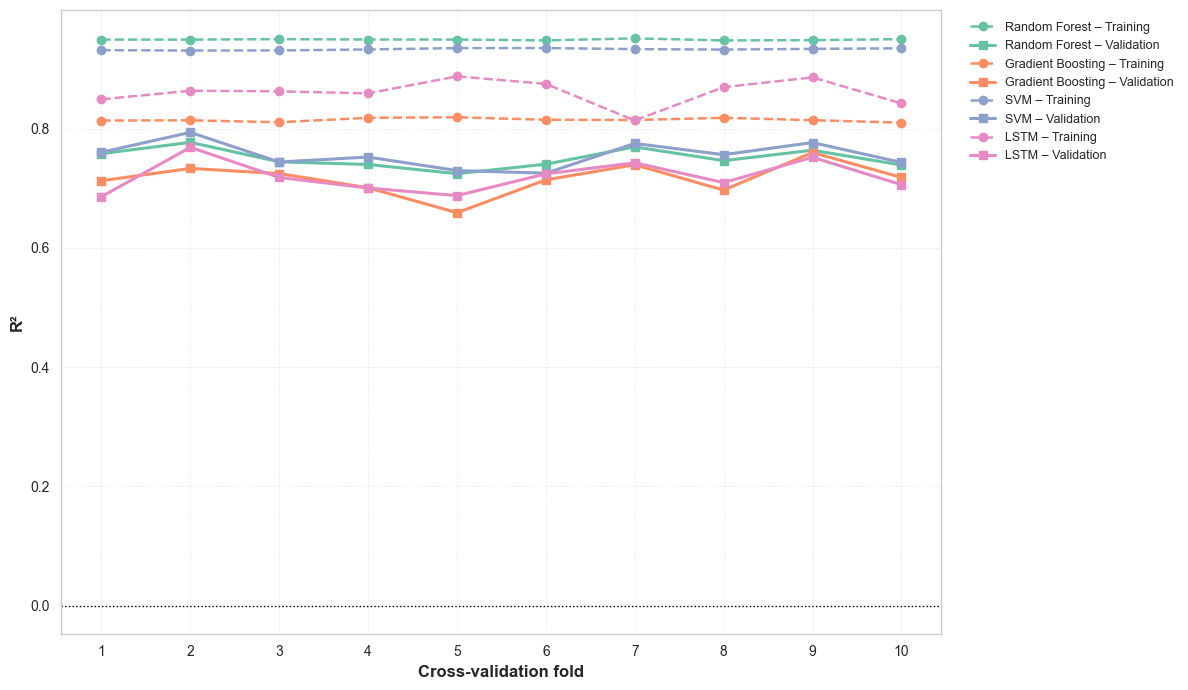

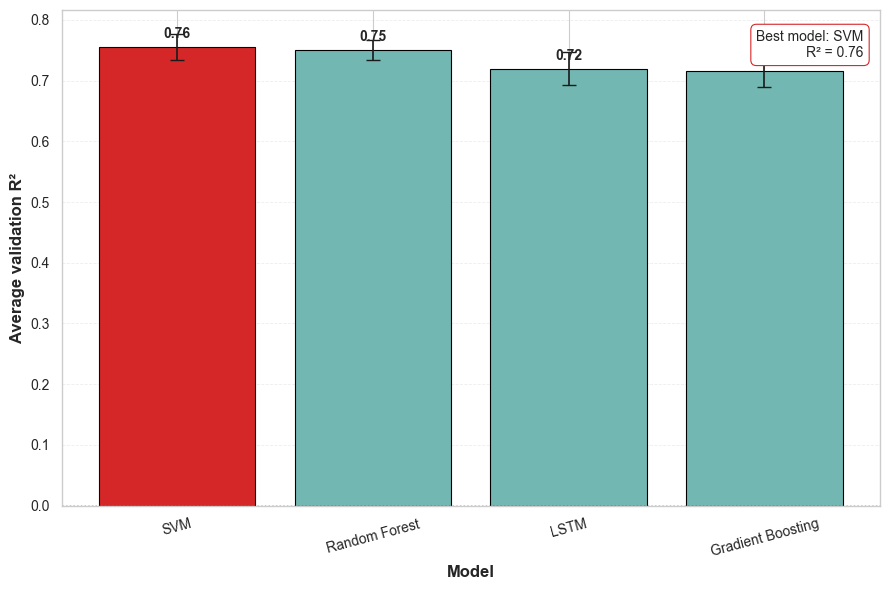


R² analysis completed successfully.
Fold-level R² plot:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/training_validation_R2_10_fold_comparison.jpg
Average validation R² plot:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/average_validation_R2_10_fold_comparison.jpg


In [8]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)


# ==================================================
# Step 1: General settings
# ==================================================
RANDOM_STATE = 42
NUMBER_OF_FOLDS = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)


# ==================================================
# Step 2: Input and output paths
# ==================================================
data_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data"
)

input_file = data_dir / "rdkit_train.csv"

output_dir = data_dir / "model"
output_dir.mkdir(parents=True, exist_ok=True)

fold_plot_file = (
    output_dir /
    "training_validation_R2_10_fold_comparison.jpg"
)

average_plot_file = (
    output_dir /
    "average_validation_R2_10_fold_comparison.jpg"
)


# ==================================================
# Step 3: Load the RDKit training dataset
# ==================================================
if not input_file.exists():
    raise FileNotFoundError(
        f"Input file was not found:\n{input_file}"
    )

rdkit_train = pd.read_csv(input_file)

print(f"Input file: {input_file}")
print(f"Original dataset shape: {rdkit_train.shape}")


# ==================================================
# Step 4: Target and excluded columns
# ==================================================
target_column = "log_ic50"

if target_column not in rdkit_train.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found."
    )

cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles"
]

drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name"
]

all_drop_cols = list(
    dict.fromkeys(cols_to_drop1 + drop_cols2)
)

existing_drop_cols = [
    column
    for column in all_drop_cols
    if column in rdkit_train.columns
]

print(
    f"Excluded columns found in dataset: "
    f"{len(existing_drop_cols)}"
)


# ==================================================
# Step 5: Prepare target and descriptors
# ==================================================
y = pd.to_numeric(
    rdkit_train[target_column],
    errors="coerce"
)

X = rdkit_train.drop(
    columns=existing_drop_cols
).copy()

X = X.replace(
    r"^\s*$",
    np.nan,
    regex=True
)

X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

# Remove rows with invalid target values
valid_target_rows = y.notna()

X = X.loc[
    valid_target_rows
].reset_index(drop=True)

y = y.loc[
    valid_target_rows
].reset_index(drop=True)

print(
    f"Rows retained after target cleaning: "
    f"{len(y)}"
)


# ==================================================
# Step 6: Remove invalid descriptors
# ==================================================
valid_columns = X.columns[
    X.notna().sum(axis=0) >= 2
]

X = X[
    valid_columns
].copy()

descriptor_variance = X.var(
    skipna=True
)

zero_variance_columns = descriptor_variance[
    np.isclose(
        descriptor_variance,
        0,
        equal_nan=True
    )
].index.tolist()

if zero_variance_columns:
    X = X.drop(
        columns=zero_variance_columns
    )

if X.shape[1] == 0:
    raise ValueError(
        "No valid descriptor columns remain."
    )

print(
    f"Zero-variance descriptors removed: "
    f"{len(zero_variance_columns)}"
)

print(f"Final sample count: {X.shape[0]}")
print(f"Final descriptor count: {X.shape[1]}")


# ==================================================
# Step 7: Define the LSTM model
# ==================================================
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        activation="relu"
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        activation_functions = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }

        self.activation = activation_functions.get(
            activation,
            nn.Identity()
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.activation(output)

        return self.output_layer(output)


# ==================================================
# Step 8: Train LSTM with early stopping
# ==================================================
def train_lstm_model(
    model,
    train_loader,
    validation_loader,
    epochs=200,
    patience=20,
    learning_rate=0.001
):
    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):

        model.train()

        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_x)
            loss = criterion(predictions, batch_y)

            loss.backward()
            optimizer.step()

        model.eval()
        validation_losses = []

        with torch.no_grad():
            for batch_x, batch_y in validation_loader:
                predictions = model(batch_x)

                validation_loss = criterion(
                    predictions,
                    batch_y
                )

                validation_losses.append(
                    validation_loss.item()
                )

        average_validation_loss = np.mean(
            validation_losses
        )

        if average_validation_loss < best_validation_loss:
            best_validation_loss = average_validation_loss

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:
            patience_counter += 1

            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(
            best_model_state
        )

    return model


# ==================================================
# Step 9: Model parameters
# ==================================================
rf_parameters = {
    "max_depth": None,
    "max_features": None,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "n_estimators": 200,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

lstm_parameters = {
    "hidden_size": 64,
    "num_layers": 2,
    "activation": "relu",
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 200,
    "patience": 20
}


# ==================================================
# Step 10: Define the models
# ==================================================
sklearn_models = {
    "RF": RandomForestRegressor(
        **rf_parameters
    ),

    "GB": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1,
        gamma="scale"
    )
}

model_names = [
    "RF",
    "GB",
    "SVR",
    "LSTM"
]


# ==================================================
# Step 11: Set up 10-fold cross-validation
# ==================================================
cross_validation = KFold(
    n_splits=NUMBER_OF_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

training_r2 = {
    model_name: []
    for model_name in model_names
}

validation_r2 = {
    model_name: []
    for model_name in model_names
}


# ==================================================
# Step 12: Run 10-fold cross-validation
# ==================================================
for fold, (train_index, validation_index) in enumerate(
    cross_validation.split(X),
    start=1
):
    print(
        f"\nRunning fold {fold}/{NUMBER_OF_FOLDS}"
    )

    X_train = X.iloc[
        train_index
    ].copy()

    X_validation = X.iloc[
        validation_index
    ].copy()

    y_train = y.iloc[
        train_index
    ].copy()

    y_validation = y.iloc[
        validation_index
    ].copy()

    # Fit imputation only on the training fold
    imputer = SimpleImputer(
        strategy="mean"
    )

    X_train_imputed = imputer.fit_transform(
        X_train
    )

    X_validation_imputed = imputer.transform(
        X_validation
    )

    # Fit scaling only on the training fold
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_imputed
    )

    X_validation_scaled = scaler.transform(
        X_validation_imputed
    )

    # ----------------------------------------------
    # Random Forest, Gradient Boosting and SVM
    # ----------------------------------------------
    for model_name, base_model in sklearn_models.items():

        model = clone(base_model)

        model.fit(
            X_train_scaled,
            y_train
        )

        train_predictions = model.predict(
            X_train_scaled
        )

        validation_predictions = model.predict(
            X_validation_scaled
        )

        fold_training_r2 = r2_score(
            y_train,
            train_predictions
        )

        fold_validation_r2 = r2_score(
            y_validation,
            validation_predictions
        )

        training_r2[model_name].append(
            fold_training_r2
        )

        validation_r2[model_name].append(
            fold_validation_r2
        )

        print(
            f"{model_name}: "
            f"training R² = {fold_training_r2:.2f}; "
            f"validation R² = {fold_validation_r2:.2f}"
        )

    # ----------------------------------------------
    # Prepare LSTM tensors
    # ----------------------------------------------
    X_train_sequence = X_train_scaled.reshape(
        X_train_scaled.shape[0],
        1,
        X_train_scaled.shape[1]
    )

    X_validation_sequence = X_validation_scaled.reshape(
        X_validation_scaled.shape[0],
        1,
        X_validation_scaled.shape[1]
    )

    X_train_tensor = torch.tensor(
        X_train_sequence,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.to_numpy().reshape(-1, 1),
        dtype=torch.float32
    )

    X_validation_tensor = torch.tensor(
        X_validation_sequence,
        dtype=torch.float32
    )

    complete_training_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    internal_train_size = int(
        0.80 * len(complete_training_dataset)
    )

    internal_validation_size = (
        len(complete_training_dataset)
        - internal_train_size
    )

    split_generator = torch.Generator().manual_seed(
        RANDOM_STATE + fold
    )

    internal_train_dataset, internal_validation_dataset = (
        random_split(
            complete_training_dataset,
            [
                internal_train_size,
                internal_validation_size
            ],
            generator=split_generator
        )
    )

    train_loader = DataLoader(
        internal_train_dataset,
        batch_size=lstm_parameters["batch_size"],
        shuffle=True
    )

    internal_validation_loader = DataLoader(
        internal_validation_dataset,
        batch_size=lstm_parameters["batch_size"],
        shuffle=False
    )

    torch.manual_seed(
        RANDOM_STATE + fold
    )

    lstm_model = LSTMRegressor(
        input_size=X_train_tensor.shape[2],
        hidden_size=lstm_parameters["hidden_size"],
        num_layers=lstm_parameters["num_layers"],
        activation=lstm_parameters["activation"]
    )

    lstm_model = train_lstm_model(
        model=lstm_model,
        train_loader=train_loader,
        validation_loader=internal_validation_loader,
        epochs=lstm_parameters["epochs"],
        patience=lstm_parameters["patience"],
        learning_rate=lstm_parameters["learning_rate"]
    )

    lstm_model.eval()

    with torch.no_grad():
        lstm_train_predictions = (
            lstm_model(X_train_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

        lstm_validation_predictions = (
            lstm_model(X_validation_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

    lstm_training_r2 = r2_score(
        y_train,
        lstm_train_predictions
    )

    lstm_validation_r2 = r2_score(
        y_validation,
        lstm_validation_predictions
    )

    training_r2["LSTM"].append(
        lstm_training_r2
    )

    validation_r2["LSTM"].append(
        lstm_validation_r2
    )

    print(
        f"LSTM: "
        f"training R² = {lstm_training_r2:.2f}; "
        f"validation R² = {lstm_validation_r2:.2f}"
    )


# ==================================================
# Step 13: Calculate average R²
# ==================================================
average_training_r2 = {
    model_name: np.mean(
        training_r2[model_name]
    )
    for model_name in model_names
}

average_validation_r2 = {
    model_name: np.mean(
        validation_r2[model_name]
    )
    for model_name in model_names
}

validation_r2_sd = {
    model_name: np.std(
        validation_r2[model_name],
        ddof=1
    )
    for model_name in model_names
}

# Higher R² is better
best_model = max(
    average_validation_r2,
    key=average_validation_r2.get
)

best_r2 = average_validation_r2[
    best_model
]

print("\nAverage 10-fold cross-validation results:")

for model_name in model_names:
    print(
        f"{model_name}: "
        f"training R² = "
        f"{average_training_r2[model_name]:.2f}; "
        f"validation R² = "
        f"{average_validation_r2[model_name]:.2f} "
        f"± {validation_r2_sd[model_name]:.2f}"
    )

print(f"\nBest model: {best_model}")
print(f"Highest validation R²: {best_r2:.2f}")


# ==================================================
# Step 14: Publication-style plot settings
# ==================================================
sns.set_theme(
    style="whitegrid",
    context="paper"
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})


# ==================================================
# Step 15: Plot training and validation R² by fold
# ==================================================
colors = sns.color_palette(
    "Set2",
    n_colors=len(model_names)
)

fold_numbers = np.arange(
    1,
    NUMBER_OF_FOLDS + 1
)

fig, ax = plt.subplots(
    figsize=(12, 7),
    facecolor="white"
)

for model_index, model_name in enumerate(model_names):

    ax.plot(
        fold_numbers,
        training_r2[model_name],
        linestyle="--",
        marker="o",
        linewidth=1.8,
        markersize=6,
        color=colors[model_index],
        label=f"{model_name} – Training"
    )

    ax.plot(
        fold_numbers,
        validation_r2[model_name],
        linestyle="-",
        marker="s",
        linewidth=2.2,
        markersize=6,
        color=colors[model_index],
        label=f"{model_name} – Validation"
    )

ax.axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=1
)

ax.set_xlabel("Cross-validation fold")
ax.set_ylabel("R²")

ax.set_xticks(
    fold_numbers
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

fig.tight_layout()

fig.savefig(
    fold_plot_file,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# Step 16: Plot average validation R²
# ==================================================
plot_order = sorted(
    model_names,
    key=lambda model_name:
        average_validation_r2[model_name],
    reverse=True
)

plot_values = [
    average_validation_r2[model_name]
    for model_name in plot_order
]

plot_errors = [
    validation_r2_sd[model_name]
    for model_name in plot_order
]

bar_colors = [
    "#D62728"
    if model_name == best_model
    else "#72B7B2"
    for model_name in plot_order
]

fig, ax = plt.subplots(
    figsize=(9, 6),
    facecolor="white"
)

bars = ax.bar(
    plot_order,
    plot_values,
    yerr=plot_errors,
    capsize=5,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8
)

ax.axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=1
)

ax.set_xlabel("Model")
ax.set_ylabel("Average validation R²")

ax.tick_params(
    axis="x",
    labelrotation=15
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

# Add two-decimal values above each bar
value_range = max(plot_values) - min(plot_values)
vertical_offset = max(value_range * 0.03, 0.01)

for bar, value in zip(bars, plot_values):
    label_y = (
        value + vertical_offset
        if value >= 0
        else value - vertical_offset
    )

    vertical_alignment = (
        "bottom"
        if value >= 0
        else "top"
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{value:.2f}",
        ha="center",
        va=vertical_alignment,
        fontsize=10,
        fontweight="bold"
    )

ax.text(
    0.98,
    0.96,
    f"Best model: {best_model}\n"
    f"R² = {best_r2:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "edgecolor": "#D62728"
    }
)

fig.tight_layout()

fig.savefig(
    average_plot_file,
    format="jpg",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# Step 17: Output locations
# ==================================================
print("\nR² analysis completed successfully.")

print(
    f"Fold-level R² plot:\n"
    f"{fold_plot_file}"
)

print(
    f"Average validation R² plot:\n"
    f"{average_plot_file}"
)

In [12]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# === Paths ===
INPUT_FILE = "/Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv"
OUTPUT_DIR = "/Users/janat/Desktop/ppimic50pred/dataset/data/model/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# === Columns to drop ===
cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles",
]
drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name",
]
drop_cols = list(dict.fromkeys(cols_to_drop1 + drop_cols2))

# === Metrics ===
def medape(y_true, y_pred, epsilon=1e-3):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > epsilon
    if np.sum(mask) == 0:
        return np.nan
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred, epsilon=1e-3):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominator = np.where(denominator < epsilon, epsilon, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

# === LSTM model ===
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, activation='relu'):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU()
        }
        self.activation = activations.get(activation, None)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.activation(out) if self.activation else out
        return self.fc(out)

def train_model(model, train_loader, val_loader, epochs=200, patience=20, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss = criterion(model(xb), yb)
                val_losses.append(val_loss.item())
        avg_val_loss = np.mean(val_losses)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model

# === Load data ===
print(f"Reading input file: {INPUT_FILE}")
rdkit_train = pd.read_csv(INPUT_FILE)
print(f"Loaded shape: {rdkit_train.shape}")

# NOTE: set these to match your actual best-param search results.
# Placeholders below — replace with your tuned values if different.
rf_best_params = {
    "n_estimators": 300,
    "max_depth": None,
    "random_state": 42,
}
lstm_best_params = {
    "hidden_size": 64,
    "num_layers": 2,
    "activation": "relu",
    "batch_size": 32,
    "learning_rate": 0.001,
}

# === Prepare Data ===
y = rdkit_train['log_ic50']
X = rdkit_train.drop(columns=[col for col in drop_cols if col in rdkit_train.columns])
X = X.replace(r'^\s*$', np.nan, regex=True).apply(pd.to_numeric, errors='coerce').fillna(X.mean())

# features_filtered: all remaining numeric columns after dropping.
# Replace this with your own pre-selected feature list if you have one.
features_filtered = X.columns.tolist()
X_selected = X[features_filtered]

# Save the processed feature matrix + target for reuse
processed = X_selected.copy()
processed['log_ic50'] = y.values
processed_path = os.path.join(OUTPUT_DIR, "processed_train_data.csv")
processed.to_csv(processed_path, index=False)
print(f"Saved processed data to: {processed_path}")

with open(os.path.join(OUTPUT_DIR, "features_filtered.pkl"), "wb") as f:
    pickle.dump(features_filtered, f)

# === Models ===
models = {
    'Random Forest': RandomForestRegressor(**rf_best_params),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'SVM': SVR(),
    'LSTM (PyTorch)': None
}

metrics = ['RMSE', 'MSE', 'R²', 'MedAPE', 'SMAPE']

# === Cross-validation ===
kf = KFold(n_splits=9, shuffle=True, random_state=42)
scores = {metric: {m: [] for m in models} for metric in metrics}

train_r2_hist = {m: [] for m in models}
val_r2_hist = {m: [] for m in models}

fold_num = 0
for train_idx, test_idx in kf.split(X_selected):
    fold_num += 1
    print(f"Fold {fold_num}/9")
    X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # === Train ML models ===
    for name, model in models.items():
        if name == 'LSTM (PyTorch)':
            continue
        model.fit(X_train_scaled, y_train)
        y_train_pred = np.maximum(model.predict(X_train_scaled), 0)
        y_val_pred = np.maximum(model.predict(X_test_scaled), 0)

        r2_train = r2_score(y_train, y_train_pred)
        r2_val = r2_score(y_test, y_val_pred)

        train_r2_hist[name].append(r2_train)
        val_r2_hist[name].append(r2_val)

        scores['R²'][name].append(r2_val)
        scores['RMSE'][name].append(np.sqrt(mean_squared_error(y_test, y_val_pred)))
        scores['MSE'][name].append(mean_squared_error(y_test, y_val_pred))
        scores['MedAPE'][name].append(medape(y_test, y_val_pred))
        scores['SMAPE'][name].append(smape(np.expm1(y_test), np.expm1(y_val_pred)))

    # === LSTM model ===
    X_train_seq = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
    X_test_seq = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])

    train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
    test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values.reshape(-1, 1), dtype=torch.float32)

    train_ds, val_ds = random_split(
        TensorDataset(train_tensor, y_train_tensor),
        [int(0.8 * len(train_tensor)), len(train_tensor) - int(0.8 * len(train_tensor))]
    )
    train_loader = DataLoader(train_ds, batch_size=lstm_best_params['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=lstm_best_params['batch_size'])

    lstm = LSTMRegressor(
        input_size=train_tensor.shape[2],
        hidden_size=lstm_best_params['hidden_size'],
        num_layers=lstm_best_params['num_layers'],
        activation=lstm_best_params['activation']
    )
    lstm = train_model(lstm, train_loader, val_loader, lr=lstm_best_params['learning_rate'])
    lstm.eval()

    with torch.no_grad():
        y_train_pred_lstm = torch.clamp(lstm(train_tensor), min=0).squeeze().numpy()
        y_val_pred_lstm = torch.clamp(lstm(test_tensor), min=0).squeeze().numpy()

    train_r2_hist['LSTM (PyTorch)'].append(r2_score(y_train, y_train_pred_lstm))
    val_r2_hist['LSTM (PyTorch)'].append(r2_score(y_test, y_val_pred_lstm))

    scores['R²']['LSTM (PyTorch)'].append(r2_score(y_test, y_val_pred_lstm))
    scores['RMSE']['LSTM (PyTorch)'].append(np.sqrt(mean_squared_error(y_test, y_val_pred_lstm)))
    scores['MSE']['LSTM (PyTorch)'].append(mean_squared_error(y_test, y_val_pred_lstm))
    scores['MedAPE']['LSTM (PyTorch)'].append(medape(y_test, y_val_pred_lstm))
    scores['SMAPE']['LSTM (PyTorch)'].append(smape(np.expm1(y_test), np.expm1(y_val_pred_lstm)))

    # Save the last fold's fitted LSTM state (optional checkpoint per fold)
    torch.save(lstm.state_dict(), os.path.join(OUTPUT_DIR, f"lstm_fold{fold_num}.pt"))

# === Save CV scores summary ===
summary_rows = []
for metric in metrics:
    for m in models:
        summary_rows.append({
            "model": m,
            "metric": metric,
            "mean": np.nanmean(scores[metric][m]),
            "std": np.nanstd(scores[metric][m]),
        })
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUTPUT_DIR, "cv_scores_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Saved CV score summary to: {summary_path}")

# Save raw per-fold scores too
raw_rows = []
for metric in metrics:
    for m in models:
        for fold_i, val in enumerate(scores[metric][m], start=1):
            raw_rows.append({"model": m, "metric": metric, "fold": fold_i, "value": val})
raw_df = pd.DataFrame(raw_rows)
raw_path = os.path.join(OUTPUT_DIR, "cv_scores_raw.csv")
raw_df.to_csv(raw_path, index=False)
print(f"Saved raw per-fold scores to: {raw_path}")

# === Plot Overfitting / Underfitting (R²) ===
plt.figure(figsize=(10, 6))
colors = sns.color_palette("Set2", n_colors=len(models))

for i, model in enumerate(models):
    color = colors[i]
    plt.plot(train_r2_hist[model], linestyle='--', marker='o', color=color, label=f"{model} - Train")
    plt.plot(val_r2_hist[model], linestyle='-', marker='s', color=color, label=f"{model} - Val")

plt.xlabel("Fold")
plt.ylabel("R²")
plt.title("Overfitting / Underfitting Detection (R²)")
plt.grid(True)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "overfitting_underfitting_r2.png"), dpi=150)
plt.close()

# === Best Model Plot (Avg Validation R²) ===
avg_val_r2 = {m: np.mean(scores['R²'][m]) for m in models}
best_model = max(avg_val_r2, key=avg_val_r2.get)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(avg_val_r2.keys()), y=list(avg_val_r2.values()), palette='Set2')
plt.axhline(avg_val_r2[best_model], color='red', linestyle='--', label=f"Best: {best_model}")
plt.ylabel("Avg Validation R²")
plt.title("Best Model Comparison (R²)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "best_model_comparison_r2.png"), dpi=150)
plt.close()

print(f"Best model by avg validation R²: {best_model} ({avg_val_r2[best_model]:.4f})")
print(f"All outputs saved to: {OUTPUT_DIR}")


Reading input file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv
Loaded shape: (2760, 223)
Saved processed data to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/processed_train_data.csv
Fold 1/9
Fold 2/9
Fold 3/9
Fold 4/9
Fold 5/9
Fold 6/9
Fold 7/9
Fold 8/9
Fold 9/9
Saved CV score summary to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/cv_scores_summary.csv
Saved raw per-fold scores to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/cv_scores_raw.csv
Best model by avg validation R²: Random Forest (0.7509)
All outputs saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/


/var/folders/mz/jys89wms6w340jltvdtnnzhr0000gn/T/ipykernel_38072/3232818161.py:309: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(avg_val_r2.keys()), y=list(avg_val_r2.values()), palette='Set2')


Reading train file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv
Train shape: (2760, 223)
Reading blind file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_blind.csv
Blind shape: (691, 223)
X_selected shape: (2760, 195)
X_blind_selected shape: (691, 195)
Saved processed train data to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/processed_train_data.csv
Saved processed blind data to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/processed_blind_data.csv
Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10
Saved CV score summary to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/cv_scores_summary.csv
Saved raw per-fold scores to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/cv_scores_raw.csv
Fitting Random Forest on full training set...
Fitting Gradient Boosting on full training set...
Fitting SVM on full training set...
Fitting LSTM (PyTorch) on full training set...
Saved blind score s

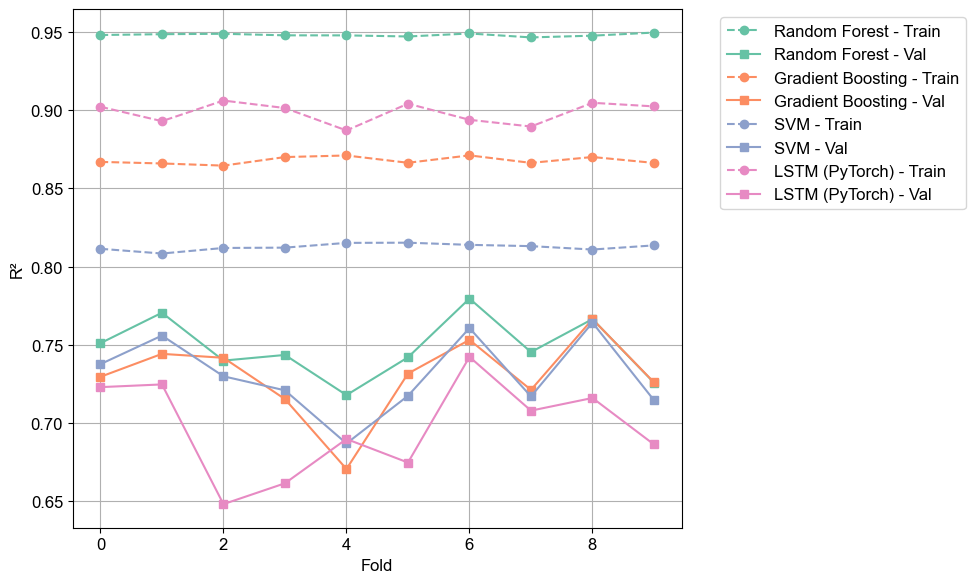


Best model on BLIND data (the one that matters): Random Forest (R² = 0.7452)
Best model on TRAIN CV: Random Forest (R² = 0.7480)
Comparison plot saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/training_blind_R2_model_comparison.jpg
All outputs saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model


In [11]:
"""
IC50 Model Comparison — Train vs Blind

Reads rdkit_train.csv and rdkit_blind.csv, drops non-feature/leak columns,
trains RF / GBM / SVM / LSTM with 9-fold CV on the train set, then evaluates
the final models on the blind set to see which generalizes best.
"""

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# ============================================================
# 1. Paths
# ============================================================
data_dir = Path("/Users/janat/Desktop/ppimic50pred/dataset/data")
train_file = data_dir / "rdkit_train.csv"
blind_file = data_dir / "rdkit_blind.csv"
output_dir = data_dir / "model"
output_dir.mkdir(parents=True, exist_ok=True)

r2_plot_file = output_dir / "training_blind_R2_model_comparison.jpg"
overfit_plot_file = output_dir / "overfitting_underfitting_r2.jpg"

processed_train_path = output_dir / "processed_train_data.csv"
processed_blind_path = output_dir / "processed_blind_data.csv"
cv_summary_path = output_dir / "cv_scores_summary.csv"
cv_raw_path = output_dir / "cv_scores_raw.csv"
blind_scores_path = output_dir / "blind_scores_summary.csv"
train_vs_blind_path = output_dir / "train_vs_blind_r2.csv"
features_path = output_dir / "features_filtered.pkl"

# ============================================================
# 2. Columns to drop
# ============================================================
cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles",
]
drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name",
]
drop_cols = list(dict.fromkeys(cols_to_drop1 + drop_cols2))

# ============================================================
# 3. Metrics
# ============================================================
def medape(y_true, y_pred, epsilon=1e-3):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > epsilon
    if np.sum(mask) == 0:
        return np.nan
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def smape(y_true, y_pred, epsilon=1e-3):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denominator = np.where(denominator < epsilon, epsilon, denominator)
    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

# ============================================================
# 4. LSTM model
# ============================================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, activation='relu'):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
            'leaky_relu': nn.LeakyReLU()
        }
        self.activation = activations.get(activation, None)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.activation(out) if self.activation else out
        return self.fc(out)


def train_model(model, train_loader, val_loader, epochs=200, patience=20, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss = criterion(model(xb), yb)
                val_losses.append(val_loss.item())
        avg_val_loss = np.mean(val_losses)

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_state)
    return model


def main():
    # ============================================================
    # 5. Load train and blind data
    # ============================================================
    print(f"Reading train file: {train_file}")
    rdkit_train = pd.read_csv(train_file)
    print(f"Train shape: {rdkit_train.shape}")

    print(f"Reading blind file: {blind_file}")
    rdkit_blind = pd.read_csv(blind_file)
    print(f"Blind shape: {rdkit_blind.shape}")

    # ============================================================
    # 6. Best hyperparameters (placeholders — replace with your tuned values)
    # ============================================================
    rf_best_params = {
        "n_estimators": 300,
        "max_depth": None,
        "random_state": 42,
    }
    lstm_best_params = {
        "hidden_size": 64,
        "num_layers": 2,
        "activation": "relu",
        "batch_size": 32,
        "learning_rate": 0.001,
    }

    # ============================================================
    # 7. Prepare train data
    # ============================================================
    y = rdkit_train['log_ic50']
    X = rdkit_train.drop(columns=[col for col in drop_cols if col in rdkit_train.columns])
    X = X.replace(r'^\s*$', np.nan, regex=True).apply(pd.to_numeric, errors='coerce').fillna(X.mean())

    # features_filtered: all remaining numeric columns after dropping.
    # Replace this with your own pre-selected feature list if you have one.
    features_filtered = X.columns.tolist()
    X_selected = X[features_filtered]
    print(f"X_selected shape: {X_selected.shape}")

    # ============================================================
    # 8. Prepare blind data (aligned to train feature set)
    # ============================================================
    y_blind = rdkit_blind['log_ic50']
    X_blind = rdkit_blind.drop(columns=[col for col in drop_cols if col in rdkit_blind.columns])
    X_blind = X_blind.replace(r'^\s*$', np.nan, regex=True).apply(pd.to_numeric, errors='coerce').fillna(X_blind.mean())

    missing_in_blind = [c for c in features_filtered if c not in X_blind.columns]
    extra_in_blind = [c for c in X_blind.columns if c not in features_filtered]
    if missing_in_blind:
        print(f"Warning: {len(missing_in_blind)} training features missing in blind set, filling with 0")
        for c in missing_in_blind:
            X_blind[c] = 0
    if extra_in_blind:
        print(f"Note: {len(extra_in_blind)} extra columns in blind set will be dropped.")

    X_blind_selected = X_blind[features_filtered]
    print(f"X_blind_selected shape: {X_blind_selected.shape}")

    # ============================================================
    # 9. Save processed data
    # ============================================================
    processed_train = X_selected.copy()
    processed_train['log_ic50'] = y.values
    processed_train.to_csv(processed_train_path, index=False)
    print(f"Saved processed train data to: {processed_train_path}")

    processed_blind = X_blind_selected.copy()
    processed_blind['log_ic50'] = y_blind.values
    processed_blind.to_csv(processed_blind_path, index=False)
    print(f"Saved processed blind data to: {processed_blind_path}")

    with open(features_path, "wb") as f:
        pickle.dump(features_filtered, f)

    # ============================================================
    # 10. Define models
    # ============================================================
    models = {
        'Random Forest': RandomForestRegressor(**rf_best_params),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
        'SVM': SVR(),
        'LSTM (PyTorch)': None
    }

    metrics = ['RMSE', 'MSE', 'R²', 'MedAPE', 'SMAPE']

    # ============================================================
    # 11. Cross-validation loop (on train set, diagnostic only)
    # ============================================================
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = {metric: {m: [] for m in models} for metric in metrics}

    train_r2_hist = {m: [] for m in models}
    val_r2_hist = {m: [] for m in models}

    fold_num = 0
    for train_idx, test_idx in kf.split(X_selected):
        fold_num += 1
        print(f"Fold {fold_num}/10")
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # --- Train ML models ---
        for name, model in models.items():
            if name == 'LSTM (PyTorch)':
                continue
            model.fit(X_train_scaled, y_train)
            y_train_pred = np.maximum(model.predict(X_train_scaled), 0)
            y_val_pred = np.maximum(model.predict(X_test_scaled), 0)

            r2_train = r2_score(y_train, y_train_pred)
            r2_val = r2_score(y_test, y_val_pred)

            train_r2_hist[name].append(r2_train)
            val_r2_hist[name].append(r2_val)

            scores['R²'][name].append(r2_val)
            scores['RMSE'][name].append(np.sqrt(mean_squared_error(y_test, y_val_pred)))
            scores['MSE'][name].append(mean_squared_error(y_test, y_val_pred))
            scores['MedAPE'][name].append(medape(y_test, y_val_pred))
            scores['SMAPE'][name].append(smape(np.expm1(y_test), np.expm1(y_val_pred)))

        # --- LSTM model ---
        X_train_seq = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
        X_test_seq = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])

        train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32)
        test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)

        train_ds, val_ds = random_split(
            TensorDataset(train_tensor, y_train_tensor),
            [int(0.8 * len(train_tensor)), len(train_tensor) - int(0.8 * len(train_tensor))]
        )
        train_loader = DataLoader(train_ds, batch_size=lstm_best_params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=lstm_best_params['batch_size'])

        lstm = LSTMRegressor(
            input_size=train_tensor.shape[2],
            hidden_size=lstm_best_params['hidden_size'],
            num_layers=lstm_best_params['num_layers'],
            activation=lstm_best_params['activation']
        )
        lstm = train_model(lstm, train_loader, val_loader, lr=lstm_best_params['learning_rate'])
        lstm.eval()

        with torch.no_grad():
            y_train_pred_lstm = torch.clamp(lstm(train_tensor), min=0).squeeze().numpy()
            y_val_pred_lstm = torch.clamp(lstm(test_tensor), min=0).squeeze().numpy()

        train_r2_hist['LSTM (PyTorch)'].append(r2_score(y_train, y_train_pred_lstm))
        val_r2_hist['LSTM (PyTorch)'].append(r2_score(y_test, y_val_pred_lstm))

        scores['R²']['LSTM (PyTorch)'].append(r2_score(y_test, y_val_pred_lstm))
        scores['RMSE']['LSTM (PyTorch)'].append(np.sqrt(mean_squared_error(y_test, y_val_pred_lstm)))
        scores['MSE']['LSTM (PyTorch)'].append(mean_squared_error(y_test, y_val_pred_lstm))
        scores['MedAPE']['LSTM (PyTorch)'].append(medape(y_test, y_val_pred_lstm))
        scores['SMAPE']['LSTM (PyTorch)'].append(smape(np.expm1(y_test), np.expm1(y_val_pred_lstm)))

        torch.save(lstm.state_dict(), output_dir / f"lstm_fold{fold_num}.pt")

    # ============================================================
    # 12. Save CV score summaries
    # ============================================================
    summary_rows = []
    for metric in metrics:
        for m in models:
            summary_rows.append({
                "model": m,
                "metric": metric,
                "mean": np.nanmean(scores[metric][m]),
                "std": np.nanstd(scores[metric][m]),
            })
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(cv_summary_path, index=False)
    print(f"Saved CV score summary to: {cv_summary_path}")

    raw_rows = []
    for metric in metrics:
        for m in models:
            for fold_i, val in enumerate(scores[metric][m], start=1):
                raw_rows.append({"model": m, "metric": metric, "fold": fold_i, "value": val})
    raw_df = pd.DataFrame(raw_rows)
    raw_df.to_csv(cv_raw_path, index=False)
    print(f"Saved raw per-fold scores to: {cv_raw_path}")

    # ============================================================
    # 13. Fit final models on FULL train set, evaluate on BLIND set
    # ============================================================
    final_scaler = StandardScaler()
    X_train_full_scaled = final_scaler.fit_transform(X_selected)
    X_blind_scaled = final_scaler.transform(X_blind_selected)

    blind_scores = {metric: {} for metric in metrics}

    for name, model in models.items():
        if name == 'LSTM (PyTorch)':
            continue
        print(f"Fitting {name} on full training set...")
        model.fit(X_train_full_scaled, y)
        y_blind_pred = np.maximum(model.predict(X_blind_scaled), 0)

        blind_scores['R²'][name] = r2_score(y_blind, y_blind_pred)
        blind_scores['RMSE'][name] = np.sqrt(mean_squared_error(y_blind, y_blind_pred))
        blind_scores['MSE'][name] = mean_squared_error(y_blind, y_blind_pred)
        blind_scores['MedAPE'][name] = medape(y_blind, y_blind_pred)
        blind_scores['SMAPE'][name] = smape(np.expm1(y_blind), np.expm1(y_blind_pred))

    # --- LSTM: train on full train set, evaluate on blind ---
    X_train_full_seq = X_train_full_scaled.reshape(-1, 1, X_train_full_scaled.shape[1])
    X_blind_seq = X_blind_scaled.reshape(-1, 1, X_blind_scaled.shape[1])

    train_tensor_full = torch.tensor(X_train_full_seq, dtype=torch.float32)
    y_train_tensor_full = torch.tensor(y.values.reshape(-1, 1), dtype=torch.float32)
    blind_tensor = torch.tensor(X_blind_seq, dtype=torch.float32)

    train_ds_full, val_ds_full = random_split(
        TensorDataset(train_tensor_full, y_train_tensor_full),
        [int(0.8 * len(train_tensor_full)), len(train_tensor_full) - int(0.8 * len(train_tensor_full))]
    )
    train_loader_full = DataLoader(train_ds_full, batch_size=lstm_best_params['batch_size'], shuffle=True)
    val_loader_full = DataLoader(val_ds_full, batch_size=lstm_best_params['batch_size'])

    print("Fitting LSTM (PyTorch) on full training set...")
    lstm_final = LSTMRegressor(
        input_size=train_tensor_full.shape[2],
        hidden_size=lstm_best_params['hidden_size'],
        num_layers=lstm_best_params['num_layers'],
        activation=lstm_best_params['activation']
    )
    lstm_final = train_model(lstm_final, train_loader_full, val_loader_full, lr=lstm_best_params['learning_rate'])
    lstm_final.eval()

    with torch.no_grad():
        y_blind_pred_lstm = torch.clamp(lstm_final(blind_tensor), min=0).squeeze().numpy()

    blind_scores['R²']['LSTM (PyTorch)'] = r2_score(y_blind, y_blind_pred_lstm)
    blind_scores['RMSE']['LSTM (PyTorch)'] = np.sqrt(mean_squared_error(y_blind, y_blind_pred_lstm))
    blind_scores['MSE']['LSTM (PyTorch)'] = mean_squared_error(y_blind, y_blind_pred_lstm)
    blind_scores['MedAPE']['LSTM (PyTorch)'] = medape(y_blind, y_blind_pred_lstm)
    blind_scores['SMAPE']['LSTM (PyTorch)'] = smape(np.expm1(y_blind), np.expm1(y_blind_pred_lstm))

    torch.save(lstm_final.state_dict(), output_dir / "lstm_final_full_train.pt")

    # ============================================================
    # 14. Save blind scores + train-vs-blind comparison table
    # ============================================================
    blind_rows = []
    for metric in metrics:
        for m in models:
            blind_rows.append({"model": m, "metric": metric, "value": blind_scores[metric][m]})
    blind_df = pd.DataFrame(blind_rows)
    blind_df.to_csv(blind_scores_path, index=False)
    print(f"Saved blind score summary to: {blind_scores_path}")

    avg_val_r2 = {m: np.mean(scores['R²'][m]) for m in models}
    comparison_rows = []
    for m in models:
        comparison_rows.append({
            "model": m,
            "train_cv_r2": avg_val_r2[m],
            "blind_r2": blind_scores['R²'][m],
            "gap (train - blind)": avg_val_r2[m] - blind_scores['R²'][m],
        })
    comparison_df = pd.DataFrame(comparison_rows).sort_values("blind_r2", ascending=False)
    comparison_df.to_csv(train_vs_blind_path, index=False)
    print(f"Saved train-vs-blind comparison to: {train_vs_blind_path}")
    print(comparison_df.to_string(index=False))

    # ============================================================
    # 15. Plot: Overfitting / Underfitting (R², CV folds)
    # ============================================================
    plt.figure(figsize=(10, 6))
    colors = sns.color_palette("Set2", n_colors=len(models))

    for i, model in enumerate(models):
        color = colors[i]
        plt.plot(train_r2_hist[model], linestyle='--', marker='o', color=color, label=f"{model} - Train")
        plt.plot(val_r2_hist[model], linestyle='-', marker='s', color=color, label=f"{model} - Val")

    plt.xlabel("Fold")
    plt.ylabel("R²")
    #plt.title("Overfitting / Underfitting Detection (R²)")
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig(overfit_plot_file, dpi=150, bbox_inches='tight')
    

    plt.show()
    plt.close()

    # ============================================================
    # 16. Plot: Train (CV) vs Blind R² — which model generalizes best
    # ============================================================
    model_names = list(models.keys())
    train_vals = [avg_val_r2[m] for m in model_names]
    blind_vals = [blind_scores['R²'][m] for m in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars_train = ax.bar(x - width/2, train_vals, width, label='Train (avg CV val R²)',
                         color=sns.color_palette("Set2")[0])
    bars_blind = ax.bar(x + width/2, blind_vals, width, label='Blind R²',
                         color=sns.color_palette("Set2")[1])

    ax.set_ylabel("R²")
    ax.set_title("Model Comparison: Train (CV) vs Blind R²")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15)
    ax.bar_label(bars_train, fmt='%.3f', padding=3)
    ax.bar_label(bars_blind, fmt='%.3f', padding=3)
    ax.grid(axis='y', alpha=0.3)

    best_blind_model = max(blind_scores['R²'], key=blind_scores['R²'].get)
    ax.axhline(blind_scores['R²'][best_blind_model], color='red', linestyle='--', alpha=0.6,
               label=f"Best on blind: {best_blind_model}")
    ax.legend()

    plt.tight_layout()
    plt.savefig(r2_plot_file, dpi=300, bbox_inches='tight')
    plt.close()

    best_train_model = max(avg_val_r2, key=avg_val_r2.get)
    print(f"\nBest model on BLIND data (the one that matters): "
          f"{best_blind_model} (R² = {blind_scores['R²'][best_blind_model]:.4f})")
    print(f"Best model on TRAIN CV: {best_train_model} (R² = {avg_val_r2[best_train_model]:.4f})")
    print(f"Comparison plot saved to: {r2_plot_file}")
    print(f"All outputs saved to: {output_dir}")


if __name__ == "__main__":
    main()

Reading train file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_train.csv
Train shape: (2760, 223)
Reading blind file: /Users/janat/Desktop/ppimic50pred/dataset/data/rdkit_blind.csv
Blind shape: (691, 223)
X_selected shape: (2760, 195)
X_blind_selected shape: (691, 195)
Saved processed training data to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/processed_train_data_RMSE.csv
Saved processed blind data to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/processed_blind_data_RMSE.csv
Fold 1/10
Fold 2/10
Fold 3/10
Fold 4/10
Fold 5/10
Fold 6/10
Fold 7/10
Fold 8/10
Fold 9/10
Fold 10/10
Fitting Random Forest on full training set...
Fitting Gradient Boosting on full training set...
Fitting SVM on full training set...
Fitting LSTM (PyTorch) on full training set...
            model  train_cv_rmse  blind_rmse  gap (blind - train)
    Random Forest       0.781833    0.779835            -0.001998
              SVM       0.808591    0.809924             0.001332
Gradient Bo

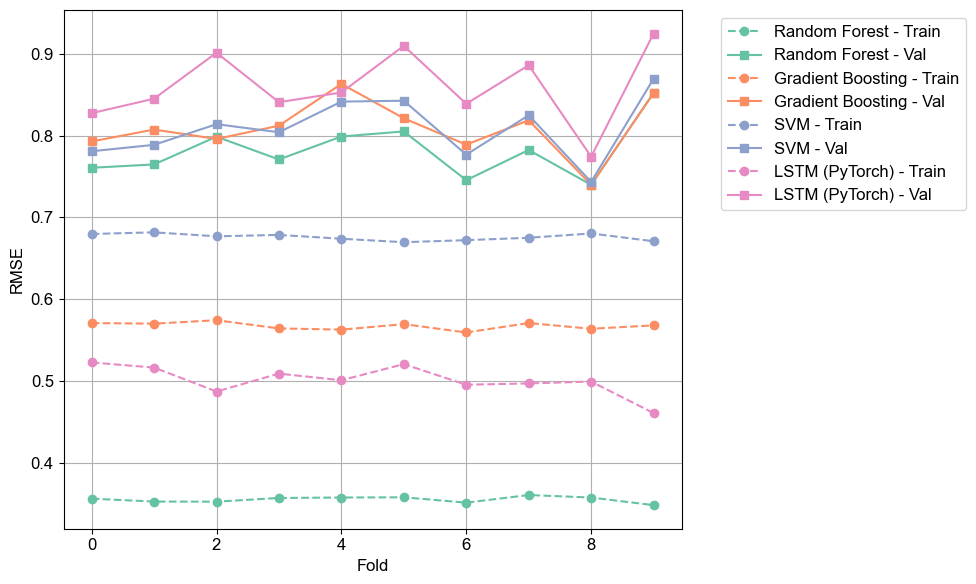

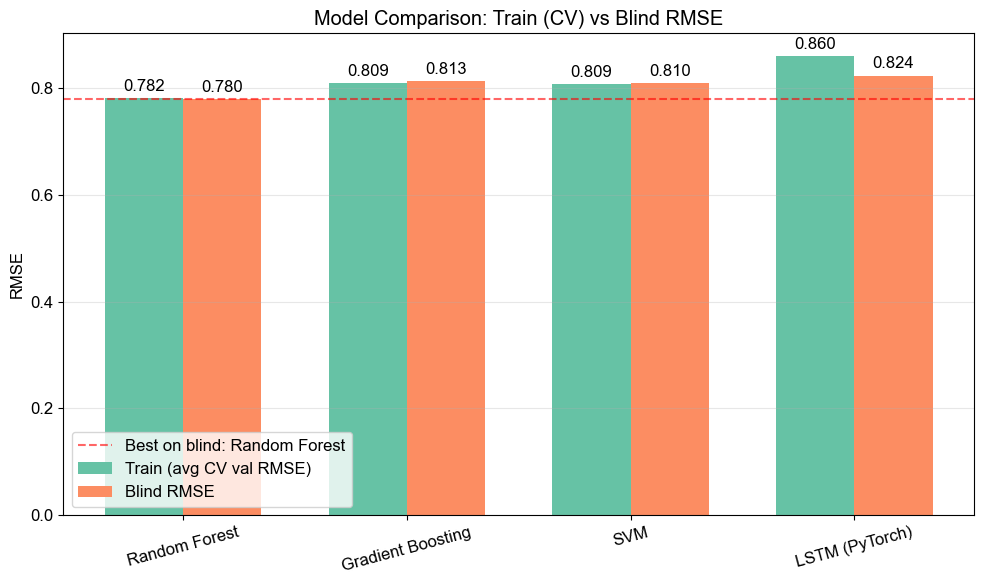


Best model on BLIND data: Random Forest (RMSE = 0.7798)
Best model on TRAIN CV: Random Forest (RMSE = 0.7818)
Overfitting/underfitting plot saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/overfitting_underfitting_RMSE.jpg
Train-versus-blind comparison plot saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model/training_blind_RMSE_model_comparison.jpg
All outputs saved to: /Users/janat/Desktop/ppimic50pred/dataset/data/model


In [12]:
"""
IC50 Model Comparison — Train vs Blind RMSE

Reads rdkit_train.csv and rdkit_blind.csv, removes excluded columns,
performs 10-fold cross-validation using RF, GBM, SVM, and LSTM,
and compares average cross-validation RMSE with blind-set RMSE.
"""

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)


# ============================================================
# 1. Paths
# ============================================================
data_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data"
)

train_file = data_dir / "rdkit_train.csv"
blind_file = data_dir / "rdkit_blind.csv"

output_dir = data_dir / "model"
output_dir.mkdir(parents=True, exist_ok=True)

rmse_plot_file = (
    output_dir /
    "training_blind_RMSE_model_comparison.jpg"
)

overfit_plot_file = (
    output_dir /
    "overfitting_underfitting_RMSE.jpg"
)

processed_train_path = (
    output_dir /
    "processed_train_data_RMSE.csv"
)

processed_blind_path = (
    output_dir /
    "processed_blind_data_RMSE.csv"
)

cv_summary_path = (
    output_dir /
    "cv_RMSE_scores_summary.csv"
)

cv_raw_path = (
    output_dir /
    "cv_RMSE_scores_raw.csv"
)

blind_scores_path = (
    output_dir /
    "blind_RMSE_scores_summary.csv"
)

train_vs_blind_path = (
    output_dir /
    "train_vs_blind_RMSE.csv"
)

features_path = (
    output_dir /
    "features_filtered_RMSE.pkl"
)


# ============================================================
# 2. Columns to drop
# ============================================================
cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles"
]

drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name"
]

drop_cols = list(
    dict.fromkeys(
        cols_to_drop1 + drop_cols2
    )
)


# ============================================================
# 3. Metrics
# ============================================================
def medape(y_true, y_pred, epsilon=1e-3):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true > epsilon

    if np.sum(mask) == 0:
        return np.nan

    return np.median(
        np.abs(
            (y_true[mask] - y_pred[mask]) /
            y_true[mask]
        )
    ) * 100


def smape(y_true, y_pred, epsilon=1e-3):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    ) / 2.0

    denominator = np.where(
        denominator < epsilon,
        epsilon,
        denominator
    )

    return np.mean(
        np.abs(y_true - y_pred) /
        denominator
    ) * 100


# ============================================================
# 4. LSTM model
# ============================================================
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        activation="relu"
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }

        self.activation = activations.get(
            activation,
            None
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]

        out = (
            self.activation(out)
            if self.activation
            else out
        )

        return self.fc(out)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=200,
    patience=20,
    lr=0.001
):
    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        model.train()

        for xb, yb in train_loader:
            optimizer.zero_grad()

            loss = criterion(
                model(xb),
                yb
            )

            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss = criterion(
                    model(xb),
                    yb
                )

                val_losses.append(
                    val_loss.item()
                )

        avg_val_loss = np.mean(
            val_losses
        )

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = model.state_dict()
            patience_counter = 0

        else:
            patience_counter += 1

            if patience_counter >= patience:
                break

    model.load_state_dict(
        best_state
    )

    return model


def main():

    # ============================================================
    # 5. Load train and blind data
    # ============================================================
    print(f"Reading train file: {train_file}")
    rdkit_train = pd.read_csv(train_file)
    print(f"Train shape: {rdkit_train.shape}")

    print(f"Reading blind file: {blind_file}")
    rdkit_blind = pd.read_csv(blind_file)
    print(f"Blind shape: {rdkit_blind.shape}")


    # ============================================================
    # 6. Best hyperparameters
    # ============================================================
    rf_best_params = {
        "n_estimators": 300,
        "max_depth": None,
        "random_state": 42
    }

    lstm_best_params = {
        "hidden_size": 64,
        "num_layers": 2,
        "activation": "relu",
        "batch_size": 32,
        "learning_rate": 0.001
    }


    # ============================================================
    # 7. Prepare training data
    # ============================================================
    y = rdkit_train["log_ic50"]

    X = rdkit_train.drop(
        columns=[
            col
            for col in drop_cols
            if col in rdkit_train.columns
        ]
    )

    X = X.replace(
        r"^\s*$",
        np.nan,
        regex=True
    )

    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    X = X.fillna(
        X.mean()
    )

    features_filtered = X.columns.tolist()

    X_selected = X[
        features_filtered
    ]

    print(
        f"X_selected shape: "
        f"{X_selected.shape}"
    )


    # ============================================================
    # 8. Prepare blind data
    # ============================================================
    y_blind = rdkit_blind["log_ic50"]

    X_blind = rdkit_blind.drop(
        columns=[
            col
            for col in drop_cols
            if col in rdkit_blind.columns
        ]
    )

    X_blind = X_blind.replace(
        r"^\s*$",
        np.nan,
        regex=True
    )

    X_blind = X_blind.apply(
        pd.to_numeric,
        errors="coerce"
    )

    X_blind = X_blind.fillna(
        X_blind.mean()
    )

    missing_in_blind = [
        column
        for column in features_filtered
        if column not in X_blind.columns
    ]

    extra_in_blind = [
        column
        for column in X_blind.columns
        if column not in features_filtered
    ]

    if missing_in_blind:
        print(
            f"Warning: {len(missing_in_blind)} training "
            "features are missing in the blind set. "
            "They will be filled with 0."
        )

        for column in missing_in_blind:
            X_blind[column] = 0

    if extra_in_blind:
        print(
            f"Note: {len(extra_in_blind)} extra blind-set "
            "columns will be dropped."
        )

    X_blind_selected = X_blind[
        features_filtered
    ]

    print(
        f"X_blind_selected shape: "
        f"{X_blind_selected.shape}"
    )


    # ============================================================
    # 9. Save processed data
    # ============================================================
    processed_train = X_selected.copy()
    processed_train["log_ic50"] = y.values

    processed_train.to_csv(
        processed_train_path,
        index=False
    )

    print(
        f"Saved processed training data to: "
        f"{processed_train_path}"
    )

    processed_blind = X_blind_selected.copy()
    processed_blind["log_ic50"] = y_blind.values

    processed_blind.to_csv(
        processed_blind_path,
        index=False
    )

    print(
        f"Saved processed blind data to: "
        f"{processed_blind_path}"
    )

    with open(features_path, "wb") as file:
        pickle.dump(
            features_filtered,
            file
        )


    # ============================================================
    # 10. Define models
    # ============================================================
    models = {
        "Random Forest": RandomForestRegressor(
            **rf_best_params
        ),

        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        ),

        "SVM": SVR(),

        "LSTM (PyTorch)": None
    }

    metrics = [
        "RMSE",
        "MSE",
        "R²",
        "MedAPE",
        "SMAPE"
    ]


    # ============================================================
    # 11. Ten-fold cross-validation
    # ============================================================
    kf = KFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    scores = {
        metric: {
            model: []
            for model in models
        }
        for metric in metrics
    }

    train_rmse_hist = {
        model: []
        for model in models
    }

    val_rmse_hist = {
        model: []
        for model in models
    }

    fold_num = 0

    for train_idx, test_idx in kf.split(X_selected):

        fold_num += 1

        print(
            f"Fold {fold_num}/10"
        )

        X_train = X_selected.iloc[
            train_idx
        ]

        X_test = X_selected.iloc[
            test_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        y_test = y.iloc[
            test_idx
        ]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(
            X_train
        )

        X_test_scaled = scaler.transform(
            X_test
        )


        # --------------------------------------------------------
        # Conventional machine-learning models
        # --------------------------------------------------------
        for name, model in models.items():

            if name == "LSTM (PyTorch)":
                continue

            model.fit(
                X_train_scaled,
                y_train
            )

            y_train_pred = np.maximum(
                model.predict(X_train_scaled),
                0
            )

            y_val_pred = np.maximum(
                model.predict(X_test_scaled),
                0
            )

            train_rmse = np.sqrt(
                mean_squared_error(
                    y_train,
                    y_train_pred
                )
            )

            validation_rmse = np.sqrt(
                mean_squared_error(
                    y_test,
                    y_val_pred
                )
            )

            train_rmse_hist[name].append(
                train_rmse
            )

            val_rmse_hist[name].append(
                validation_rmse
            )

            scores["RMSE"][name].append(
                validation_rmse
            )

            scores["MSE"][name].append(
                mean_squared_error(
                    y_test,
                    y_val_pred
                )
            )

            scores["R²"][name].append(
                r2_score(
                    y_test,
                    y_val_pred
                )
            )

            scores["MedAPE"][name].append(
                medape(
                    y_test,
                    y_val_pred
                )
            )

            scores["SMAPE"][name].append(
                smape(
                    np.expm1(y_test),
                    np.expm1(y_val_pred)
                )
            )


        # --------------------------------------------------------
        # LSTM model
        # --------------------------------------------------------
        X_train_seq = X_train_scaled.reshape(
            -1,
            1,
            X_train_scaled.shape[1]
        )

        X_test_seq = X_test_scaled.reshape(
            -1,
            1,
            X_test_scaled.shape[1]
        )

        train_tensor = torch.tensor(
            X_train_seq,
            dtype=torch.float32
        )

        y_train_tensor = torch.tensor(
            y_train.values.reshape(-1, 1),
            dtype=torch.float32
        )

        test_tensor = torch.tensor(
            X_test_seq,
            dtype=torch.float32
        )

        train_ds, val_ds = random_split(
            TensorDataset(
                train_tensor,
                y_train_tensor
            ),
            [
                int(0.8 * len(train_tensor)),
                len(train_tensor) -
                int(0.8 * len(train_tensor))
            ]
        )

        train_loader = DataLoader(
            train_ds,
            batch_size=lstm_best_params["batch_size"],
            shuffle=True
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=lstm_best_params["batch_size"]
        )

        lstm = LSTMRegressor(
            input_size=train_tensor.shape[2],
            hidden_size=lstm_best_params["hidden_size"],
            num_layers=lstm_best_params["num_layers"],
            activation=lstm_best_params["activation"]
        )

        lstm = train_model(
            lstm,
            train_loader,
            val_loader,
            lr=lstm_best_params["learning_rate"]
        )

        lstm.eval()

        with torch.no_grad():

            y_train_pred_lstm = torch.clamp(
                lstm(train_tensor),
                min=0
            ).squeeze().numpy()

            y_val_pred_lstm = torch.clamp(
                lstm(test_tensor),
                min=0
            ).squeeze().numpy()

        lstm_train_rmse = np.sqrt(
            mean_squared_error(
                y_train,
                y_train_pred_lstm
            )
        )

        lstm_validation_rmse = np.sqrt(
            mean_squared_error(
                y_test,
                y_val_pred_lstm
            )
        )

        train_rmse_hist[
            "LSTM (PyTorch)"
        ].append(
            lstm_train_rmse
        )

        val_rmse_hist[
            "LSTM (PyTorch)"
        ].append(
            lstm_validation_rmse
        )

        scores[
            "RMSE"
        ][
            "LSTM (PyTorch)"
        ].append(
            lstm_validation_rmse
        )

        scores[
            "MSE"
        ][
            "LSTM (PyTorch)"
        ].append(
            mean_squared_error(
                y_test,
                y_val_pred_lstm
            )
        )

        scores[
            "R²"
        ][
            "LSTM (PyTorch)"
        ].append(
            r2_score(
                y_test,
                y_val_pred_lstm
            )
        )

        scores[
            "MedAPE"
        ][
            "LSTM (PyTorch)"
        ].append(
            medape(
                y_test,
                y_val_pred_lstm
            )
        )

        scores[
            "SMAPE"
        ][
            "LSTM (PyTorch)"
        ].append(
            smape(
                np.expm1(y_test),
                np.expm1(y_val_pred_lstm)
            )
        )

        torch.save(
            lstm.state_dict(),
            output_dir / f"lstm_RMSE_fold{fold_num}.pt"
        )


    # ============================================================
    # 12. Save cross-validation summaries
    # ============================================================
    summary_rows = []

    for metric in metrics:
        for model in models:
            summary_rows.append({
                "model": model,
                "metric": metric,
                "mean": np.nanmean(
                    scores[metric][model]
                ),
                "std": np.nanstd(
                    scores[metric][model]
                )
            })

    summary_df = pd.DataFrame(
        summary_rows
    )

    summary_df.to_csv(
        cv_summary_path,
        index=False
    )

    raw_rows = []

    for metric in metrics:
        for model in models:
            for fold_index, value in enumerate(
                scores[metric][model],
                start=1
            ):
                raw_rows.append({
                    "model": model,
                    "metric": metric,
                    "fold": fold_index,
                    "value": value
                })

    raw_df = pd.DataFrame(
        raw_rows
    )

    raw_df.to_csv(
        cv_raw_path,
        index=False
    )


    # ============================================================
    # 13. Train full models and evaluate the blind set
    # ============================================================
    final_scaler = StandardScaler()

    X_train_full_scaled = final_scaler.fit_transform(
        X_selected
    )

    X_blind_scaled = final_scaler.transform(
        X_blind_selected
    )

    blind_scores = {
        metric: {}
        for metric in metrics
    }

    for name, model in models.items():

        if name == "LSTM (PyTorch)":
            continue

        print(
            f"Fitting {name} on full training set..."
        )

        model.fit(
            X_train_full_scaled,
            y
        )

        y_blind_pred = np.maximum(
            model.predict(X_blind_scaled),
            0
        )

        blind_scores["RMSE"][name] = np.sqrt(
            mean_squared_error(
                y_blind,
                y_blind_pred
            )
        )

        blind_scores["MSE"][name] = mean_squared_error(
            y_blind,
            y_blind_pred
        )

        blind_scores["R²"][name] = r2_score(
            y_blind,
            y_blind_pred
        )

        blind_scores["MedAPE"][name] = medape(
            y_blind,
            y_blind_pred
        )

        blind_scores["SMAPE"][name] = smape(
            np.expm1(y_blind),
            np.expm1(y_blind_pred)
        )


    # ============================================================
    # LSTM: full training set versus blind set
    # ============================================================
    X_train_full_seq = X_train_full_scaled.reshape(
        -1,
        1,
        X_train_full_scaled.shape[1]
    )

    X_blind_seq = X_blind_scaled.reshape(
        -1,
        1,
        X_blind_scaled.shape[1]
    )

    train_tensor_full = torch.tensor(
        X_train_full_seq,
        dtype=torch.float32
    )

    y_train_tensor_full = torch.tensor(
        y.values.reshape(-1, 1),
        dtype=torch.float32
    )

    blind_tensor = torch.tensor(
        X_blind_seq,
        dtype=torch.float32
    )

    train_ds_full, val_ds_full = random_split(
        TensorDataset(
            train_tensor_full,
            y_train_tensor_full
        ),
        [
            int(0.8 * len(train_tensor_full)),
            len(train_tensor_full) -
            int(0.8 * len(train_tensor_full))
        ]
    )

    train_loader_full = DataLoader(
        train_ds_full,
        batch_size=lstm_best_params["batch_size"],
        shuffle=True
    )

    val_loader_full = DataLoader(
        val_ds_full,
        batch_size=lstm_best_params["batch_size"]
    )

    print(
        "Fitting LSTM (PyTorch) on full training set..."
    )

    lstm_final = LSTMRegressor(
        input_size=train_tensor_full.shape[2],
        hidden_size=lstm_best_params["hidden_size"],
        num_layers=lstm_best_params["num_layers"],
        activation=lstm_best_params["activation"]
    )

    lstm_final = train_model(
        lstm_final,
        train_loader_full,
        val_loader_full,
        lr=lstm_best_params["learning_rate"]
    )

    lstm_final.eval()

    with torch.no_grad():
        y_blind_pred_lstm = torch.clamp(
            lstm_final(blind_tensor),
            min=0
        ).squeeze().numpy()

    blind_scores[
        "RMSE"
    ][
        "LSTM (PyTorch)"
    ] = np.sqrt(
        mean_squared_error(
            y_blind,
            y_blind_pred_lstm
        )
    )

    blind_scores[
        "MSE"
    ][
        "LSTM (PyTorch)"
    ] = mean_squared_error(
        y_blind,
        y_blind_pred_lstm
    )

    blind_scores[
        "R²"
    ][
        "LSTM (PyTorch)"
    ] = r2_score(
        y_blind,
        y_blind_pred_lstm
    )

    blind_scores[
        "MedAPE"
    ][
        "LSTM (PyTorch)"
    ] = medape(
        y_blind,
        y_blind_pred_lstm
    )

    blind_scores[
        "SMAPE"
    ][
        "LSTM (PyTorch)"
    ] = smape(
        np.expm1(y_blind),
        np.expm1(y_blind_pred_lstm)
    )

    torch.save(
        lstm_final.state_dict(),
        output_dir / "lstm_RMSE_final_full_train.pt"
    )


    # ============================================================
    # 14. Save blind scores and comparison table
    # ============================================================
    blind_rows = []

    for metric in metrics:
        for model in models:
            blind_rows.append({
                "model": model,
                "metric": metric,
                "value": blind_scores[metric][model]
            })

    blind_df = pd.DataFrame(
        blind_rows
    )

    blind_df.to_csv(
        blind_scores_path,
        index=False
    )

    avg_val_rmse = {
        model: np.mean(
            scores["RMSE"][model]
        )
        for model in models
    }

    comparison_rows = []

    for model in models:
        comparison_rows.append({
            "model": model,
            "train_cv_rmse": avg_val_rmse[model],
            "blind_rmse": blind_scores["RMSE"][model],
            "gap (blind - train)": (
                blind_scores["RMSE"][model] -
                avg_val_rmse[model]
            )
        })

    comparison_df = pd.DataFrame(
        comparison_rows
    ).sort_values(
        "blind_rmse",
        ascending=True
    )

    comparison_df.to_csv(
        train_vs_blind_path,
        index=False
    )

    print(
        comparison_df.to_string(
            index=False
        )
    )


    # ============================================================
    # 15. Plot: Overfitting/underfitting RMSE across CV folds
    # ============================================================
    plt.figure(
        figsize=(10, 6)
    )

    # Same colors as the R² plot
    colors = sns.color_palette(
        "Set2",
        n_colors=len(models)
    )

    # Same line styles and marker shapes as the R² plot
    for index, model in enumerate(models):

        color = colors[index]

        plt.plot(
            train_rmse_hist[model],
            linestyle="--",
            marker="o",
            color=color,
            label=f"{model} - Train"
        )

        plt.plot(
            val_rmse_hist[model],
            linestyle="-",
            marker="s",
            color=color,
            label=f"{model} - Val"
        )

    plt.xlabel("Fold")
    plt.ylabel("RMSE")

    

    plt.grid(True)

    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1.05, 1)
    )

    plt.tight_layout()

    plt.savefig(
        overfit_plot_file,
        format="jpg",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
        pil_kwargs={
            "quality": 100,
            "subsampling": 0
        }
    )

    plt.show()
    plt.close()


    # ============================================================
    # 16. Plot: Train CV versus blind RMSE
    # ============================================================
    model_names = list(
        models.keys()
    )

    train_values = [
        avg_val_rmse[model]
        for model in model_names
    ]

    blind_values = [
        blind_scores["RMSE"][model]
        for model in model_names
    ]

    x = np.arange(
        len(model_names)
    )

    width = 0.35

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    # Same colors and bar shapes as the R² plot
    bars_train = ax.bar(
        x - width / 2,
        train_values,
        width,
        label="Train (avg CV val RMSE)",
        color=sns.color_palette("Set2")[0]
    )

    bars_blind = ax.bar(
        x + width / 2,
        blind_values,
        width,
        label="Blind RMSE",
        color=sns.color_palette("Set2")[1]
    )

    ax.set_ylabel("RMSE")

    ax.set_title(
        "Model Comparison: Train (CV) vs Blind RMSE"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        model_names,
        rotation=15
    )

    ax.bar_label(
        bars_train,
        fmt="%.3f",
        padding=3
    )

    ax.bar_label(
        bars_blind,
        fmt="%.3f",
        padding=3
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    # Lower blind RMSE indicates the best model
    best_blind_model = min(
        blind_scores["RMSE"],
        key=blind_scores["RMSE"].get
    )

    ax.axhline(
        blind_scores["RMSE"][best_blind_model],
        color="red",
        linestyle="--",
        alpha=0.6,
        label=f"Best on blind: {best_blind_model}"
    )

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        rmse_plot_file,
        format="jpg",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
        pil_kwargs={
            "quality": 100,
            "subsampling": 0
        }
    )

    plt.show()
    plt.close()


    # ============================================================
    # 17. Print final results
    # ============================================================
    best_train_model = min(
        avg_val_rmse,
        key=avg_val_rmse.get
    )

    print(
        "\nBest model on BLIND data: "
        f"{best_blind_model} "
        f"(RMSE = "
        f"{blind_scores['RMSE'][best_blind_model]:.4f})"
    )

    print(
        "Best model on TRAIN CV: "
        f"{best_train_model} "
        f"(RMSE = "
        f"{avg_val_rmse[best_train_model]:.4f})"
    )

    print(
        f"Overfitting/underfitting plot saved to: "
        f"{overfit_plot_file}"
    )

    print(
        f"Train-versus-blind comparison plot saved to: "
        f"{rmse_plot_file}"
    )

    print(
        f"All outputs saved to: "
        f"{output_dir}"
    )


if __name__ == "__main__":
    main()

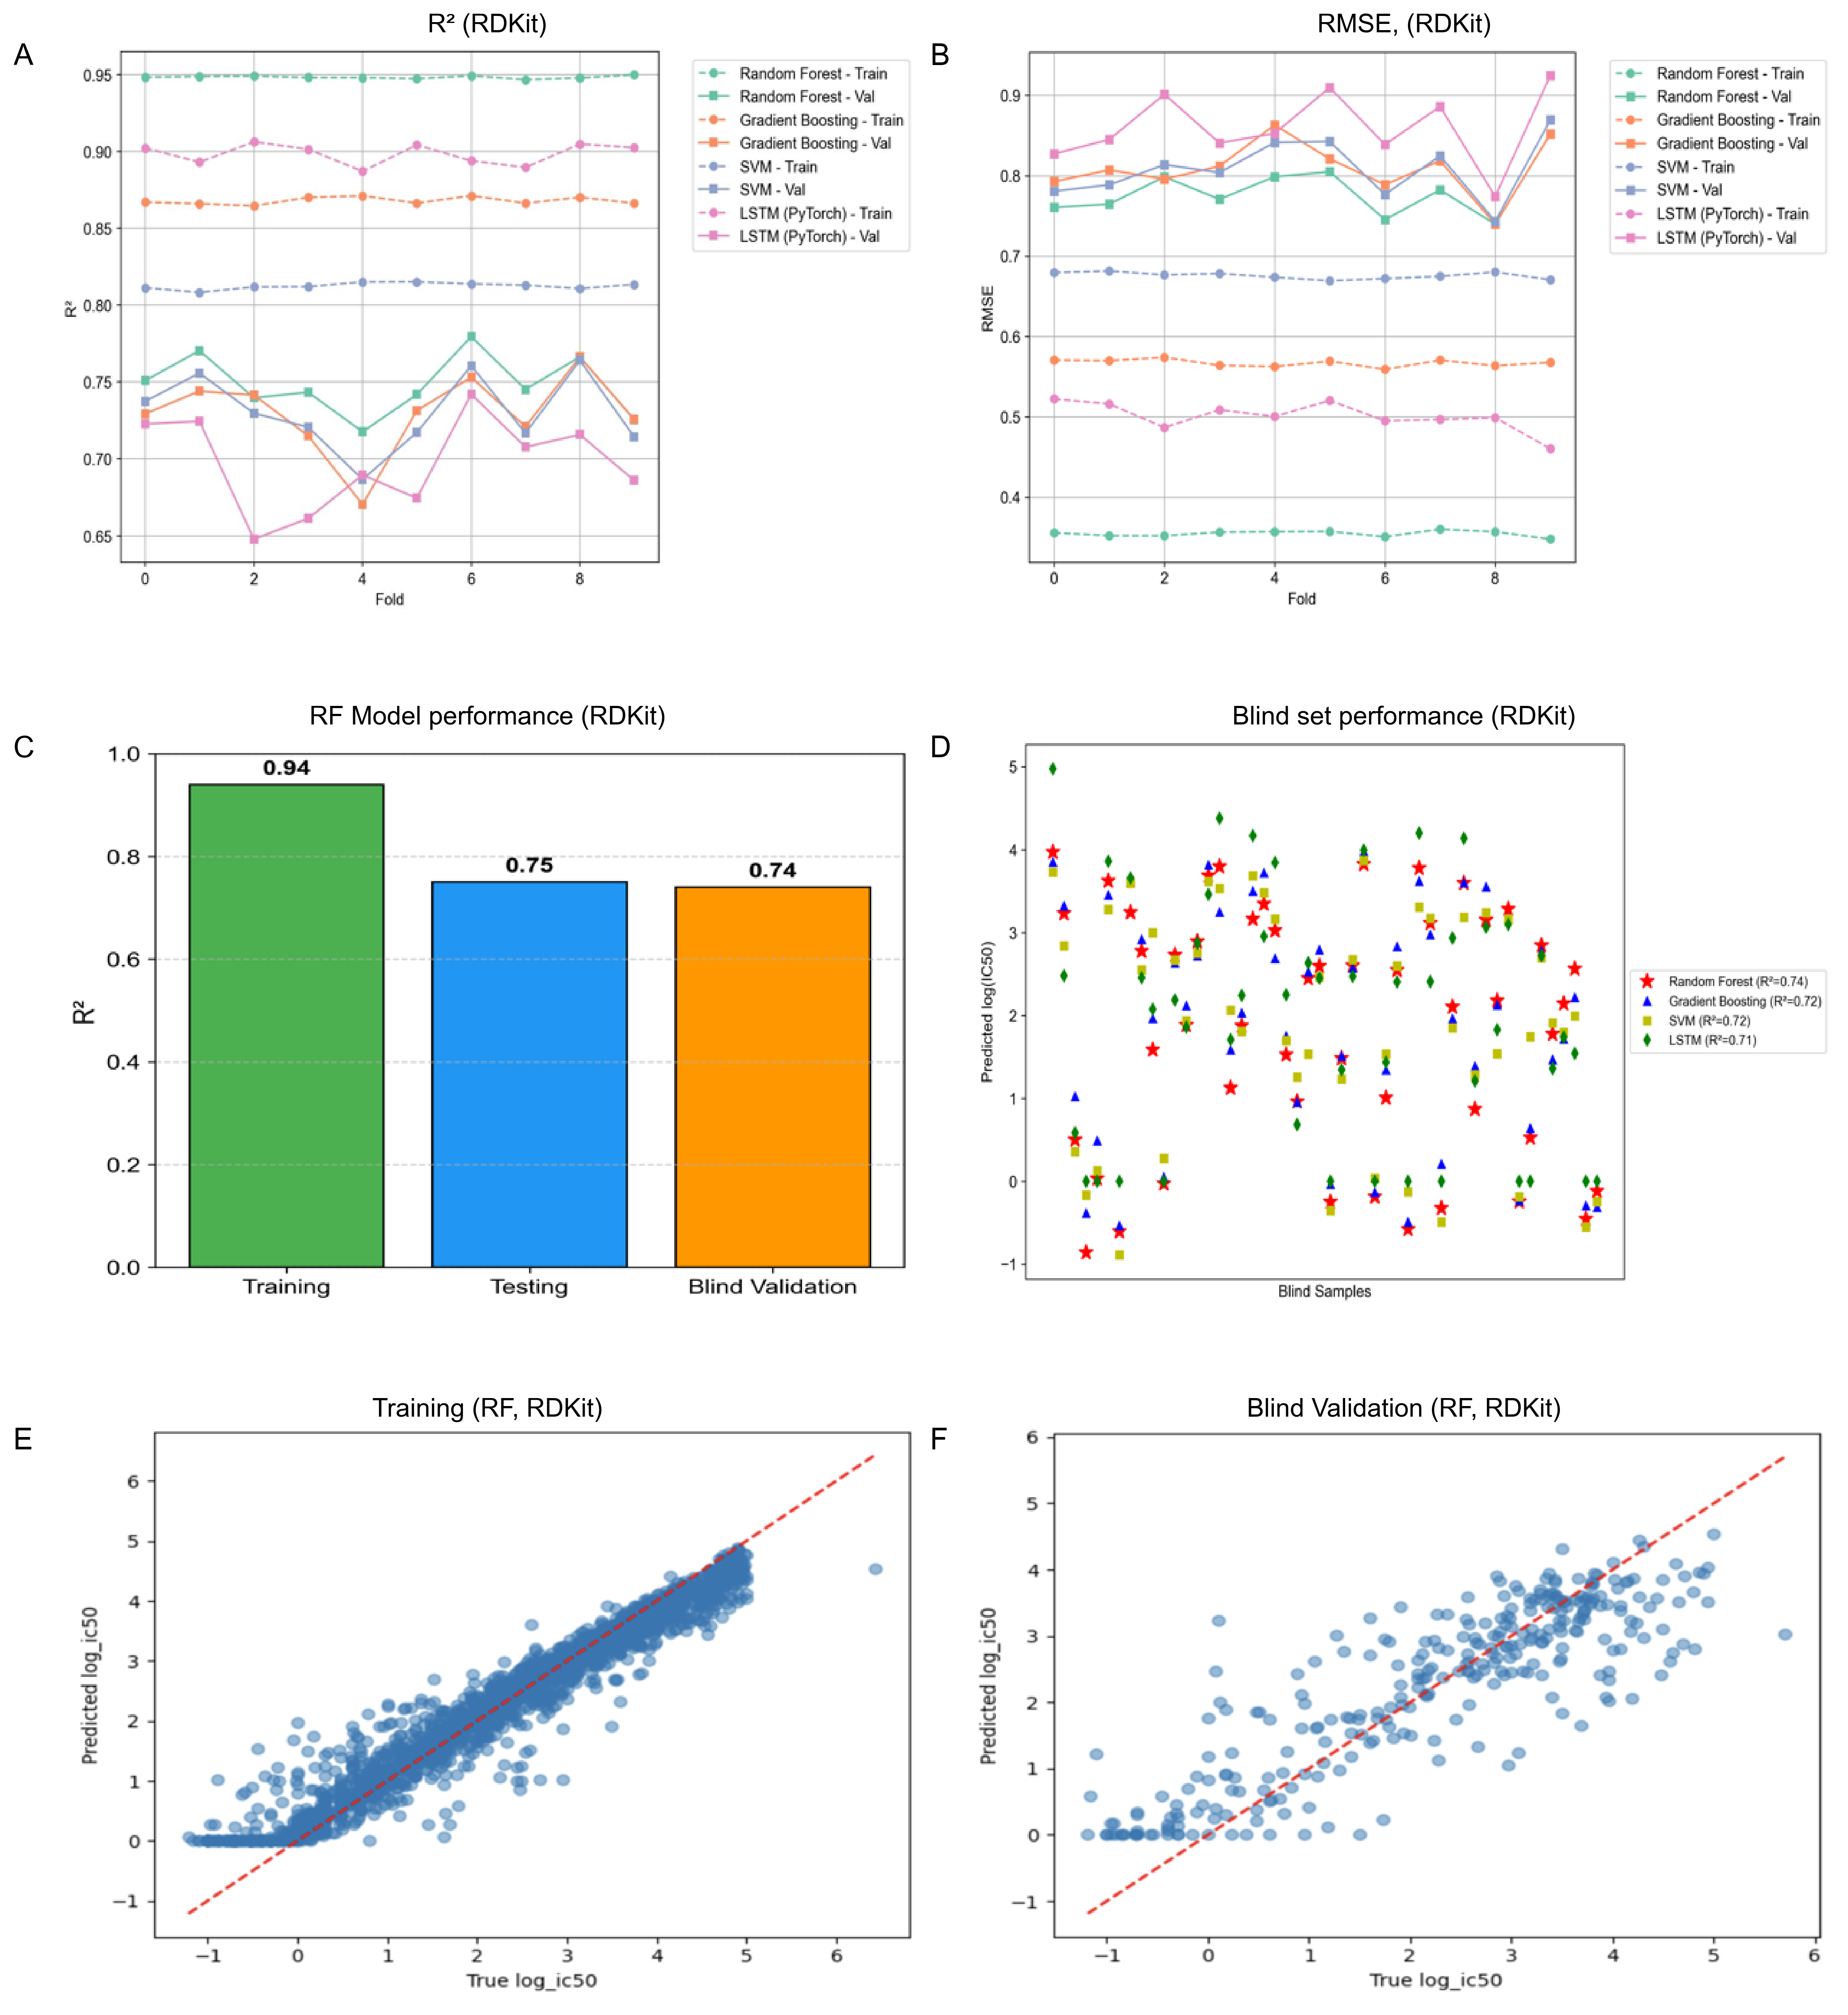

✅ Figure saved at: /Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2.png


In [27]:
import matplotlib.pyplot as plt
from PIL import Image

# ==========================
# Global font configuration
# ==========================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
})

# ==========================
# Image paths and metadata
# ==========================
images = [
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model/overfitting_underfitting_r2.jpg",                     
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model/overfitting_underfitting_RMSE.jpg",                 
    "/Users/janat/Desktop/newplot/RF_R2_Performance.png",                 
    "/Users/janat/Desktop/newplot/newplot/regressor_predictions_blind.png", 
    "/Users/janat/Desktop/newplot/RF_MODEL_Training.png",                 
    "/Users/janat/Desktop/newplot/RF_Model_Blind_set_validation.png",     
]

labels = ['A', 'B', 'C', 'D', 'E', 'F']

captions = [
    "R² (RDKit)",
    "RMSE, (RDKit)",
    "RF Model performance (RDKit)",
    "Blind set performance (RDKit)",
    "Training (RF, RDKit)",
    "Blind Validation (RF, RDKit)",
]

output_path = "/Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2.png"
target_size = (600, 400)

# ==========================
# Create figure with 3 rows × 2 columns
# ==========================
fig, axes = plt.subplots(3, 2, figsize=(14, 16), dpi=300)  # reduced height to compress row spacing
axes = axes.flatten()

for ax, img_path, label, caption in zip(axes, images, labels, captions):
    img = Image.open(img_path).resize(target_size)
    ax.imshow(img)
    ax.axis("off")

    # Panel label
    ax.text(
        -0.05, 1.0, label,
        transform=ax.transAxes,
        fontsize=16,
        va='top',
        ha='left',
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=2)
    )

    # Caption
    ax.set_title(caption, fontsize=14, loc='center')

# Reduce vertical spacing between rows
plt.tight_layout(h_pad=1.0, w_pad=1.0)  # smaller h_pad reduces row gaps
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Figure saved at: {output_path}")


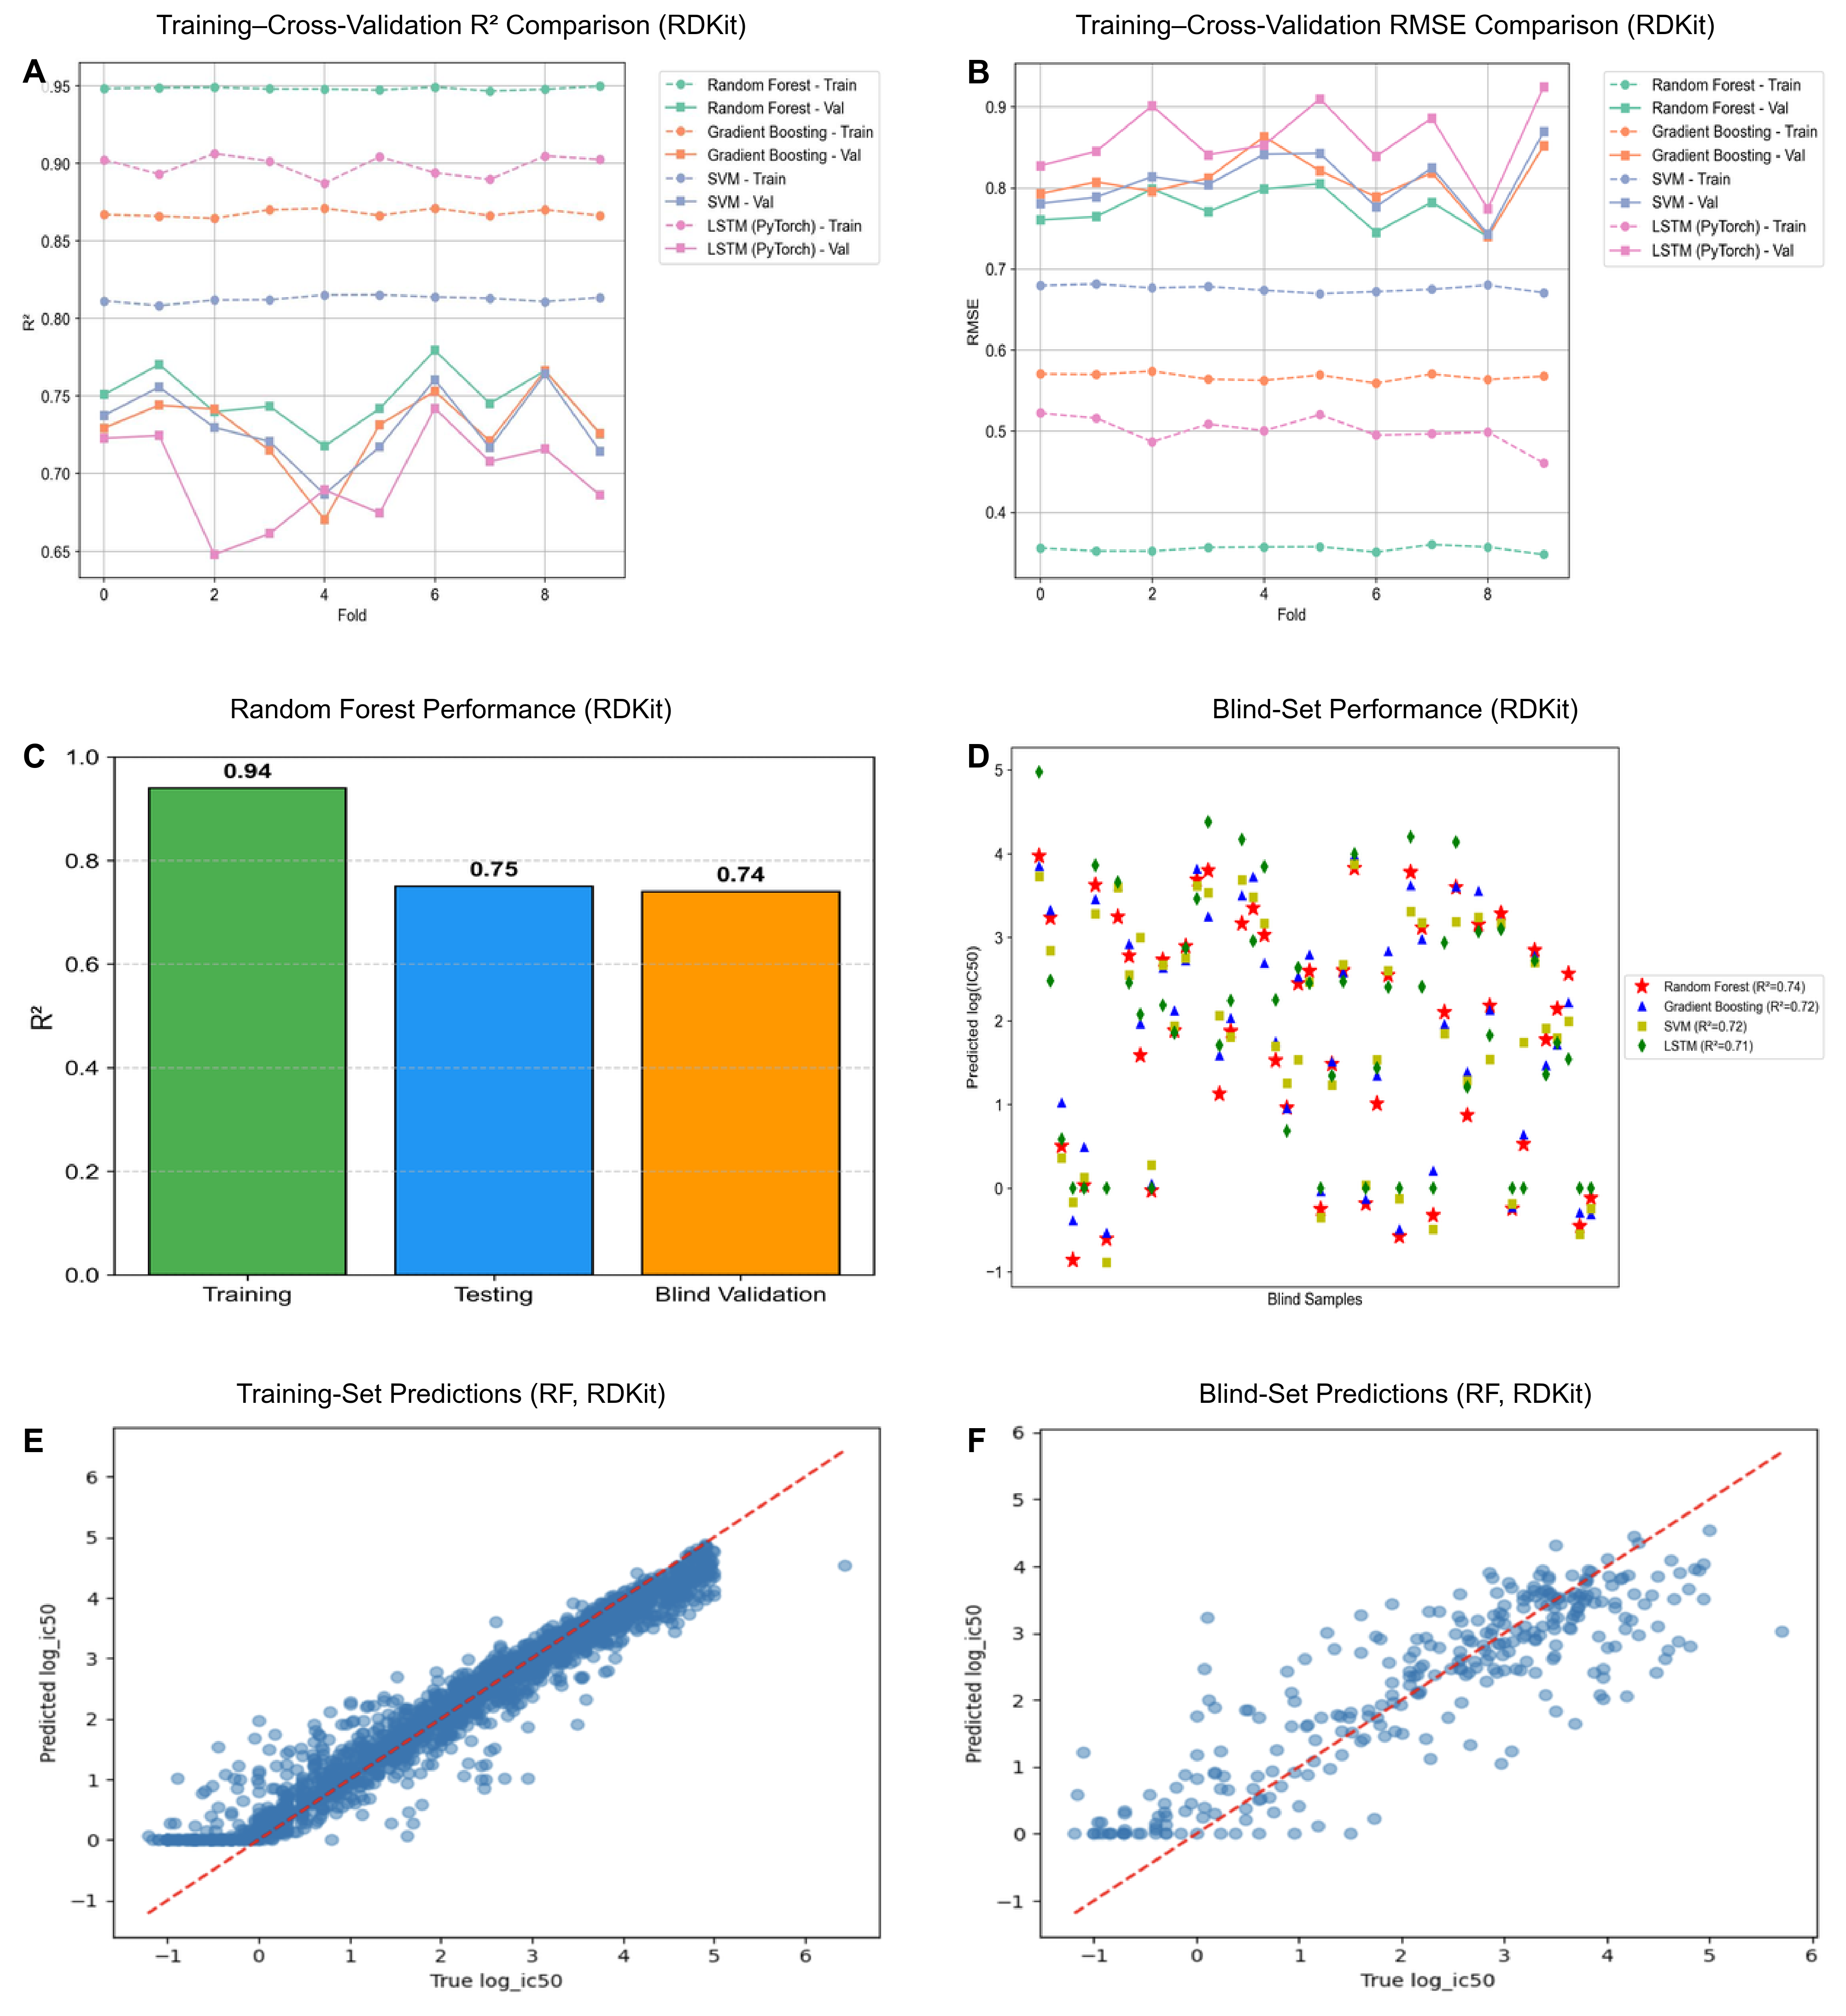

PNG figure saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2.png
JPG figure saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2.jpg


In [41]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


# ==========================
# Global font configuration
# ==========================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
})


# ==========================
# Image paths and metadata
# ==========================
images = [
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model/overfitting_underfitting_r2.jpg",
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model/overfitting_underfitting_RMSE.jpg",
    "/Users/janat/Desktop/newplot/RF_R2_Performance.png",
    "/Users/janat/Desktop/newplot/newplot/regressor_predictions_blind.png",
    "/Users/janat/Desktop/newplot/RF_MODEL_Training.png",
    "/Users/janat/Desktop/newplot/RF_Model_Blind_set_validation.png",
]

labels = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F"
]

captions = [
    "Training–Cross-Validation R² Comparison (RDKit)",
    "Training–Cross-Validation RMSE Comparison (RDKit)",
    "Random Forest Performance (RDKit)",
    "Blind-Set Performance (RDKit)",
    "Training-Set Predictions (RF, RDKit)",
    "Blind-Set Predictions (RF, RDKit)",
]


# ==========================
# Output paths
# ==========================
output_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

png_output_path = (
    output_dir / "Figure2.png"
)

jpg_output_path = (
    output_dir / "Figure2.jpg"
)


# ==========================
# Target panel size
# ==========================
target_size = (
    600,
    400
)


# ==========================
# Create 3 × 2 composite figure
# ==========================
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 15),
    dpi=300,
    facecolor="white"
)

axes = axes.flatten()


# ==========================
# Add images, labels and headings
# ==========================
for ax, img_path, label, caption in zip(
    axes,
    images,
    labels,
    captions
):
    image_path = Path(img_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image was not found:\n{image_path}"
        )

    with Image.open(image_path) as source_image:
        image = source_image.convert("RGB")

        image = image.resize(
            target_size,
            Image.Resampling.LANCZOS
        )

    ax.imshow(
        image,
        aspect="auto"
    )

    ax.axis("off")

    # Regular, non-bold panel heading
    ax.text(
        0.50,
        1.025,
        caption,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="normal",
        ha="center",
        va="bottom",
        color="black",
        clip_on=False
    )

    # Bold panel label
    ax.text(
        0.01,
        0.99,
        label,
        transform=ax.transAxes,
        fontsize=17,
        fontweight="bold",
        ha="left",
        va="top",
        color="black",
        bbox={
            "facecolor": "white",
            "alpha": 0.80,
            "edgecolor": "none",
            "pad": 2
        }
    )


# ==========================
# Adjust panel spacing
# ==========================
fig.subplots_adjust(
    left=0.03,
    right=0.97,
    bottom=0.03,
    top=0.97,
    wspace=0.08,
    hspace=0.18
)


# ==========================
# Save as PNG at 300 dpi
# ==========================
fig.savefig(
    png_output_path,
    format="png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white"
)


# ==========================
# Save as JPG at 300 dpi
# ==========================
fig.savefig(
    jpg_output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)


# ==========================
# Display and close figure
# ==========================
plt.show()
plt.close(fig)


# ==========================
# Print output locations
# ==========================
print(
    f"PNG figure saved at:\n"
    f"{png_output_path}"
)

print(
    f"JPG figure saved at:\n"
    f"{jpg_output_path}"
)

Cross-validation summary columns:
['model', 'metric', 'mean', 'std']

Blind-set summary columns:
['model', 'metric', 'value']


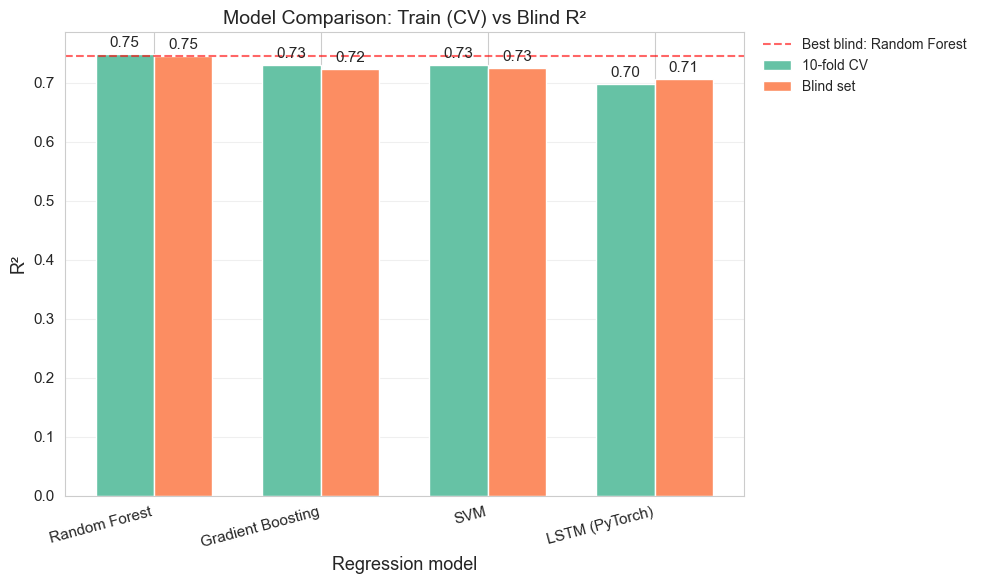

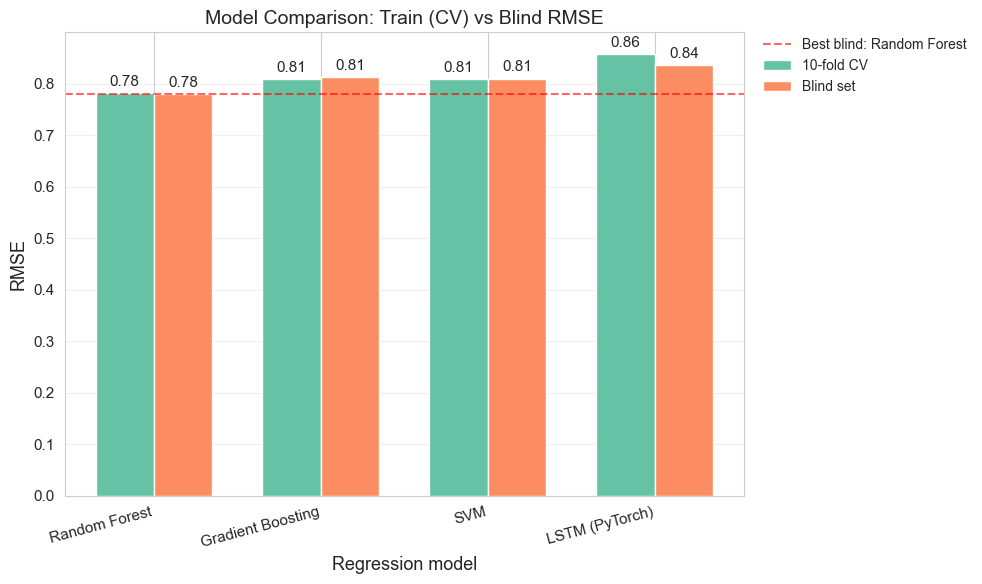


R² comparison:
Random Forest: 10-fold CV = 0.75; Blind = 0.75
Gradient Boosting: 10-fold CV = 0.73; Blind = 0.72
SVM: 10-fold CV = 0.73; Blind = 0.73
LSTM (PyTorch): 10-fold CV = 0.70; Blind = 0.71

RMSE comparison:
Random Forest: 10-fold CV = 0.78; Blind = 0.78
Gradient Boosting: 10-fold CV = 0.81; Blind = 0.81
SVM: 10-fold CV = 0.81; Blind = 0.81
LSTM (PyTorch): 10-fold CV = 0.86; Blind = 0.84

R² plot saved to:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/A_Model_Comparison_Train_CV_vs_Blind_R2.jpg
RMSE plot saved to:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/B_Model_Comparison_Train_CV_vs_Blind_RMSE.jpg


In [43]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==================================================
# 1. Global publication-style settings
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

sns.set_style("whitegrid")


# ==================================================
# 2. Input and output paths
# ==================================================
output_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model"
)

cv_summary_file = (
    output_dir / "cv_scores_summary.csv"
)

blind_summary_file = (
    output_dir / "blind_scores_summary.csv"
)

r2_output_file = (
    output_dir /
    "A_Model_Comparison_Train_CV_vs_Blind_R2.jpg"
)

rmse_output_file = (
    output_dir /
    "B_Model_Comparison_Train_CV_vs_Blind_RMSE.jpg"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)


# ==================================================
# 3. Check input files
# ==================================================
if not cv_summary_file.exists():
    raise FileNotFoundError(
        f"Cross-validation summary was not found:\n"
        f"{cv_summary_file}"
    )

if not blind_summary_file.exists():
    raise FileNotFoundError(
        f"Blind-set summary was not found:\n"
        f"{blind_summary_file}"
    )


# ==================================================
# 4. Read the saved results
# ==================================================
cv_summary = pd.read_csv(
    cv_summary_file
)

blind_summary = pd.read_csv(
    blind_summary_file
)

print("Cross-validation summary columns:")
print(cv_summary.columns.tolist())

print("\nBlind-set summary columns:")
print(blind_summary.columns.tolist())


# ==================================================
# 5. Model order
# ==================================================
model_order = [
    "Random Forest",
    "Gradient Boosting",
    "SVM",
    "LSTM (PyTorch)"
]

colors = sns.color_palette(
    "Set2",
    n_colors=2
)

cv_color = colors[0]
blind_color = colors[1]


# ==================================================
# 6. Function to extract metric values
# ==================================================
def extract_metric_values(metric_name):

    cv_metric = cv_summary[
        cv_summary["metric"] == metric_name
    ].copy()

    blind_metric = blind_summary[
        blind_summary["metric"] == metric_name
    ].copy()

    cv_values = (
        cv_metric
        .set_index("model")
        .reindex(model_order)["mean"]
        .to_numpy()
    )

    blind_values = (
        blind_metric
        .set_index("model")
        .reindex(model_order)["value"]
        .to_numpy()
    )

    if np.isnan(cv_values).any():
        raise ValueError(
            f"Missing cross-validation values for {metric_name}."
        )

    if np.isnan(blind_values).any():
        raise ValueError(
            f"Missing blind-set values for {metric_name}."
        )

    return cv_values, blind_values


# ==================================================
# 7. Function to add two-decimal bar labels
# ==================================================
def add_bar_labels(axis, bars):

    axis.bar_label(
        bars,
        labels=[
            f"{bar.get_height():.2f}"
            for bar in bars
        ],
        padding=3,
        fontsize=11
    )


# ==================================================
# 8. Plot A: Train CV versus blind R²
# ==================================================
cv_r2, blind_r2 = extract_metric_values(
    "R²"
)

x_positions = np.arange(
    len(model_order)
)

bar_width = 0.35

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="white"
)

cv_bars = ax.bar(
    x_positions - bar_width / 2,
    cv_r2,
    bar_width,
    label="10-fold CV",
    color=cv_color
)

blind_bars = ax.bar(
    x_positions + bar_width / 2,
    blind_r2,
    bar_width,
    label="Blind set",
    color=blind_color
)

ax.set_xlabel("Regression model")
ax.set_ylabel("R²")

ax.set_title(
    "Model Comparison: Train (CV) vs Blind R²",
    fontweight="normal"
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    model_order,
    rotation=15,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.30
)

add_bar_labels(
    ax,
    cv_bars
)

add_bar_labels(
    ax,
    blind_bars
)

best_blind_r2_model = model_order[
    int(np.argmax(blind_r2))
]

best_blind_r2 = np.max(
    blind_r2
)

ax.axhline(
    best_blind_r2,
    color="red",
    linestyle="--",
    alpha=0.60,
    label=f"Best blind: {best_blind_r2_model}"
)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0
)

fig.tight_layout()

fig.savefig(
    r2_output_file,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# 9. Plot B: Train CV versus blind RMSE
# ==================================================
cv_rmse, blind_rmse = extract_metric_values(
    "RMSE"
)

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor="white"
)

cv_bars = ax.bar(
    x_positions - bar_width / 2,
    cv_rmse,
    bar_width,
    label="10-fold CV",
    color=cv_color
)

blind_bars = ax.bar(
    x_positions + bar_width / 2,
    blind_rmse,
    bar_width,
    label="Blind set",
    color=blind_color
)

ax.set_xlabel("Regression model")
ax.set_ylabel("RMSE")

ax.set_title(
    "Model Comparison: Train (CV) vs Blind RMSE",
    fontweight="normal"
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    model_order,
    rotation=15,
    ha="right"
)

ax.grid(
    axis="y",
    alpha=0.30
)

add_bar_labels(
    ax,
    cv_bars
)

add_bar_labels(
    ax,
    blind_bars
)

best_blind_rmse_model = model_order[
    int(np.argmin(blind_rmse))
]

best_blind_rmse = np.min(
    blind_rmse
)

ax.axhline(
    best_blind_rmse,
    color="red",
    linestyle="--",
    alpha=0.60,
    label=f"Best blind: {best_blind_rmse_model}"
)

# Legend outside the plot
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0
)

fig.tight_layout()

fig.savefig(
    rmse_output_file,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# 10. Print values and output locations
# ==================================================
print("\nR² comparison:")

for model, cv_value, blind_value in zip(
    model_order,
    cv_r2,
    blind_r2
):
    print(
        f"{model}: "
        f"10-fold CV = {cv_value:.2f}; "
        f"Blind = {blind_value:.2f}"
    )

print("\nRMSE comparison:")

for model, cv_value, blind_value in zip(
    model_order,
    cv_rmse,
    blind_rmse
):
    print(
        f"{model}: "
        f"10-fold CV = {cv_value:.2f}; "
        f"Blind = {blind_value:.2f}"
    )

print(
    f"\nR² plot saved to:\n"
    f"{r2_output_file}"
)

print(
    f"RMSE plot saved to:\n"
    f"{rmse_output_file}"
)

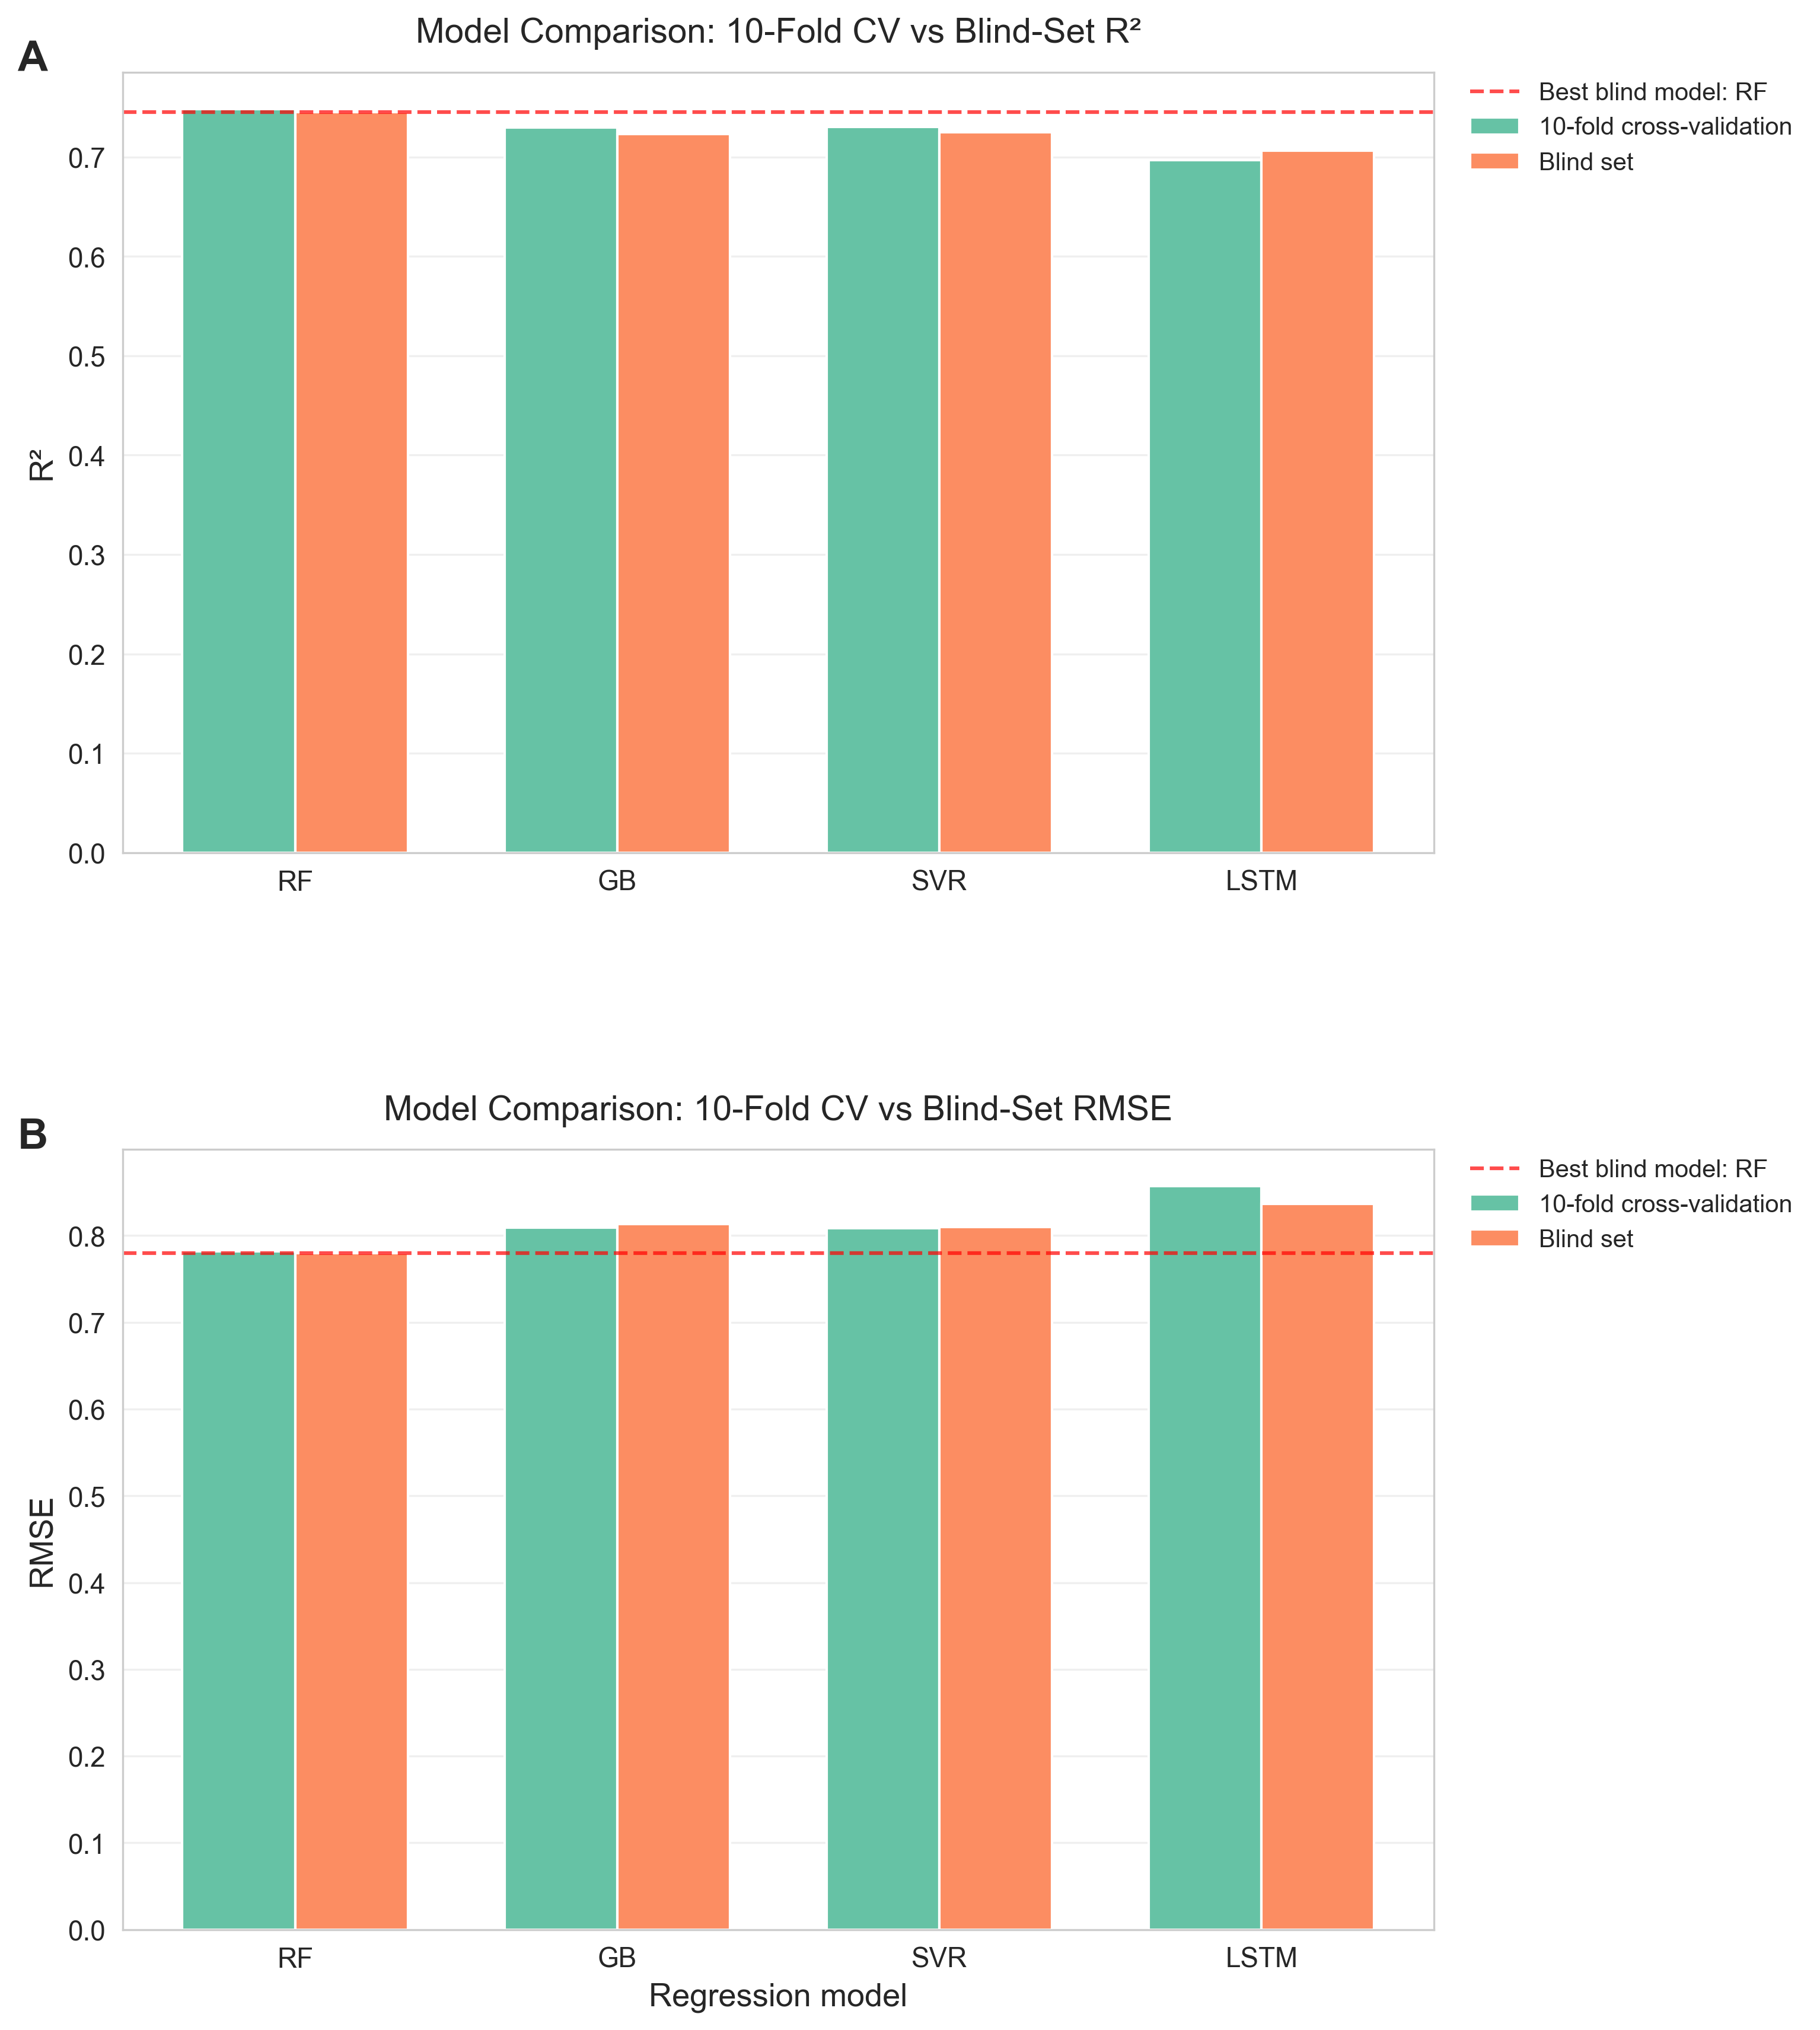

PNG figure saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2_AB_CV_Blind_Comparison.png
JPG figure saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/Figure2_AB_CV_Blind_Comparison.jpg


In [47]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==================================================
# 1. Global publication-style settings
# ==================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

sns.set_style("whitegrid")


# ==================================================
# 2. Input and output paths
# ==================================================
output_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data/model"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

cv_summary_file = (
    output_dir / "cv_scores_summary.csv"
)

blind_summary_file = (
    output_dir / "blind_scores_summary.csv"
)

png_output_path = (
    output_dir /
    "Figure2_AB_CV_Blind_Comparison.png"
)

jpg_output_path = (
    output_dir /
    "Figure2_AB_CV_Blind_Comparison.jpg"
)


# ==================================================
# 3. Check the input files
# ==================================================
if not cv_summary_file.exists():
    raise FileNotFoundError(
        f"Cross-validation summary was not found:\n"
        f"{cv_summary_file}"
    )

if not blind_summary_file.exists():
    raise FileNotFoundError(
        f"Blind-set summary was not found:\n"
        f"{blind_summary_file}"
    )


# ==================================================
# 4. Read the saved results
# ==================================================
cv_summary = pd.read_csv(
    cv_summary_file
)

blind_summary = pd.read_csv(
    blind_summary_file
)


# ==================================================
# 5. Model names and display labels
# ==================================================
# Full names are required to extract results from CSV files.
model_order = [
    "Random Forest",
    "Gradient Boosting",
    "SVM",
    "LSTM (PyTorch)"
]

# Abbreviated names are displayed on the plots.
model_labels = [
    "RF",
    "GB",
    "SVR",
    "LSTM"
]

model_label_map = {
    "Random Forest": "RF",
    "Gradient Boosting": "GB",
    "SVM": "SVR",
    "LSTM (PyTorch)": "LSTM"
}


# ==================================================
# 6. Plot colors
# ==================================================
colors = sns.color_palette(
    "Set2",
    n_colors=2
)

cv_color = colors[0]
blind_color = colors[1]


# ==================================================
# 7. Extract metric values
# ==================================================
def extract_metric_values(metric_name):

    cv_metric = cv_summary[
        cv_summary["metric"] == metric_name
    ].copy()

    blind_metric = blind_summary[
        blind_summary["metric"] == metric_name
    ].copy()

    cv_values = (
        cv_metric
        .set_index("model")
        .reindex(model_order)["mean"]
        .to_numpy()
    )

    blind_values = (
        blind_metric
        .set_index("model")
        .reindex(model_order)["value"]
        .to_numpy()
    )

    if np.isnan(cv_values).any():
        raise ValueError(
            f"Missing 10-fold cross-validation "
            f"values for {metric_name}."
        )

    if np.isnan(blind_values).any():
        raise ValueError(
            f"Missing blind-set values for "
            f"{metric_name}."
        )

    return cv_values, blind_values


# ==================================================
# 8. Extract R² and RMSE values
# ==================================================
cv_r2, blind_r2 = extract_metric_values(
    "R²"
)

cv_rmse, blind_rmse = extract_metric_values(
    "RMSE"
)


# ==================================================
# 9. Bar positions
# ==================================================
x_positions = np.arange(
    len(model_order)
)

bar_width = 0.35


# ==================================================
# 10. Create a vertical two-panel figure
# ==================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11, 12),
    dpi=300,
    facecolor="white"
)

ax_a = axes[0]
ax_b = axes[1]


# ==================================================
# 11. Panel A: 10-fold CV versus blind-set R²
# ==================================================
ax_a.bar(
    x_positions - bar_width / 2,
    cv_r2,
    bar_width,
    label="10-fold cross-validation",
    color=cv_color
)

ax_a.bar(
    x_positions + bar_width / 2,
    blind_r2,
    bar_width,
    label="Blind set",
    color=blind_color
)


# Best blind-set R² model: higher R² is better
best_r2_index = int(
    np.argmax(blind_r2)
)

best_r2_model = model_order[
    best_r2_index
]

best_r2_value = blind_r2[
    best_r2_index
]

ax_a.axhline(
    y=best_r2_value,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.70,
    label=(
        f"Best blind model: "
        f"{model_label_map[best_r2_model]}"
    )
)


# Panel A formatting
ax_a.set_ylabel(
    "R²"
)

ax_a.set_title(
    "Model Comparison: 10-Fold CV vs Blind-Set R²",
    fontsize=14,
    fontweight="normal",
    pad=12
)

ax_a.set_xticks(
    x_positions
)

ax_a.set_xticklabels(
    model_labels,
    rotation=0,
    ha="center"
)

ax_a.grid(
    axis="y",
    alpha=0.30
)

ax_a.grid(
    axis="x",
    visible=False
)

# Panel label A
ax_a.text(
    -0.08,
    1.04,
    "A",
    transform=ax_a.transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)

# Legend outside panel A
ax_a.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0
)


# ==================================================
# 12. Panel B: 10-fold CV versus blind-set RMSE
# ==================================================
ax_b.bar(
    x_positions - bar_width / 2,
    cv_rmse,
    bar_width,
    label="10-fold cross-validation",
    color=cv_color
)

ax_b.bar(
    x_positions + bar_width / 2,
    blind_rmse,
    bar_width,
    label="Blind set",
    color=blind_color
)


# Best blind-set RMSE model: lower RMSE is better
best_rmse_index = int(
    np.argmin(blind_rmse)
)

best_rmse_model = model_order[
    best_rmse_index
]

best_rmse_value = blind_rmse[
    best_rmse_index
]

ax_b.axhline(
    y=best_rmse_value,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.70,
    label=(
        f"Best blind model: "
        f"{model_label_map[best_rmse_model]}"
    )
)


# Panel B formatting
ax_b.set_xlabel(
    "Regression model"
)

ax_b.set_ylabel(
    "RMSE"
)

ax_b.set_title(
    "Model Comparison: 10-Fold CV vs Blind-Set RMSE",
    fontsize=14,
    fontweight="normal",
    pad=12
)

ax_b.set_xticks(
    x_positions
)

ax_b.set_xticklabels(
    model_labels,
    rotation=0,
    ha="center"
)

ax_b.grid(
    axis="y",
    alpha=0.30
)

ax_b.grid(
    axis="x",
    visible=False
)

# Panel label B
ax_b.text(
    -0.08,
    1.04,
    "B",
    transform=ax_b.transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)

# Legend outside panel B
ax_b.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False,
    borderaxespad=0
)


# ==================================================
# 13. Adjust panel spacing
# ==================================================
fig.subplots_adjust(
    left=0.11,
    right=0.78,
    bottom=0.08,
    top=0.95,
    hspace=0.38
)


# ==================================================
# 14. Save as PNG at 300 dpi
# ==================================================
fig.savefig(
    png_output_path,
    format="png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white"
)


# ==================================================
# 15. Save as JPG at 300 dpi
# ==================================================
fig.savefig(
    jpg_output_path,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)


# ==================================================
# 16. Display and close the figure
# ==================================================
plt.show()
plt.close(fig)


# ==================================================
# 17. Print only output locations
# ==================================================
print(
    f"PNG figure saved at:\n"
    f"{png_output_path}"
)

print(
    f"JPG figure saved at:\n"
    f"{jpg_output_path}"
)

Training dataset shape: (2760, 223)
Blind dataset shape: (691, 223)
Final training samples: 2760
Final training descriptors: 195
Final blind samples: 691
Final blind descriptors: 195
RF fold 1/10: training MSE = 0.1233; validation MSE = 0.5631
RF fold 2/10: training MSE = 0.1222; validation MSE = 0.5712
RF fold 3/10: training MSE = 0.1204; validation MSE = 0.6229
RF fold 4/10: training MSE = 0.1229; validation MSE = 0.6012
RF fold 5/10: training MSE = 0.1240; validation MSE = 0.6203
RF fold 6/10: training MSE = 0.1258; validation MSE = 0.6547
RF fold 7/10: training MSE = 0.1182; validation MSE = 0.5812
RF fold 8/10: training MSE = 0.1259; validation MSE = 0.6094
RF fold 9/10: training MSE = 0.1250; validation MSE = 0.5492
RF fold 10/10: training MSE = 0.1197; validation MSE = 0.6932
LSTM early stopping at epoch 104.


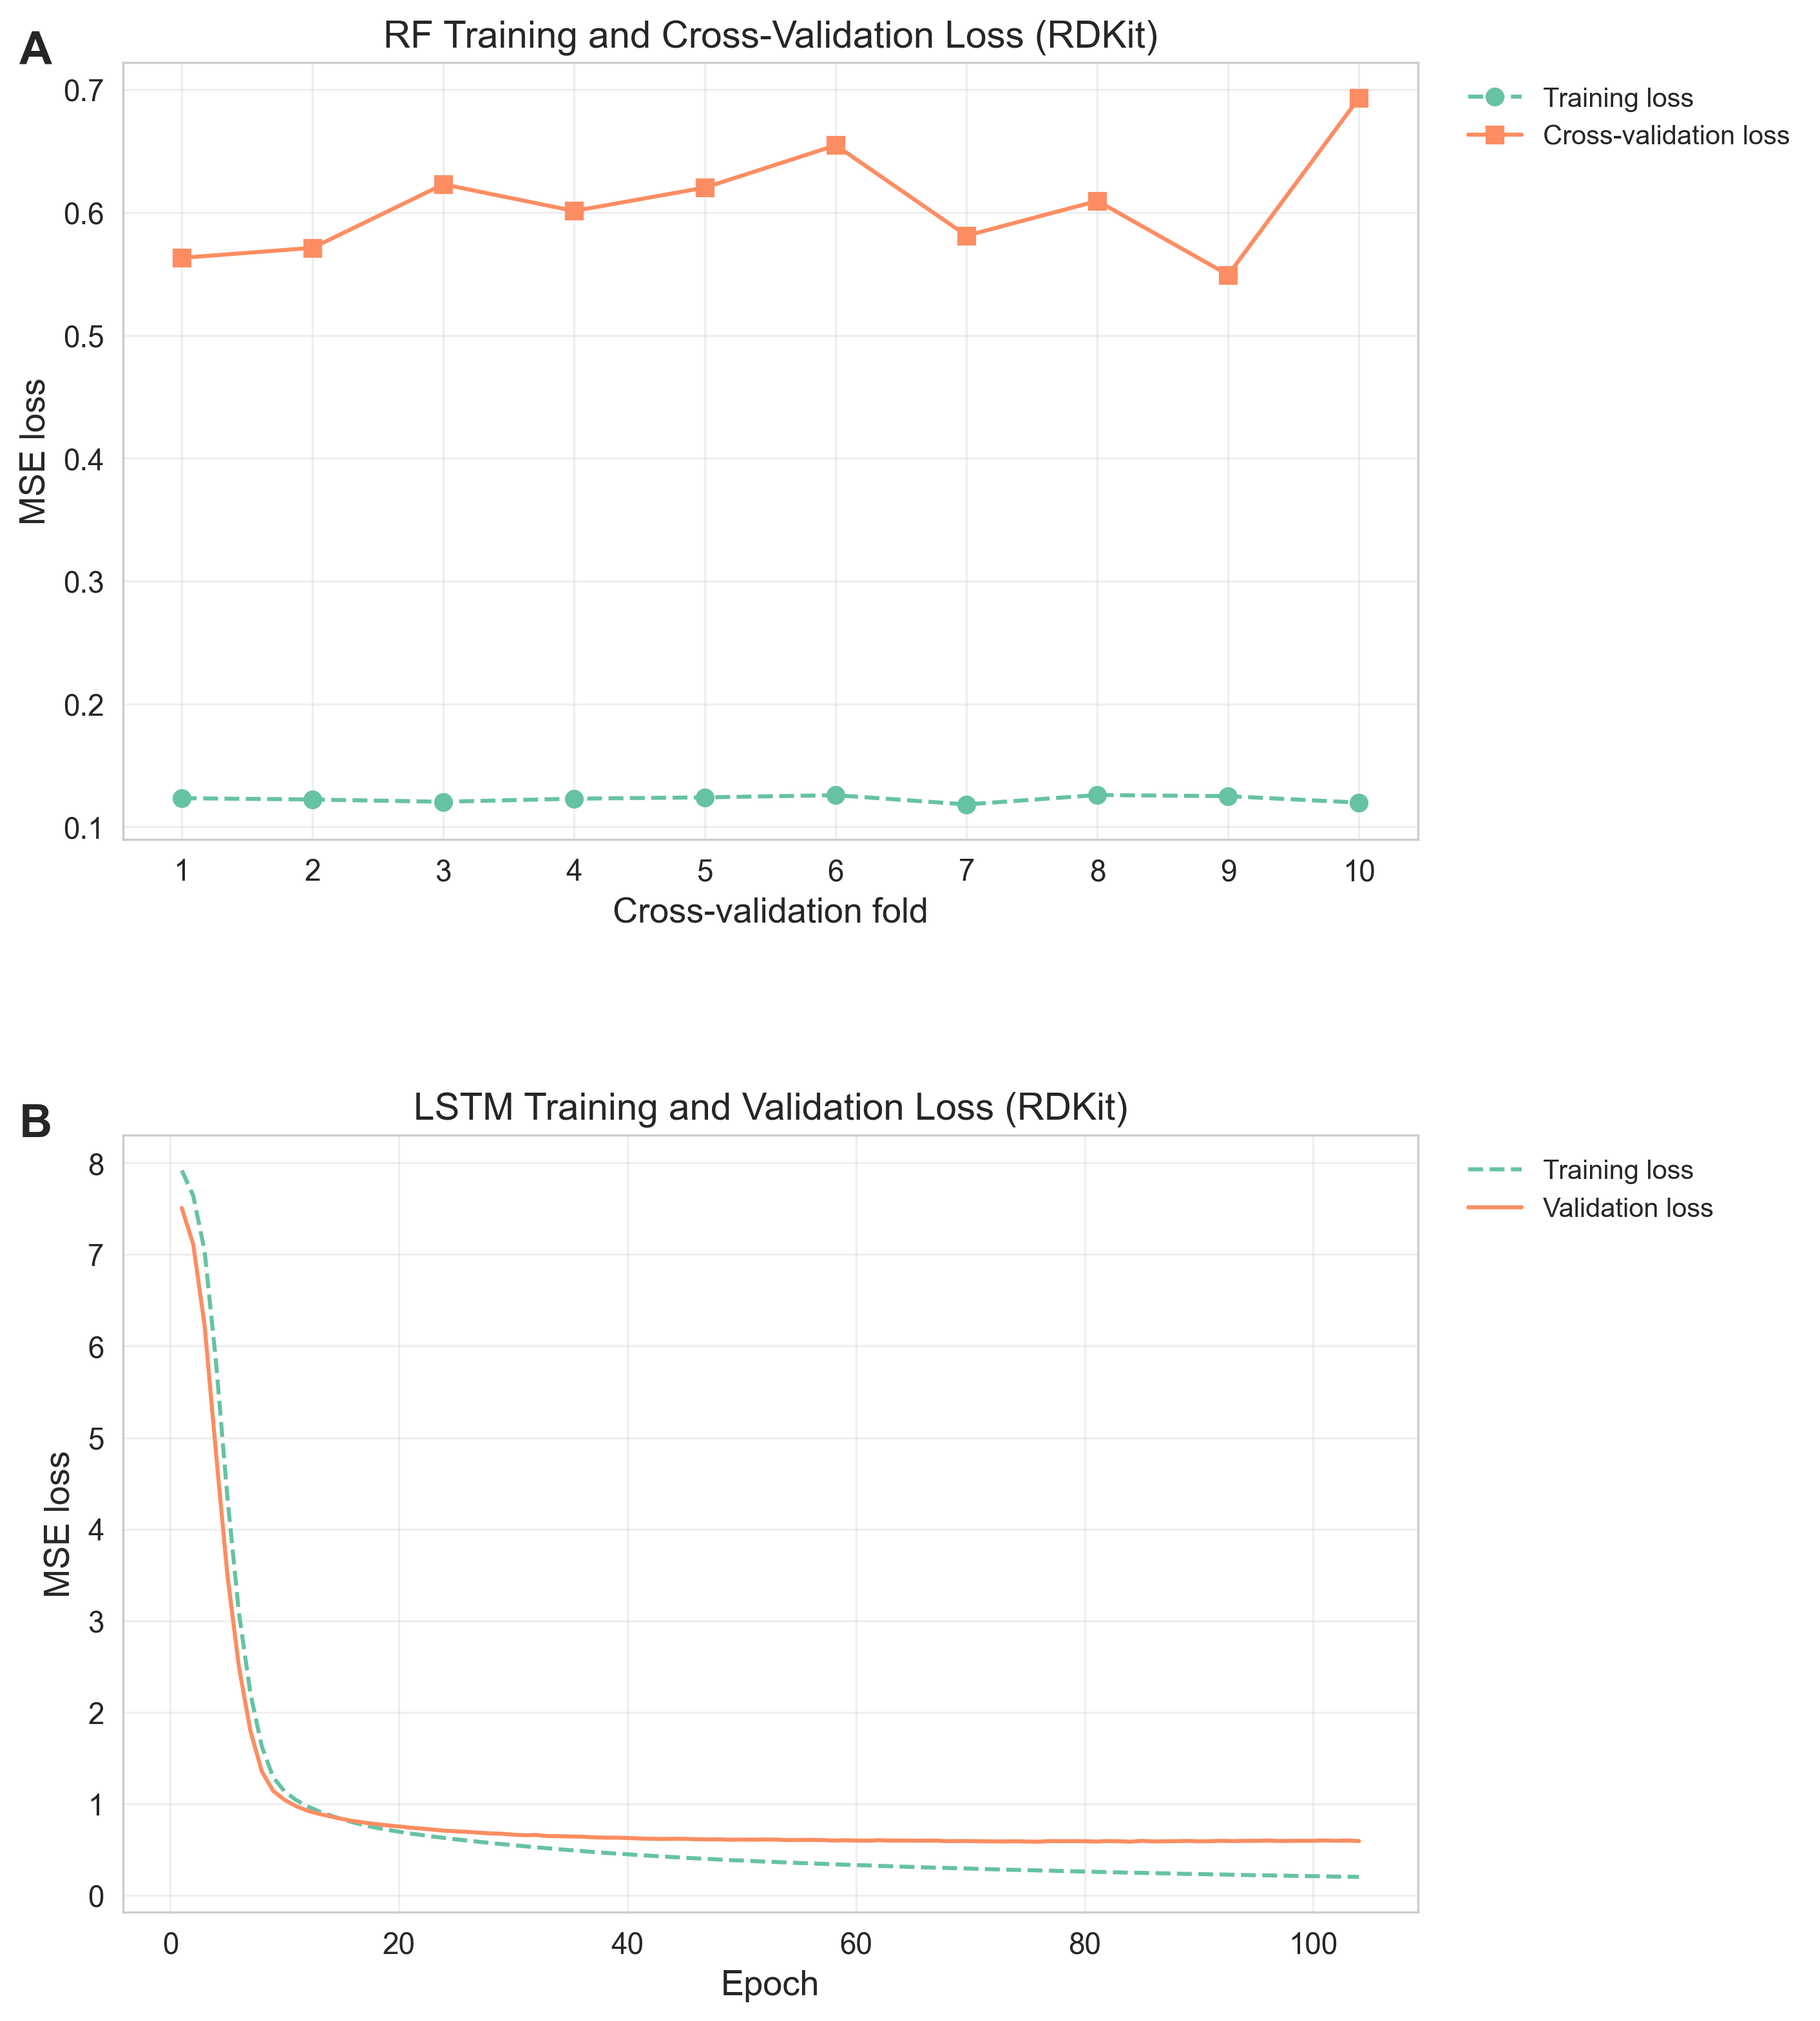

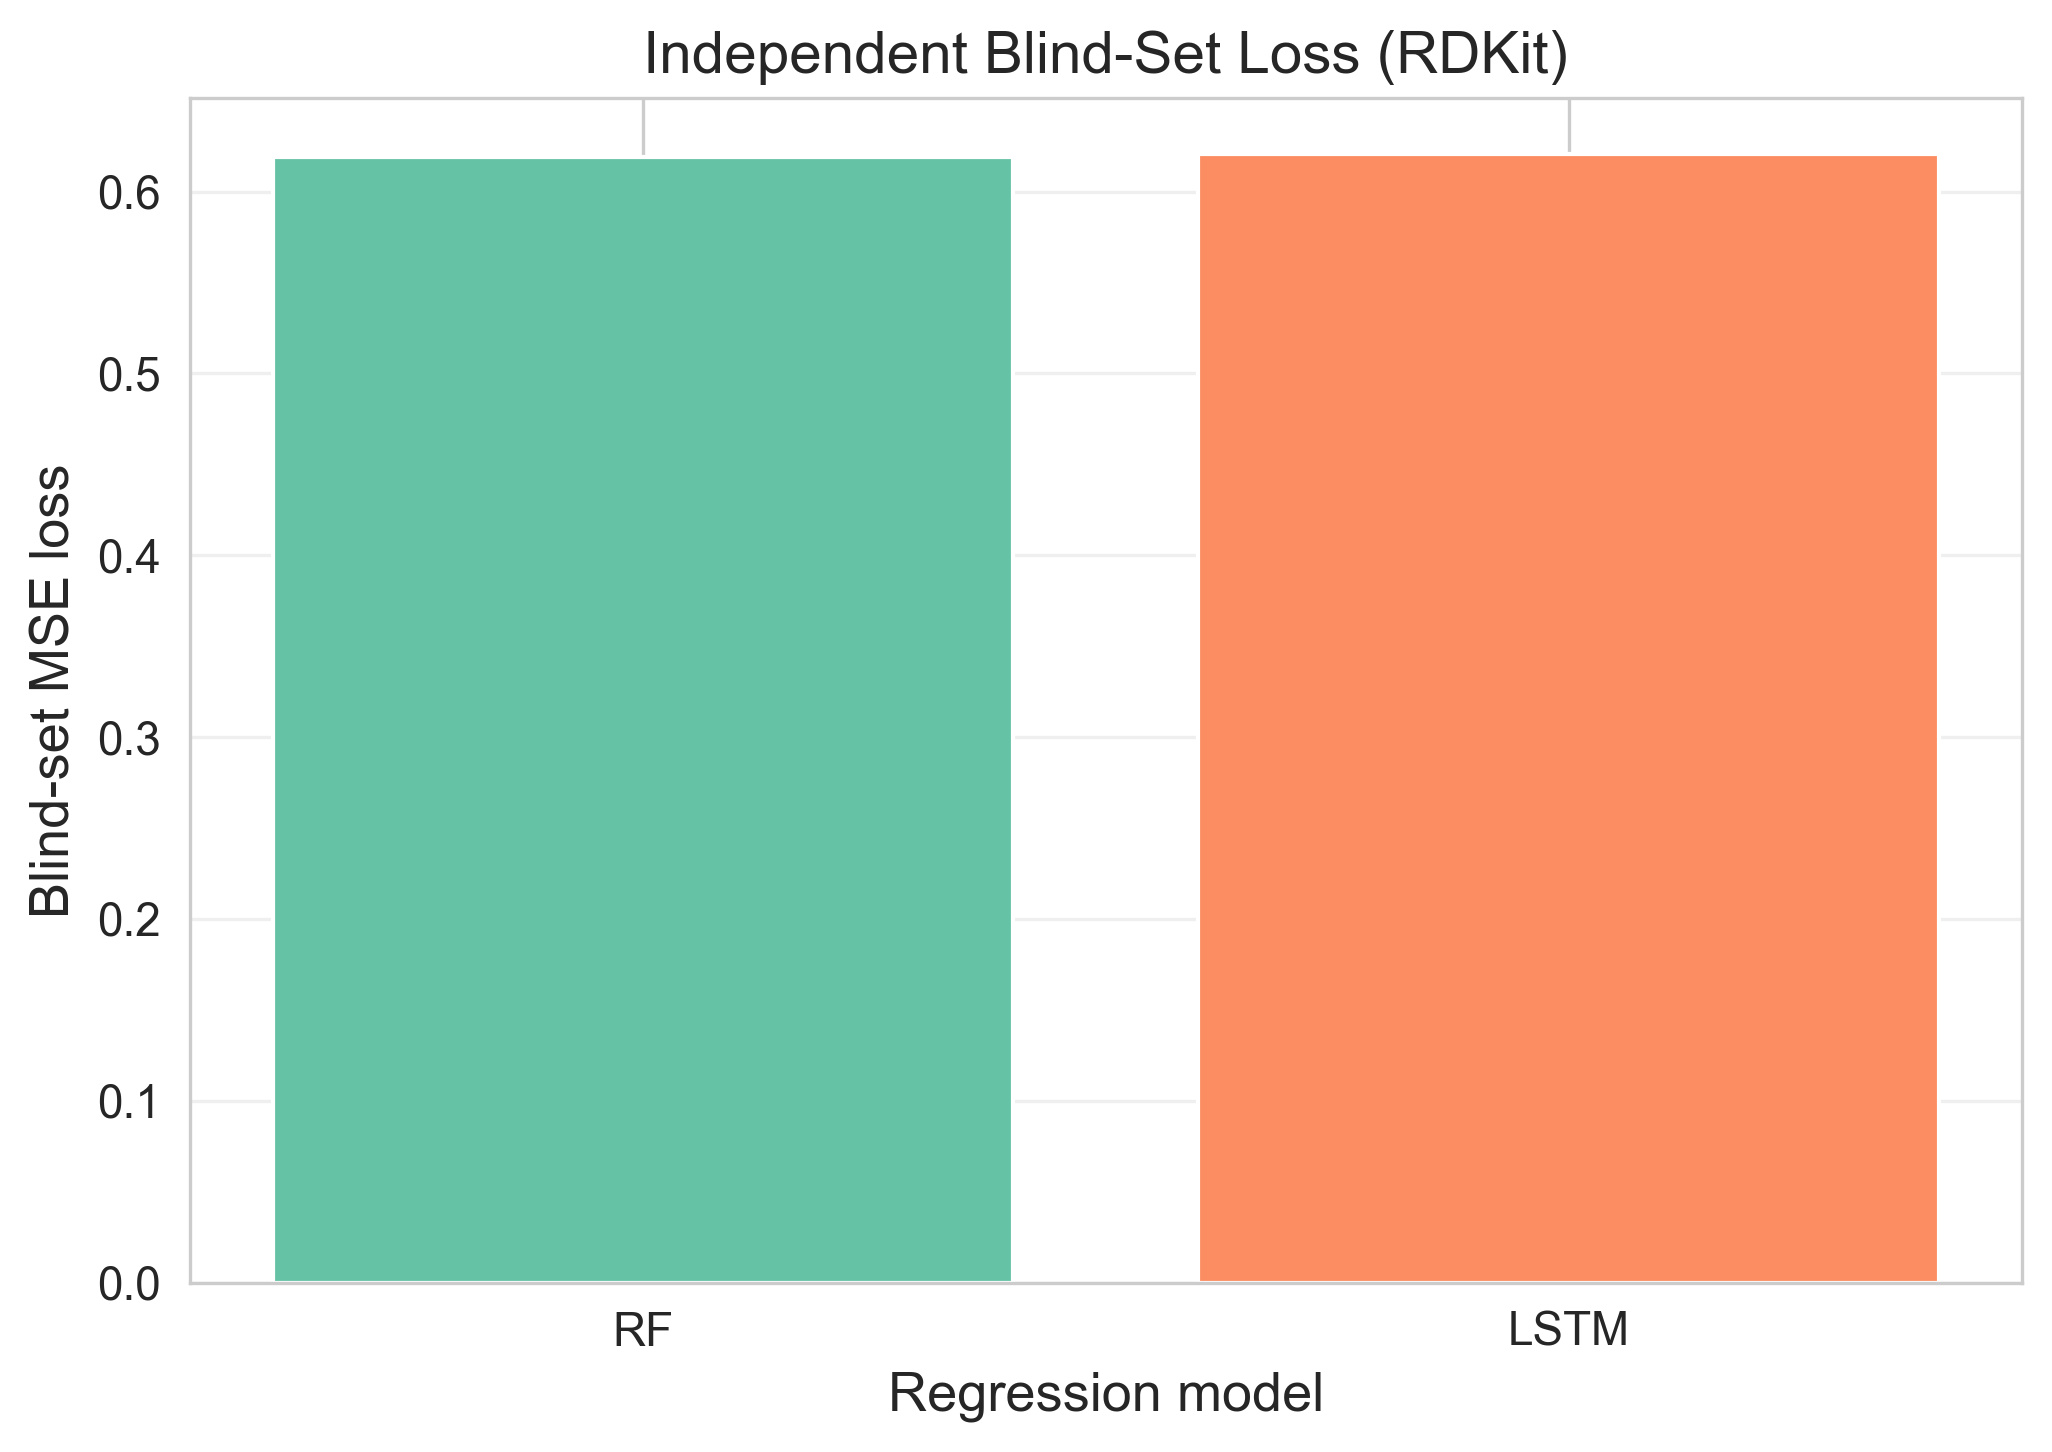

Training-validation loss PNG:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/RF_LSTM_Training_Validation_Loss.png
Training-validation loss JPG:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/RF_LSTM_Training_Validation_Loss.jpg
Blind-set loss PNG:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/RF_LSTM_Blind_Set_Loss.png
Blind-set loss JPG:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/RF_LSTM_Blind_Set_Loss.jpg


In [51]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# ==================================================
# 1. General settings
# ==================================================
RANDOM_STATE = 42
N_FOLDS = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

sns.set_style("whitegrid")


# ==================================================
# 2. Input and output paths
# ==================================================
data_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data"
)

train_file = data_dir / "rdkit_train.csv"
blind_file = data_dir / "rdkit_blind.csv"

output_dir = data_dir / "model"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

loss_png_file = (
    output_dir /
    "RF_LSTM_Training_Validation_Loss.png"
)

loss_jpg_file = (
    output_dir /
    "RF_LSTM_Training_Validation_Loss.jpg"
)

blind_png_file = (
    output_dir /
    "RF_LSTM_Blind_Set_Loss.png"
)

blind_jpg_file = (
    output_dir /
    "RF_LSTM_Blind_Set_Loss.jpg"
)


# ==================================================
# 3. Check input files
# ==================================================
if not train_file.exists():
    raise FileNotFoundError(
        f"Training file was not found:\n{train_file}"
    )

if not blind_file.exists():
    raise FileNotFoundError(
        f"Blind file was not found:\n{blind_file}"
    )


# ==================================================
# 4. Load datasets
# ==================================================
rdkit_train = pd.read_csv(
    train_file
)

rdkit_blind = pd.read_csv(
    blind_file
)

print(f"Training dataset shape: {rdkit_train.shape}")
print(f"Blind dataset shape: {rdkit_blind.shape}")


# ==================================================
# 5. Define excluded columns
# ==================================================
cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles"
]

drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name"
]

drop_cols = list(
    dict.fromkeys(
        cols_to_drop1 + drop_cols2
    )
)


# ==================================================
# 6. Data-cleaning function
# ==================================================
def clean_descriptor_data(
    dataframe,
    target_column,
    excluded_columns
):
    if target_column not in dataframe.columns:
        raise ValueError(
            f"Target column '{target_column}' was not found."
        )

    target = pd.to_numeric(
        dataframe[target_column],
        errors="coerce"
    )

    features = dataframe.drop(
        columns=[
            column
            for column in excluded_columns
            if column in dataframe.columns
        ]
    ).copy()

    # Replace blank cells
    features = features.replace(
        r"^\s*$",
        np.nan,
        regex=True
    )

    # Convert descriptors to numeric
    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Replace infinity with missing values
    features = features.replace(
        [np.inf, -np.inf],
        np.nan
    )

    target = target.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Remove values outside the float32 range
    float32_limit = np.finfo(
        np.float32
    ).max

    features = features.mask(
        features.abs() >= float32_limit
    )

    # Retain rows with valid target values
    valid_rows = target.notna()

    features = features.loc[
        valid_rows
    ].reset_index(drop=True)

    target = target.loc[
        valid_rows
    ].reset_index(drop=True)

    return features, target


# ==================================================
# 7. Clean training data
# ==================================================
X, y = clean_descriptor_data(
    dataframe=rdkit_train,
    target_column="log_ic50",
    excluded_columns=drop_cols
)

# Remove columns containing only missing values
all_nan_columns = X.columns[
    X.isna().all()
].tolist()

if all_nan_columns:
    print(
        f"Removing {len(all_nan_columns)} "
        "all-NaN training descriptors."
    )

    X = X.drop(
        columns=all_nan_columns
    )

# Remove descriptors containing fewer than two observations
insufficient_columns = X.columns[
    X.notna().sum(axis=0) < 2
].tolist()

if insufficient_columns:
    print(
        f"Removing {len(insufficient_columns)} "
        "insufficient descriptors."
    )

    X = X.drop(
        columns=insufficient_columns
    )

# Remove zero-variance descriptors
descriptor_variance = X.var(
    skipna=True
)

zero_variance_columns = descriptor_variance[
    np.isclose(
        descriptor_variance,
        0,
        equal_nan=True
    )
].index.tolist()

if zero_variance_columns:
    print(
        f"Removing {len(zero_variance_columns)} "
        "zero-variance descriptors."
    )

    X = X.drop(
        columns=zero_variance_columns
    )

features_filtered = X.columns.tolist()

X_selected = X[
    features_filtered
].copy()

print(
    f"Final training samples: "
    f"{X_selected.shape[0]}"
)

print(
    f"Final training descriptors: "
    f"{X_selected.shape[1]}"
)

if len(features_filtered) != 195:
    print(
        f"Warning: Expected 195 descriptors, but "
        f"{len(features_filtered)} were obtained."
    )


# ==================================================
# 8. Clean and align blind data
# ==================================================
X_blind, y_blind = clean_descriptor_data(
    dataframe=rdkit_blind,
    target_column="log_ic50",
    excluded_columns=drop_cols
)

missing_blind_features = [
    feature
    for feature in features_filtered
    if feature not in X_blind.columns
]

if missing_blind_features:
    raise ValueError(
        "The following training descriptors are missing "
        f"from the blind set:\n{missing_blind_features}"
    )

X_blind_selected = X_blind[
    features_filtered
].copy()

print(
    f"Final blind samples: "
    f"{X_blind_selected.shape[0]}"
)

print(
    f"Final blind descriptors: "
    f"{X_blind_selected.shape[1]}"
)


# ==================================================
# 9. Function to verify finite arrays
# ==================================================
def ensure_finite(array, array_name):
    array = np.asarray(
        array,
        dtype=np.float64
    )

    if not np.isfinite(array).all():
        invalid_count = np.size(array) - np.isfinite(
            array
        ).sum()

        raise ValueError(
            f"{array_name} contains {invalid_count} "
            "non-finite values."
        )

    return array


# ==================================================
# 10. Random Forest parameters
# ==================================================
rf_parameters = {
    "max_depth": None,
    "max_features": None,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "n_estimators": 200,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}


# ==================================================
# 11. RF training versus 10-fold CV loss
# ==================================================
kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_training_loss = []
rf_validation_loss = []

for fold, (train_index, validation_index) in enumerate(
    kf.split(X_selected),
    start=1
):
    X_fold_train = X_selected.iloc[
        train_index
    ]

    X_fold_validation = X_selected.iloc[
        validation_index
    ]

    y_fold_train = y.iloc[
        train_index
    ]

    y_fold_validation = y.iloc[
        validation_index
    ]

    # Fit imputation only on the training fold
    fold_imputer = SimpleImputer(
        strategy="mean"
    )

    X_fold_train_imputed = fold_imputer.fit_transform(
        X_fold_train
    )

    X_fold_validation_imputed = fold_imputer.transform(
        X_fold_validation
    )

    X_fold_train_imputed = ensure_finite(
        X_fold_train_imputed,
        f"RF fold {fold} training data"
    )

    X_fold_validation_imputed = ensure_finite(
        X_fold_validation_imputed,
        f"RF fold {fold} validation data"
    )

    rf_model = RandomForestRegressor(
        **rf_parameters
    )

    rf_model.fit(
        X_fold_train_imputed,
        y_fold_train
    )

    training_predictions = rf_model.predict(
        X_fold_train_imputed
    )

    validation_predictions = rf_model.predict(
        X_fold_validation_imputed
    )

    training_predictions = ensure_finite(
        training_predictions,
        f"RF fold {fold} training predictions"
    )

    validation_predictions = ensure_finite(
        validation_predictions,
        f"RF fold {fold} validation predictions"
    )

    training_mse = mean_squared_error(
        y_fold_train,
        training_predictions
    )

    validation_mse = mean_squared_error(
        y_fold_validation,
        validation_predictions
    )

    rf_training_loss.append(
        training_mse
    )

    rf_validation_loss.append(
        validation_mse
    )

    print(
        f"RF fold {fold}/{N_FOLDS}: "
        f"training MSE = {training_mse:.4f}; "
        f"validation MSE = {validation_mse:.4f}"
    )


# ==================================================
# 12. LSTM model
# ==================================================
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        activation="relu"
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }

        self.activation = activations.get(
            activation,
            nn.Identity()
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.activation(output)

        return self.fc(output)


# ==================================================
# 13. Split training data for LSTM loss monitoring
# ==================================================
(
    X_lstm_train,
    X_lstm_validation,
    y_lstm_train,
    y_lstm_validation
) = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Fit imputation only on LSTM training data
lstm_imputer = SimpleImputer(
    strategy="mean"
)

X_lstm_train_imputed = lstm_imputer.fit_transform(
    X_lstm_train
)

X_lstm_validation_imputed = lstm_imputer.transform(
    X_lstm_validation
)

X_blind_imputed_lstm = lstm_imputer.transform(
    X_blind_selected
)

# Fit scaling only on LSTM training data
lstm_scaler = StandardScaler()

X_lstm_train_scaled = lstm_scaler.fit_transform(
    X_lstm_train_imputed
)

X_lstm_validation_scaled = lstm_scaler.transform(
    X_lstm_validation_imputed
)

X_blind_scaled_lstm = lstm_scaler.transform(
    X_blind_imputed_lstm
)

# Replace any numerical artifacts after scaling
X_lstm_train_scaled = np.nan_to_num(
    X_lstm_train_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_lstm_validation_scaled = np.nan_to_num(
    X_lstm_validation_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

X_blind_scaled_lstm = np.nan_to_num(
    X_blind_scaled_lstm,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# Prevent extreme standardized values
X_lstm_train_scaled = np.clip(
    X_lstm_train_scaled,
    -20.0,
    20.0
)

X_lstm_validation_scaled = np.clip(
    X_lstm_validation_scaled,
    -20.0,
    20.0
)

X_blind_scaled_lstm = np.clip(
    X_blind_scaled_lstm,
    -20.0,
    20.0
)

X_lstm_train_scaled = ensure_finite(
    X_lstm_train_scaled,
    "LSTM training data"
)

X_lstm_validation_scaled = ensure_finite(
    X_lstm_validation_scaled,
    "LSTM validation data"
)

X_blind_scaled_lstm = ensure_finite(
    X_blind_scaled_lstm,
    "LSTM blind data"
)


# ==================================================
# 14. Convert LSTM data to float32 tensors
# ==================================================
X_lstm_train_sequence = X_lstm_train_scaled.reshape(
    -1,
    1,
    X_lstm_train_scaled.shape[1]
)

X_lstm_validation_sequence = X_lstm_validation_scaled.reshape(
    -1,
    1,
    X_lstm_validation_scaled.shape[1]
)

X_blind_sequence = X_blind_scaled_lstm.reshape(
    -1,
    1,
    X_blind_scaled_lstm.shape[1]
)

train_tensor = torch.tensor(
    X_lstm_train_sequence,
    dtype=torch.float32
)

train_target_tensor = torch.tensor(
    y_lstm_train.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

validation_tensor = torch.tensor(
    X_lstm_validation_sequence,
    dtype=torch.float32
)

validation_target_tensor = torch.tensor(
    y_lstm_validation.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

blind_tensor = torch.tensor(
    X_blind_sequence,
    dtype=torch.float32
)

if not torch.isfinite(train_tensor).all():
    raise ValueError(
        "The LSTM training tensor contains invalid values."
    )

if not torch.isfinite(validation_tensor).all():
    raise ValueError(
        "The LSTM validation tensor contains invalid values."
    )

if not torch.isfinite(blind_tensor).all():
    raise ValueError(
        "The LSTM blind tensor contains invalid values."
    )


# ==================================================
# 15. Create LSTM data loaders
# ==================================================
train_loader = DataLoader(
    TensorDataset(
        train_tensor,
        train_target_tensor
    ),
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(
        validation_tensor,
        validation_target_tensor
    ),
    batch_size=32,
    shuffle=False
)


# ==================================================
# 16. Train LSTM and record losses
# ==================================================
lstm_model = LSTMRegressor(
    input_size=train_tensor.shape[2],
    hidden_size=64,
    num_layers=2,
    activation="relu"
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.0001
)

maximum_epochs = 200
patience = 20

best_validation_loss = float("inf")
best_model_state = None
patience_counter = 0

lstm_training_loss = []
lstm_validation_loss = []

for epoch in range(
    1,
    maximum_epochs + 1
):
    # Training
    lstm_model.train()
    batch_training_losses = []

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        predictions = lstm_model(
            batch_x
        )

        loss = criterion(
            predictions,
            batch_y
        )

        if not torch.isfinite(loss):
            raise ValueError(
                f"LSTM training loss became invalid "
                f"at epoch {epoch}."
            )

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_training_losses.append(
            loss.item()
        )

    average_training_loss = np.mean(
        batch_training_losses
    )

    # Validation
    lstm_model.eval()
    batch_validation_losses = []

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            predictions = lstm_model(
                batch_x
            )

            loss = criterion(
                predictions,
                batch_y
            )

            if not torch.isfinite(loss):
                raise ValueError(
                    f"LSTM validation loss became invalid "
                    f"at epoch {epoch}."
                )

            batch_validation_losses.append(
                loss.item()
            )

    average_validation_loss = np.mean(
        batch_validation_losses
    )

    lstm_training_loss.append(
        average_training_loss
    )

    lstm_validation_loss.append(
        average_validation_loss
    )

    if average_validation_loss < best_validation_loss:
        best_validation_loss = average_validation_loss

        best_model_state = copy.deepcopy(
            lstm_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(
                f"LSTM early stopping at epoch {epoch}."
            )
            break

if best_model_state is not None:
    lstm_model.load_state_dict(
        best_model_state
    )


# ==================================================
# 17. Evaluate final RF on blind set
# ==================================================
final_rf_imputer = SimpleImputer(
    strategy="mean"
)

X_full_train_imputed = final_rf_imputer.fit_transform(
    X_selected
)

X_blind_imputed_rf = final_rf_imputer.transform(
    X_blind_selected
)

X_full_train_imputed = ensure_finite(
    X_full_train_imputed,
    "Final RF training data"
)

X_blind_imputed_rf = ensure_finite(
    X_blind_imputed_rf,
    "Final RF blind data"
)

final_rf_model = RandomForestRegressor(
    **rf_parameters
)

final_rf_model.fit(
    X_full_train_imputed,
    y
)

rf_blind_predictions = final_rf_model.predict(
    X_blind_imputed_rf
)

rf_blind_predictions = ensure_finite(
    rf_blind_predictions,
    "RF blind predictions"
)

rf_blind_loss = mean_squared_error(
    y_blind,
    rf_blind_predictions
)


# ==================================================
# 18. Evaluate final LSTM on blind set
# ==================================================
lstm_model.eval()

with torch.no_grad():
    lstm_blind_predictions = (
        lstm_model(blind_tensor)
        .squeeze(-1)
        .cpu()
        .numpy()
    )

lstm_blind_predictions = ensure_finite(
    lstm_blind_predictions,
    "LSTM blind predictions"
)

lstm_blind_loss = mean_squared_error(
    y_blind,
    lstm_blind_predictions
)


# ==================================================
# 19. Plot RF and LSTM loss
# ==================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 11),
    dpi=300,
    facecolor="white"
)

colors = sns.color_palette(
    "Set2",
    n_colors=2
)

# Panel A: RF fold loss
fold_numbers = np.arange(
    1,
    N_FOLDS + 1
)

axes[0].plot(
    fold_numbers,
    rf_training_loss,
    linestyle="--",
    marker="o",
    color=colors[0],
    label="Training loss"
)

axes[0].plot(
    fold_numbers,
    rf_validation_loss,
    linestyle="-",
    marker="s",
    color=colors[1],
    label="Cross-validation loss"
)

axes[0].set_xlabel(
    "Cross-validation fold"
)

axes[0].set_ylabel(
    "MSE loss"
)

axes[0].set_title(
    "RF Training and Cross-Validation Loss (RDKit)",
    fontweight="normal"
)

axes[0].set_xticks(
    fold_numbers
)

axes[0].grid(
    alpha=0.30
)

axes[0].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

axes[0].text(
    -0.08,
    1.04,
    "A",
    transform=axes[0].transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)

# Panel B: LSTM epoch loss
epoch_numbers = np.arange(
    1,
    len(lstm_training_loss) + 1
)

axes[1].plot(
    epoch_numbers,
    lstm_training_loss,
    linestyle="--",
    color=colors[0],
    label="Training loss"
)

axes[1].plot(
    epoch_numbers,
    lstm_validation_loss,
    linestyle="-",
    color=colors[1],
    label="Validation loss"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "MSE loss"
)

axes[1].set_title(
    "LSTM Training and Validation Loss (RDKit)",
    fontweight="normal"
)

axes[1].grid(
    alpha=0.30
)

axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

axes[1].text(
    -0.08,
    1.04,
    "B",
    transform=axes[1].transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)

fig.subplots_adjust(
    left=0.11,
    right=0.78,
    bottom=0.08,
    top=0.95,
    hspace=0.38
)

fig.savefig(
    loss_png_file,
    format="png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white"
)

fig.savefig(
    loss_jpg_file,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# 20. Plot blind-set MSE separately
# ==================================================
fig, ax = plt.subplots(
    figsize=(7, 5),
    dpi=300,
    facecolor="white"
)

ax.bar(
    ["RF", "LSTM"],
    [
        rf_blind_loss,
        lstm_blind_loss
    ],
    color=colors
)

ax.set_xlabel(
    "Regression model"
)

ax.set_ylabel(
    "Blind-set MSE loss"
)

ax.set_title(
    "Independent Blind-Set Loss (RDKit)",
    fontweight="normal"
)

ax.grid(
    axis="y",
    alpha=0.30
)

fig.tight_layout()

fig.savefig(
    blind_png_file,
    format="png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white"
)

fig.savefig(
    blind_jpg_file,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)

plt.show()
plt.close(fig)


# ==================================================
# 21. Print output locations
# ==================================================
print(
    f"Training-validation loss PNG:\n"
    f"{loss_png_file}"
)

print(
    f"Training-validation loss JPG:\n"
    f"{loss_jpg_file}"
)

print(
    f"Blind-set loss PNG:\n"
    f"{blind_png_file}"
)

print(
    f"Blind-set loss JPG:\n"
    f"{blind_jpg_file}"
)

Training dataset shape: (2760, 223)
Blind dataset shape: (691, 223)
Training samples retained: 2760
Training descriptors retained: 195
Blind samples retained: 691
Blind descriptors retained: 195
LSTM training samples: 2208
LSTM validation samples: 552
Epoch 1: Training RMSE = 2.7946; Validation RMSE = 2.7698; Training R² = -2.2062; Validation R² = -2.1486
Epoch 10: Training RMSE = 1.0353; Validation RMSE = 1.0257; Training R² = 0.5600; Validation R² = 0.5682
Epoch 20: Training RMSE = 0.8253; Validation RMSE = 0.8799; Training R² = 0.7204; Validation R² = 0.6822
Epoch 30: Training RMSE = 0.7324; Validation RMSE = 0.8267; Training R² = 0.7798; Validation R² = 0.7195
Epoch 40: Training RMSE = 0.6627; Validation RMSE = 0.8004; Training R² = 0.8197; Validation R² = 0.7371
Epoch 50: Training RMSE = 0.6110; Validation RMSE = 0.7901; Training R² = 0.8467; Validation R² = 0.7438
Epoch 60: Training RMSE = 0.5691; Validation RMSE = 0.7844; Training R² = 0.8670; Validation R² = 0.7475
Epoch 70: Tr

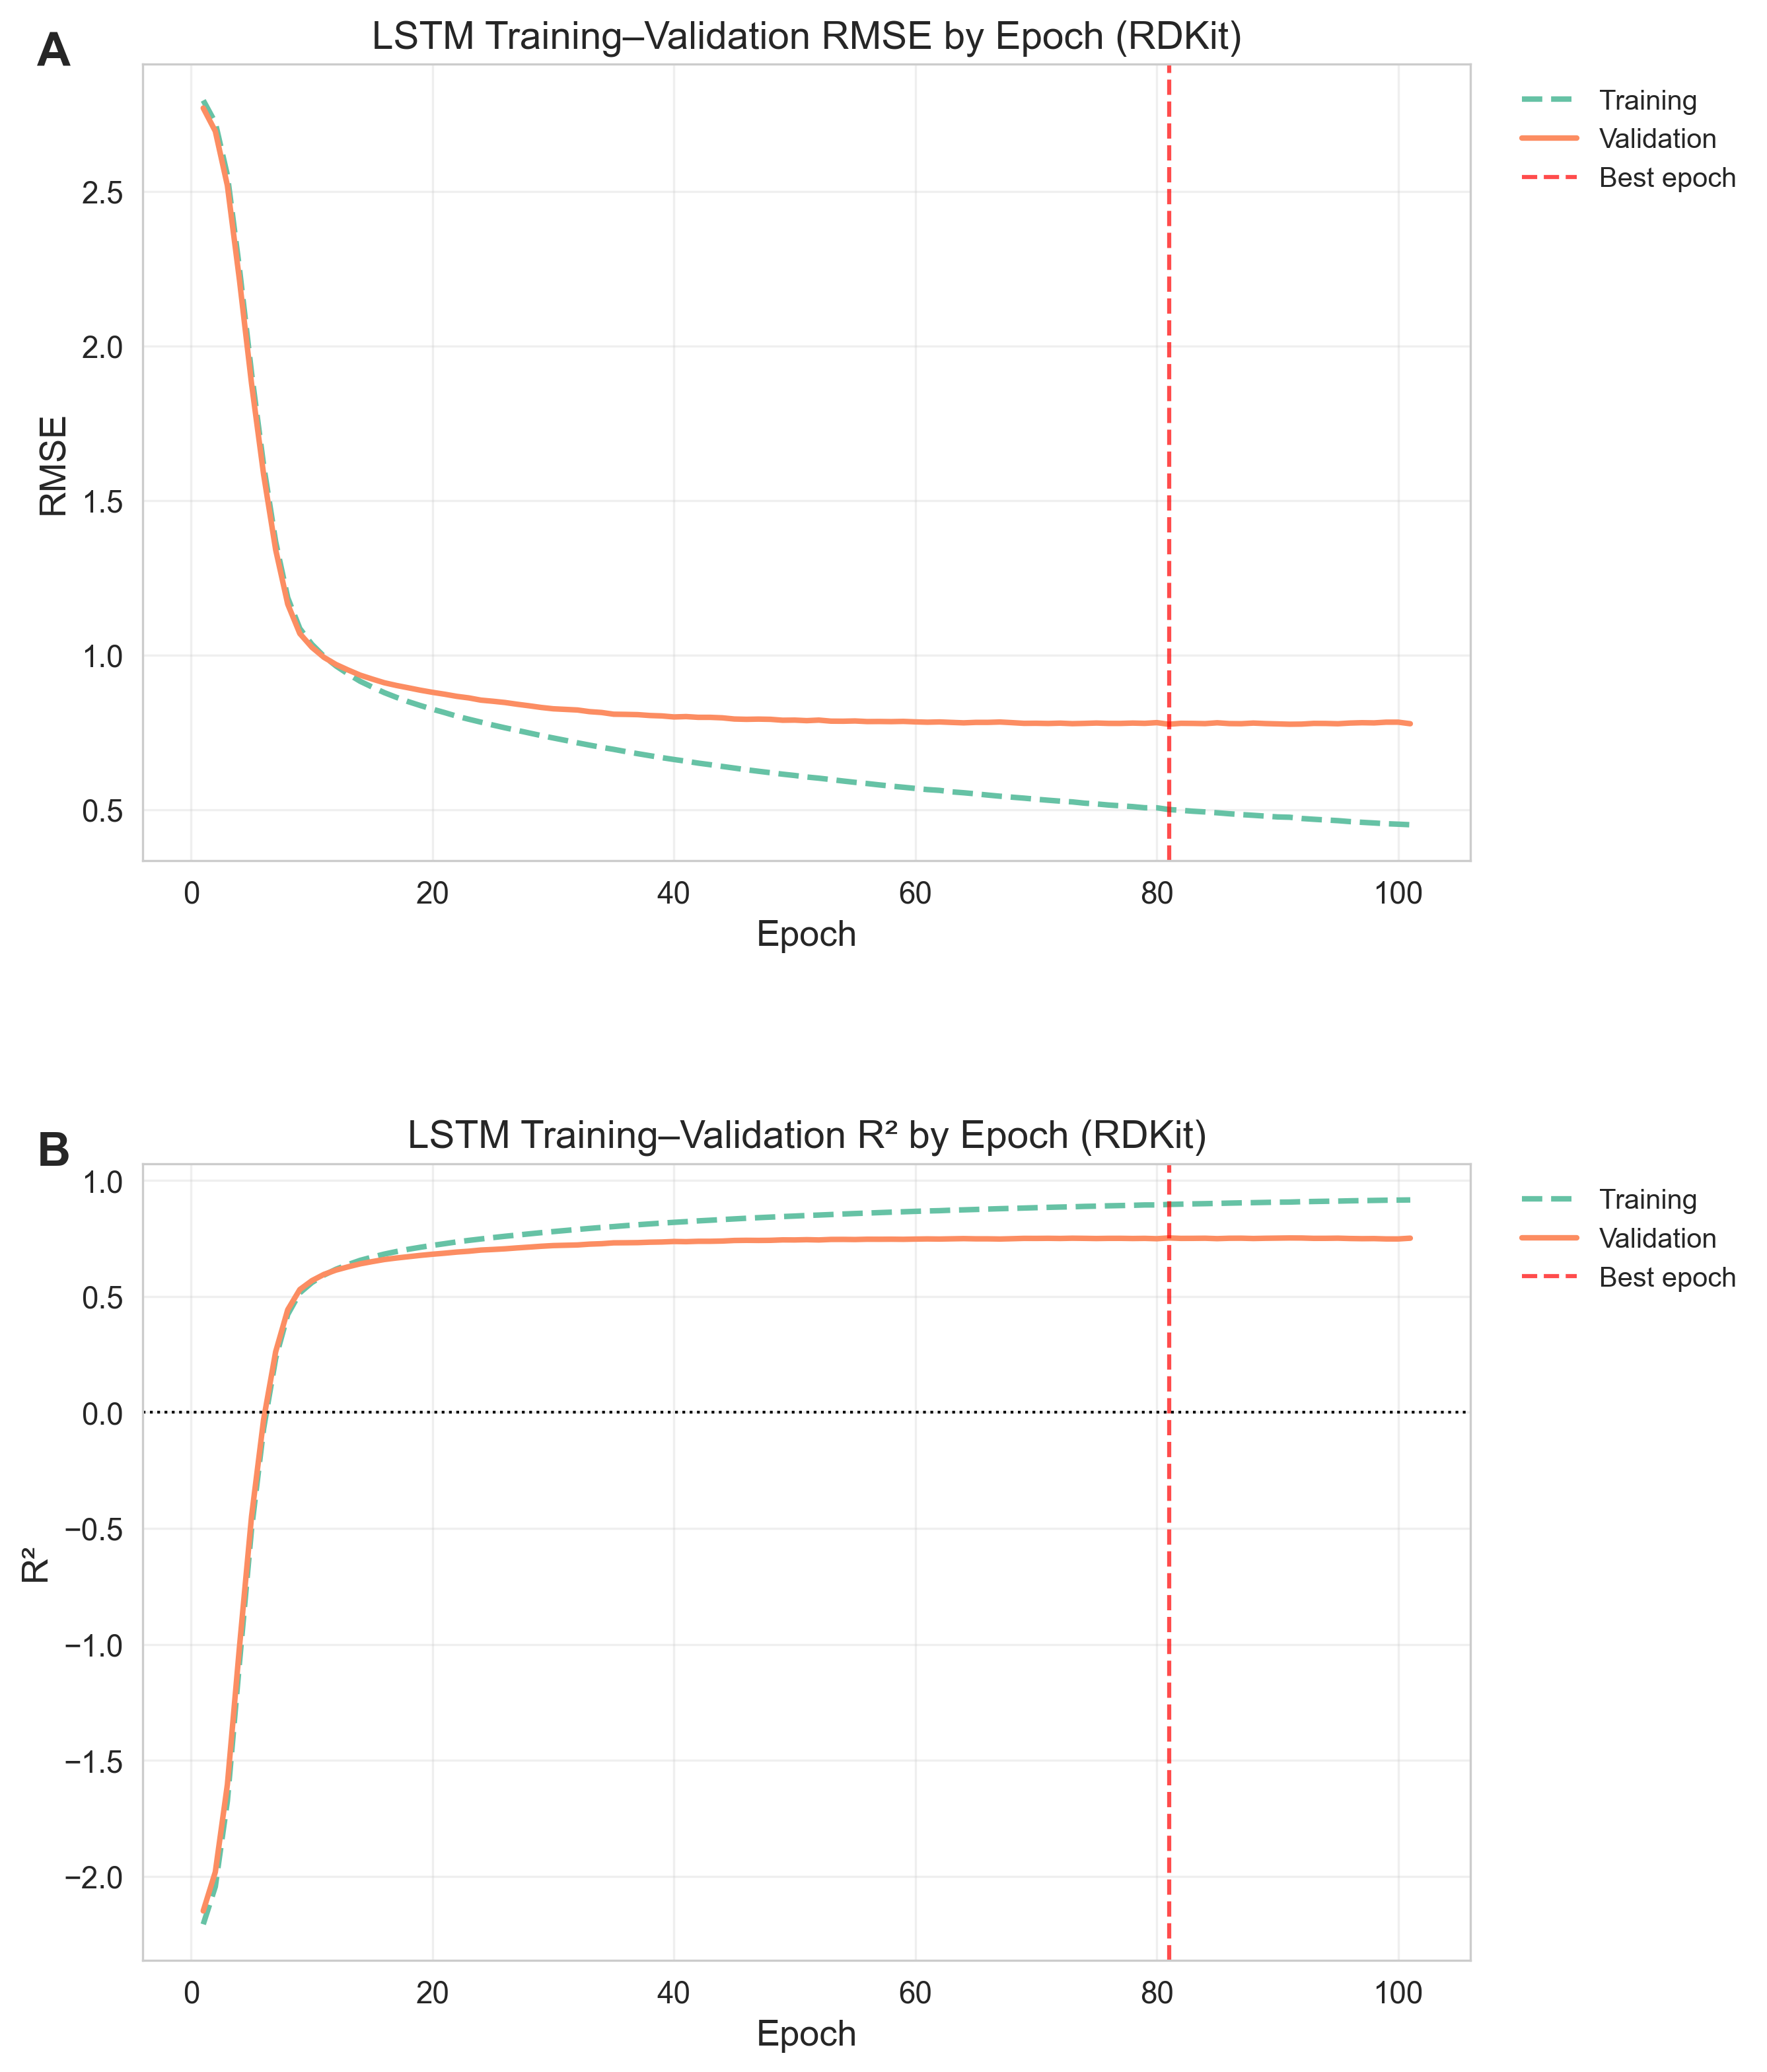

PNG learning curves saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/LSTM_RMSE_R2_Learning_Curves.png
JPG learning curves saved at:
/Users/janat/Desktop/ppimic50pred/dataset/data/model/LSTM_RMSE_R2_Learning_Curves.jpg


In [57]:
"""
LSTM Learning Curves and Independent Blind-Set Evaluation

The script:
1. Loads rdkit_train.csv and rdkit_blind.csv.
2. Uses the filtered RDKit descriptor set.
3. Cleans infinity, extreme values, and missing values.
4. Trains an LSTM using a training/validation split.
5. Records training and validation RMSE and R² at every epoch.
6. Uses early stopping based on validation MSE.
7. Evaluates the best LSTM once on the independent blind set.
8. Saves a two-panel learning-curve figure at 300 dpi.
"""

import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    TensorDataset,
    DataLoader
)


# ==================================================
# 1. General settings
# ==================================================
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

sns.set_style("whitegrid")


# ==================================================
# 2. Input and output paths
# ==================================================
data_dir = Path(
    "/Users/janat/Desktop/ppimic50pred/dataset/data"
)

train_file = (
    data_dir / "rdkit_train.csv"
)

blind_file = (
    data_dir / "rdkit_blind.csv"
)

output_dir = (
    data_dir / "model"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

png_output_file = (
    output_dir /
    "LSTM_RMSE_R2_Learning_Curves.png"
)

jpg_output_file = (
    output_dir /
    "LSTM_RMSE_R2_Learning_Curves.jpg"
)


# ==================================================
# 3. Check input files
# ==================================================
if not train_file.exists():
    raise FileNotFoundError(
        f"Training file was not found:\n"
        f"{train_file}"
    )

if not blind_file.exists():
    raise FileNotFoundError(
        f"Blind file was not found:\n"
        f"{blind_file}"
    )


# ==================================================
# 4. Load datasets
# ==================================================
rdkit_train = pd.read_csv(
    train_file
)

rdkit_blind = pd.read_csv(
    blind_file
)

print(
    f"Training dataset shape: "
    f"{rdkit_train.shape}"
)

print(
    f"Blind dataset shape: "
    f"{rdkit_blind.shape}"
)


# ==================================================
# 5. Define excluded columns
# ==================================================
cols_to_drop1 = [
    "NumRadicalElectrons",
    "SMR_VSA8",
    "SlogP_VSA9",
    "fr_aldehyde",
    "fr_azide",
    "fr_barbitur",
    "fr_benzodiazepine",
    "fr_diazo",
    "fr_epoxide",
    "fr_isocyan",
    "fr_lactam",
    "fr_nitroso",
    "fr_prisulfonamd",
    "fr_quatN",
    "fr_thiocyan",
    "fr_term_acetylene",
    "fr_phos_ester",
    "fr_oxime",
    "fr_dihydropyridine",
    "fr_phos_acid",
    "fr_hdrzine",
    "fr_N_O",
    "chembl_id",
    "smiles"
]

drop_cols2 = [
    "chembl_id",
    "smiles",
    "ic50_value",
    "log_ic50",
    "target_chembl_id",
    "target_name"
]

drop_cols = list(
    dict.fromkeys(
        cols_to_drop1 + drop_cols2
    )
)


# ==================================================
# 6. Clean descriptor dataset
# ==================================================
def clean_dataset(
    dataframe,
    target_column,
    excluded_columns
):
    if target_column not in dataframe.columns:
        raise ValueError(
            f"Target column '{target_column}' "
            "was not found."
        )

    target = pd.to_numeric(
        dataframe[target_column],
        errors="coerce"
    )

    features = dataframe.drop(
        columns=[
            column
            for column in excluded_columns
            if column in dataframe.columns
        ]
    ).copy()

    # Replace blank cells
    features = features.replace(
        r"^\s*$",
        np.nan,
        regex=True
    )

    # Convert descriptors to numeric
    features = features.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Replace infinity with NaN
    features = features.replace(
        [np.inf, -np.inf],
        np.nan
    )

    target = target.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # Remove values outside the float32 range
    float32_limit = np.finfo(
        np.float32
    ).max

    features = features.mask(
        features.abs() >= float32_limit
    )

    # Retain rows with valid target values
    valid_rows = target.notna()

    features = features.loc[
        valid_rows
    ].reset_index(drop=True)

    target = target.loc[
        valid_rows
    ].reset_index(drop=True)

    return features, target


# ==================================================
# 7. Prepare training data
# ==================================================
X, y = clean_dataset(
    dataframe=rdkit_train,
    target_column="log_ic50",
    excluded_columns=drop_cols
)

# Remove descriptors containing only missing values
all_nan_columns = X.columns[
    X.isna().all()
].tolist()

if all_nan_columns:
    print(
        f"Removing {len(all_nan_columns)} "
        "all-NaN descriptors."
    )

    X = X.drop(
        columns=all_nan_columns
    )

# Remove descriptors with fewer than two observations
insufficient_columns = X.columns[
    X.notna().sum(axis=0) < 2
].tolist()

if insufficient_columns:
    print(
        f"Removing {len(insufficient_columns)} "
        "insufficient descriptors."
    )

    X = X.drop(
        columns=insufficient_columns
    )

# Remove zero-variance descriptors
descriptor_variance = X.var(
    skipna=True
)

zero_variance_columns = descriptor_variance[
    np.isclose(
        descriptor_variance,
        0,
        equal_nan=True
    )
].index.tolist()

if zero_variance_columns:
    print(
        f"Removing {len(zero_variance_columns)} "
        "zero-variance descriptors."
    )

    X = X.drop(
        columns=zero_variance_columns
    )

features_filtered = X.columns.tolist()

X_selected = X[
    features_filtered
].copy()

print(
    f"Training samples retained: "
    f"{X_selected.shape[0]}"
)

print(
    f"Training descriptors retained: "
    f"{X_selected.shape[1]}"
)

if len(features_filtered) != 195:
    print(
        f"Warning: Expected 195 descriptors, but "
        f"{len(features_filtered)} were retained."
    )


# ==================================================
# 8. Prepare blind data
# ==================================================
X_blind, y_blind = clean_dataset(
    dataframe=rdkit_blind,
    target_column="log_ic50",
    excluded_columns=drop_cols
)

missing_blind_features = [
    feature
    for feature in features_filtered
    if feature not in X_blind.columns
]

if missing_blind_features:
    raise ValueError(
        "The following training descriptors are "
        "missing from the blind set:\n"
        f"{missing_blind_features}"
    )

# Use the same features and the same column order
X_blind_selected = X_blind[
    features_filtered
].copy()

print(
    f"Blind samples retained: "
    f"{X_blind_selected.shape[0]}"
)

print(
    f"Blind descriptors retained: "
    f"{X_blind_selected.shape[1]}"
)


# ==================================================
# 9. Split training data
# ==================================================
(
    X_train,
    X_validation,
    y_train,
    y_validation
) = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(
    f"LSTM training samples: "
    f"{X_train.shape[0]}"
)

print(
    f"LSTM validation samples: "
    f"{X_validation.shape[0]}"
)


# ==================================================
# 10. Mean imputation
# ==================================================
# Fit only on the training subset
imputer = SimpleImputer(
    strategy="mean"
)

X_train_imputed = imputer.fit_transform(
    X_train
)

X_validation_imputed = imputer.transform(
    X_validation
)

X_blind_imputed = imputer.transform(
    X_blind_selected
)


# ==================================================
# 11. Standardization
# ==================================================
# Fit only on the training subset
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imputed
)

X_validation_scaled = scaler.transform(
    X_validation_imputed
)

X_blind_scaled = scaler.transform(
    X_blind_imputed
)


# ==================================================
# 12. Clean numerical artifacts after scaling
# ==================================================
def clean_scaled_array(array):
    array = np.nan_to_num(
        array,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Prevent extreme standardized values
    array = np.clip(
        array,
        -20.0,
        20.0
    )

    if not np.isfinite(array).all():
        raise ValueError(
            "Non-finite values remain after scaling."
        )

    return array


X_train_scaled = clean_scaled_array(
    X_train_scaled
)

X_validation_scaled = clean_scaled_array(
    X_validation_scaled
)

X_blind_scaled = clean_scaled_array(
    X_blind_scaled
)


# ==================================================
# 13. Convert descriptors into LSTM format
# ==================================================
X_train_sequence = X_train_scaled.reshape(
    -1,
    1,
    X_train_scaled.shape[1]
)

X_validation_sequence = X_validation_scaled.reshape(
    -1,
    1,
    X_validation_scaled.shape[1]
)

X_blind_sequence = X_blind_scaled.reshape(
    -1,
    1,
    X_blind_scaled.shape[1]
)


# ==================================================
# 14. Create tensors
# ==================================================
train_tensor = torch.tensor(
    X_train_sequence,
    dtype=torch.float32
)

train_target_tensor = torch.tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

validation_tensor = torch.tensor(
    X_validation_sequence,
    dtype=torch.float32
)

validation_target_tensor = torch.tensor(
    y_validation.to_numpy().reshape(-1, 1),
    dtype=torch.float32
)

blind_tensor = torch.tensor(
    X_blind_sequence,
    dtype=torch.float32
)

if not torch.isfinite(train_tensor).all():
    raise ValueError(
        "The training tensor contains invalid values."
    )

if not torch.isfinite(validation_tensor).all():
    raise ValueError(
        "The validation tensor contains invalid values."
    )

if not torch.isfinite(blind_tensor).all():
    raise ValueError(
        "The blind-set tensor contains invalid values."
    )


# ==================================================
# 15. Create data loaders
# ==================================================
train_loader = DataLoader(
    TensorDataset(
        train_tensor,
        train_target_tensor
    ),
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    TensorDataset(
        validation_tensor,
        validation_target_tensor
    ),
    batch_size=32,
    shuffle=False
)


# ==================================================
# 16. Define LSTM model
# ==================================================
class LSTMRegressor(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        activation="relu"
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        activation_functions = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }

        self.activation = activation_functions.get(
            activation,
            nn.Identity()
        )

        self.fc = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]
        output = self.activation(output)

        return self.fc(output)


# ==================================================
# 17. Initialize LSTM
# ==================================================
lstm_model = LSTMRegressor(
    input_size=train_tensor.shape[2],
    hidden_size=64,
    num_layers=2,
    activation="relu"
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.0001
)


# ==================================================
# 18. Training settings and histories
# ==================================================
maximum_epochs = 200
patience = 20

best_validation_mse = float("inf")
best_model_state = None
best_epoch = 0
patience_counter = 0

train_rmse_history = []
validation_rmse_history = []

train_r2_history = []
validation_r2_history = []


# ==================================================
# 19. Train LSTM and calculate epoch metrics
# ==================================================
for epoch in range(
    1,
    maximum_epochs + 1
):
    # ----------------------------------------------
    # Training stage
    # ----------------------------------------------
    lstm_model.train()

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        batch_predictions = lstm_model(
            batch_x
        )

        loss = criterion(
            batch_predictions,
            batch_y
        )

        if not torch.isfinite(loss):
            raise ValueError(
                f"The training loss became invalid "
                f"at epoch {epoch}."
            )

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

    # ----------------------------------------------
    # Calculate full training and validation metrics
    # ----------------------------------------------
    lstm_model.eval()

    with torch.no_grad():
        training_predictions = (
            lstm_model(train_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

        validation_predictions = (
            lstm_model(validation_tensor)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

    training_true = (
        train_target_tensor
        .squeeze(-1)
        .cpu()
        .numpy()
    )

    validation_true = (
        validation_target_tensor
        .squeeze(-1)
        .cpu()
        .numpy()
    )

    if not np.isfinite(training_predictions).all():
        raise ValueError(
            f"Training predictions became invalid "
            f"at epoch {epoch}."
        )

    if not np.isfinite(validation_predictions).all():
        raise ValueError(
            f"Validation predictions became invalid "
            f"at epoch {epoch}."
        )

    # ----------------------------------------------
    # Calculate RMSE
    # ----------------------------------------------
    training_rmse = np.sqrt(
        mean_squared_error(
            training_true,
            training_predictions
        )
    )

    validation_rmse = np.sqrt(
        mean_squared_error(
            validation_true,
            validation_predictions
        )
    )

    # ----------------------------------------------
    # Calculate R²
    # ----------------------------------------------
    training_r2 = r2_score(
        training_true,
        training_predictions
    )

    validation_r2 = r2_score(
        validation_true,
        validation_predictions
    )

    # Save metrics
    train_rmse_history.append(
        training_rmse
    )

    validation_rmse_history.append(
        validation_rmse
    )

    train_r2_history.append(
        training_r2
    )

    validation_r2_history.append(
        validation_r2
    )

    # ----------------------------------------------
    # Early stopping using validation MSE
    # ----------------------------------------------
    validation_mse = validation_rmse ** 2

    if validation_mse < best_validation_mse:
        best_validation_mse = validation_mse
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            lstm_model.state_dict()
        )

        patience_counter = 0

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch}."
            )
            break

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch}: "
            f"Training RMSE = {training_rmse:.4f}; "
            f"Validation RMSE = {validation_rmse:.4f}; "
            f"Training R² = {training_r2:.4f}; "
            f"Validation R² = {validation_r2:.4f}"
        )


# ==================================================
# 20. Restore best model
# ==================================================
if best_model_state is not None:
    lstm_model.load_state_dict(
        best_model_state
    )

print(f"Best epoch: {best_epoch}")


# ==================================================
# 21. Independent blind-set evaluation
# ==================================================
lstm_model.eval()

with torch.no_grad():
    blind_predictions = (
        lstm_model(blind_tensor)
        .squeeze(-1)
        .cpu()
        .numpy()
    )

if not np.isfinite(blind_predictions).all():
    raise ValueError(
        "Blind-set predictions contain invalid values."
    )

blind_true = y_blind.to_numpy()

blind_rmse = np.sqrt(
    mean_squared_error(
        blind_true,
        blind_predictions
    )
)

blind_r2 = r2_score(
    blind_true,
    blind_predictions
)

print(
    f"Independent blind-set RMSE: "
    f"{blind_rmse:.4f}"
)

print(
    f"Independent blind-set R²: "
    f"{blind_r2:.4f}"
)


# ==================================================
# 22. Create the LSTM learning curves
# ==================================================
epoch_numbers = np.arange(
    1,
    len(train_rmse_history) + 1
)

colors = sns.color_palette(
    "Set2",
    n_colors=2
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(10, 11),
    dpi=300,
    facecolor="white"
)


# ==================================================
# 23. Panel A: RMSE learning curve
# ==================================================
axes[0].plot(
    epoch_numbers,
    train_rmse_history,
    color=colors[0],
    linestyle="--",
    linewidth=2,
    label="Training"
)

axes[0].plot(
    epoch_numbers,
    validation_rmse_history,
    color=colors[1],
    linestyle="-",
    linewidth=2,
    label="Validation"
)

axes[0].axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.70,
    label="Best epoch"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "RMSE"
)

axes[0].set_title(
    "LSTM Training–Validation RMSE by Epoch (RDKit)",
    fontweight="normal"
)

axes[0].grid(
    alpha=0.30
)

axes[0].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

axes[0].text(
    -0.08,
    1.04,
    "A",
    transform=axes[0].transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)


# ==================================================
# 24. Panel B: R² learning curve
# ==================================================
axes[1].plot(
    epoch_numbers,
    train_r2_history,
    color=colors[0],
    linestyle="--",
    linewidth=2,
    label="Training"
)

axes[1].plot(
    epoch_numbers,
    validation_r2_history,
    color=colors[1],
    linestyle="-",
    linewidth=2,
    label="Validation"
)

axes[1].axvline(
    x=best_epoch,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.70,
    label="Best epoch"
)

axes[1].axhline(
    y=0,
    color="black",
    linestyle=":",
    linewidth=1
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "R²"
)

axes[1].set_title(
    "LSTM Training–Validation R² by Epoch (RDKit)",
    fontweight="normal"
)

axes[1].grid(
    alpha=0.30
)

axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=False
)

axes[1].text(
    -0.08,
    1.04,
    "B",
    transform=axes[1].transAxes,
    fontsize=17,
    fontweight="bold",
    ha="left",
    va="top",
    clip_on=False
)


# ==================================================
# 25. Adjust panel spacing
# ==================================================
fig.subplots_adjust(
    left=0.11,
    right=0.78,
    bottom=0.08,
    top=0.95,
    hspace=0.38
)


# ==================================================
# 26. Save as PNG at 300 dpi
# ==================================================
fig.savefig(
    png_output_file,
    format="png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white"
)


# ==================================================
# 27. Save as JPG at 300 dpi
# ==================================================
fig.savefig(
    jpg_output_file,
    format="jpg",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
    facecolor="white",
    pil_kwargs={
        "quality": 100,
        "subsampling": 0
    }
)


# ==================================================
# 28. Display and close
# ==================================================
plt.show()
plt.close(fig)


# ==================================================
# 29. Print output locations
# ==================================================
print(
    f"PNG learning curves saved at:\n"
    f"{png_output_file}"
)

print(
    f"JPG learning curves saved at:\n"
    f"{jpg_output_file}"
)